# Statistics Fundamentals for Data Science: A practical guide

### Project Overview

This project serves as a practical, hands-on guide to the fundamental concepts of statistics, building from foundational theory to practical application in Data Science and Machine Learning. The goal is to build a comprehensive portfolio piece that not only demonstrates technical skills in Python, but also showcases a deep understanding of the *why* behind the statistical principles that underpin data-driven decision-making.

We will journey through four key stages:
1.  **Exploratory Data Analysis (EDA):** Learning to summarize, visualize, and understand the main characteristics of a dataset.
2.  **Data Distributions & Inference:** Building the theoretical groundwork by exploring probability, random variables, and the common distributions used to model real-world phenomena.
3.  **Experimentation & Hypothesis Testing:** Applying a scientific framework to validate assumptions and make decisions based on data.
4.  **Introduction to Machine Learning:** Using our statistical foundation to build and evaluate predictive models for regression and classification tasks.

**Dataset:** The data analyzed in this project comes from the "Video Game Sales with Ratings" dataset, available on [Kaggle](https://www.kaggle.com/datasets/xtyscut/video-games-sales-as-at-22-dec-2016csv/data).

---

In [1]:
# Import essential libraries
%pip install matplotlib-venn
%pip install statsmodels
%pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Latex, display
import scipy.stats as stats
from scipy.stats import binom, poisson, norm, expon, probplot, levene, mannwhitneyu, f_oneway, kruskal, chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import ols
import sklearn as sk
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree 
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score

# Set plot style
plt.style.use('seaborn-v0_8-paper')

# Load the dataset
try:
    df = pd.read_csv('../data/Video_Games_Sales.csv')
    print("Dataset loaded successfully!")
    print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    print("Error: Dataset file not found.")
    print("Please check the file path and make sure the 'Video_Games_Sales.csv' file is in the 'data/' directory.")

df.head()

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Dataset loaded successfully!
The dataset has 16719 rows and 16 columns.


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


We have a dataset containing video game sales information, including features such as:

- **Name:** The name of the game
- **Platform:** The platform on which the game was released
- **Year:** The year the game was released
- **Genre:** The genre of the game
- **Publisher:** The publisher of the game
- **NA_Sales:** Sales in North America (in millions)
- **EU_Sales:** Sales in Europe (in millions)
- **JP_Sales:** Sales in Japan (in millions)
- **Other_Sales:** Sales in other regions (in millions)
- **Global_Sales:** Total global sales (in millions)
- **Critic_Score:** Average score given by critics (out of 100)
- **User_Score:** Average score given by users (out of 10)
- **Rating:** Content rating of the game (e.g., E for Everyone, M for Mature)

This dataset can be used to analyze trends in video game sales, identify popular genres and platforms, and make data-driven decisions for game development and marketing strategies.

---
## **Exploratory Data Analysis (EDA) Fundamentals**

#### The **goal** of this section is to introduce the basics statistics tools for data exploration. [cite_start]Before building any models, we need to understand the **shape**, **central tendency**, and **dispersion** of the data we have[cite: 106]. [cite_start]This forms the foundation of any data-driven project[cite: 107].

- **Central Tendency:** This refers to the measure that represents the center or typical value of a dataset. Common measures include the mean, median, and mode.

- **Dispersion or Variability:** This refers to the extent to which the data points in a dataset differ from each other and from the central tendency. Common measures include range, variance, and standard deviation.


### **1. Measures of Central Tendency:**


#### **Mean ($\bar{x}$):** The mean represents the average value of a dataset and is calculated by summing all the values and dividing by the count of values.



### $$ \boxed{\bar{x} =  \frac{\sum_{i=1}^{n} x_i}{n}} $$

  

- ##### **Example:** given a set of numbers: {1,2,5,8}, the mean would be calculated as follows:

  $ \bar{x} = \frac{1 + 2 + 5 + 8}{4} = \frac{16}{4} = 4 $



##### The mean is **sensitive** to **outliers**. For instance, if we include a very large number, say 100, the mean would shift significantly:

  $ \bar{x} = \frac{1 + 2 + 5 + 8 + 100}{5} = \frac{116}{5} = 23.2 $

- ##### The second most common type of average is the **weighted mean ($\bar{x}_w$)**. The weighted mean takes into account the importance or frequency of each value in the dataset. It is calculated by multiplying each value by its weight, summing these products, and then dividing by the sum of the weights.

  #### $ \boxed{\bar{x}_w = \frac{\sum_{i=1}^{n} w_i x_i}{\sum_{i=1}^{n} w_i}} $

- ##### For example, consider the numbers {1, 2, 3} with weights {0.2, 0.3, 0.5}. The weighted mean would be:

  $ \bar{x}_w = \frac{(0.2) \cdot 1 + (0.3) \cdot 2 + (0.5) \cdot 3}{0.2 + 0.3 + 0.5} = \frac{0.2 + 0.6 + 1.5}{1} = 2.3 $

- ##### **Outliers:** data points that differ significantly from other observations. 

#### **Median:** The median represents the middle value of a dataset when it is ordered from least to greatest. To find the median:

**1.** Order the dataset.

**2.** If the number of observations (n) is odd, the median is the middle value.

**3.** If n is even, the median is the average of the two middle values.
- ##### **Example:** given a set of numbers: {1,2,5,8}, the median would be calculated as follows:

  $ m = \frac{2 + 5}{2} = \frac{7}{2} = 3.5 $
##### The median is a robust measure of central tendency, as it is **NOT** affected by **outliers** or **extreme values** in the dataset. This makes it a preferred choice in many statistical analyses, especially when dealing with **skewed** distributions.

#### **Mode:** The mode represents the most frequently occurring value in a dataset. A dataset can have one mode (unimodal), more than one mode (bimodal or multimodal), or no mode at all if all values are unique.

  

- ##### **Example:** given a set of numbers: {1,2,5,5,8}, the mode would be 5.



##### The mode is a useful measure of central tendency, especially for categorical data, as it identifies the most common category or value in a dataset. However, it may not always provide a clear picture of the data distribution, and is not commonly used in numerical analyses.


##### $\boxed{\text{\textbf{Summary}: The \textbf{Mean} is the go-to for \textbf{symmetrically distributed} data. However, the \textbf{Median} is a more robust metric for \textbf{skewed distributions} as it is not affected by outliers, providing a better sense of a 'typical' value.}}$

### **2. Measures of Variability:**

#### **Standard Deviation ($\sigma$):** The standard deviation is a measure of the amount of variation/dispersion in a set of values. A low standard deviation means that the values tend to be close to the mean, while a high standard deviation means that the values are spread out over a wider range. It is calculated as follows:

### $$ \boxed{\sigma = \sqrt{ \sum_{i=1}^{n} \frac{(x_i - \bar{x})^2}{n-1}} } $$

- ##### **Example:** given a set of numbers: {1,2,5,8}, the standard deviation would be:

**1.** Calculating the mean ($\bar{x}$):

   $ \bar{x} = \frac{1 + 2 + 5 + 8}{4} = 4 $

**2.** Calculating the squared deviations from the mean:
   - $(1 - 4)^2 = 9$
   - $(2 - 4)^2 = 4$
   - $(5 - 4)^2 = 1$
   - $(8 - 4)^2 = 16$

**3.** Calculating the standard deviation ($\sigma$):

   $ \sigma = \sqrt{\frac{9 + 4 + 1 + 16}{4 - 1}} = \sqrt{10} \approx 3.16 $



#### $\boxed{\text{Why n-1?}}$
##### **Variance ($\sigma^2$):** The variance ($s²$) is the average of the squared differences from the mean. It is equal to the square of the standard deviation ($\sigma^2$).

#### $ \boxed{s^2 = \sigma^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2} $



##### The standard deviation and variance are both **sensitive** to **outliers**, since they are based on the deviations from the mean and are squared quantities.
#### **Percentile:** The percentile **P** is a value below which **P** percent of values in a group of observations falls below it and (100-P) percent are above it. For example, the 40th percentile (P40) is the value below which 40% of the observations may be found. The most common percentiles are the **25th (Q1)**, **50th** (Q2, or **median**), and **75th (Q3)** percentiles. The Q1 and Q3 percentiles are particularly important for understanding the spread and skewness of the data, and are used for calculate the **Interquartile Range (IQR)**. The formula bellow gives us the percentile; j represents the index of the ordered data point, and n is the total number of data points. This formula helps to identify the position of the percentile in the ordered dataset.

### $$\boxed{100\cdot  \frac{j}{n} \le P < 100 \cdot \frac{j+1}{n}}$$ 


- ##### **Interquartile Range (IQR):** The interquartile range (IQR) is a measure of statistical dispersion and is calculated as the difference between the 75th percentile (Q3) and the 25th percentile (Q1) of the data. It represents the range within which the central 50% of the data points (median) lie.
- ##### **Example:** given a set of numbers: {3,1,5,3,6,7,2,9}, the Q1 is 2.5 and Q3 is 6.5, so the IQR is 6.5 - 2.5 = 4.

#### **Median Absolute Deviation (MAD):** The median absolute deviation (MAD) is a robust measure of the variability of a univariate dataset. While Standard Deviation is common, it's sensitive to outliers just like the mean. A more robust alternative for measuring spread in skewed data is the Median Absolute Deviation (MAD). It is defined as the median of the absolute deviations from the median of the data. The formula for MAD is:

### $$\boxed{\text{MAD} = \text{Median}(|x_1 - m|, |x_2 - m|, ..., |x_N - m|)}$$

- ##### **Example:** given a set of numbers: {5,2,1,5,8}, the MAD is calculated as follows:

**1.** Find the median. In this case is 5.

**2.** Calculate the absolute deviations from the median:
   - $|1 - 5| = 4$
   - $|2 - 5| = 3$
   - $|5 - 5| = 0$
   - $|5 - 5| = 0$
   - $|8 - 5| = 3$

**3.** Find the median of the absolute deviations:
   - The absolute deviations are: {4, 3, 0, 0, 3}
   - The median of these values is 3.

##### Thus, the **MAD** is **3**.

#### **Expected Value (EV):** The expected value (EV) is a key concept in probability and statistics that represents the average outcome of a random variable over a large number of trials. It can be thought of as a sort of weighted mean, where the weights are the probabilities of each outcome. It is calculated by multiplying each possible outcome by its probability and summing these products.

### $\boxed{EV(X) = \sum_{i=1}^{n} x_i \cdot P(x_i)}$

- ##### **Example:** given a set of numbers: {50,20,30}, that could represent the prices of three distinct video games categories, and the probabilities that a client buy a game from each category are {0.1, 0.4, 0.5}. The EV will represent the average revenue that a company that sells this 3 categories will get, and is calculated as follows:

##### $EV = 50 \cdot P(50) + 20 \cdot P(20) + 30 \cdot P(30)$ = $50 \cdot 0.1 + 20 \cdot 0.4 + 30 \cdot 0.5$ = $5 + 8 + 15$ = $28$



### **3. Data Visualization & Applications:**

#### The data representation is the most crucial step in the data analysis process, as it directly impacts the insights we can derive from the data. Effective data visualization helps to:

-  ##### Identify trends and patterns
-  ##### Compare different groups or categories
-  ##### Communicate **findings** clearly and effectively

#### The most basic types of plots are: **Histograms, Bar Plots, Box Plots and Scatter Plots**.



#### **Histograms**:

##### It is used to visualize the distribution of a **single** numerical variable by dividing the data into **bins** and **counting** the number of observations in each bin through bars. This helps to identify the shape of the distribution, such as whether it is normal, skewed, or has outliers. **Bins** are the intervals into which the data is divided. They are represented in the **x-axis**. The **y-axis** represents the frequency (usually in counts units) of data points within that interval.

In [2]:
# Suppose we want to know how the games sales are distributed, i.e, how many games sold a number N of copies.

# In order to answer this question, we will make a histogram of the counts as a function of the millions of units sold for EACH game in our dataset.


df['Global_Sales'].dropna(inplace=True)
display(df[['Name', 'Global_Sales']]) # Display the DataFrame that we want

,Name,Global_Sales
0,Wii Sports,82.53
1,Super Mario Bros.,40.24
2,Mario Kart Wii,35.52
3,Wii Sports Resort,32.77
4,Pokemon Red/Pokemon Blue,31.37
...,...,...
16714,Samurai Warriors: Sanada Maru,0.01
16715,LMA Manager 2007,0.01
16716,Haitaka no Psychedelica,0.01
16717,Spirits & Spells,0.01


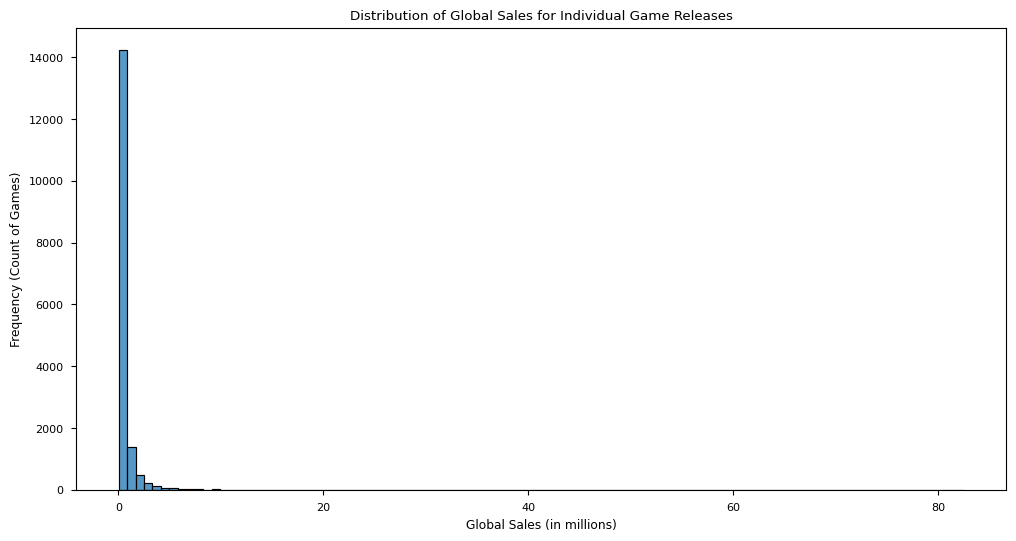

In [3]:
# Now, we create a histogram. We can use both matplotlib and seaborn: 
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Global_Sales', bins=100, linewidth=0.85) # Use the original df
plt.title('Distribution of Global Sales for Individual Game Releases')
plt.xlabel('Global Sales (in millions)')
plt.ylabel('Frequency (Count of Games)')
#plt.xlim(0, 10) # Limit x-axis to see the main distribution body
plt.show()


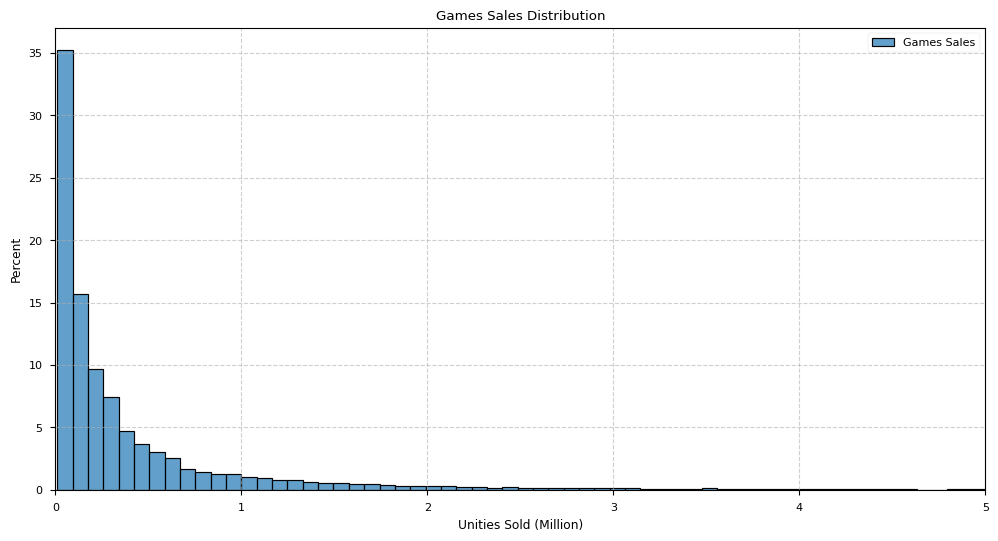

In [4]:
# If we look at the table and histogram above, we can see that almost zero games sold more than 10 million copies. In order to plot
# a more detailed view of the sales distribution, we can zoom in on the lower sales figures. We do this by increasing the number of bins
# and decreasing the x-axis limit.

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Global_Sales', bins=1000, linewidth=0.85, alpha=0.7, stat='percent', label='Games Sales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Games Sales Distribution')
plt.xlabel('Unities Sold (Million)')
plt.ylabel('Percent')
plt.xlim(0, 5)
plt.xticks(ticks=np.arange(0, 6, 1), labels=[f'{x}' for x in np.arange(0, 6, 1)]) # Organize the x-axis ticks
plt.legend()
plt.savefig('../images/histogram_sales_seaborn.png', dpi=300)
plt.show()


# Note that seaborn supports stats arguments, meaning we can easily plot percentages, KDEs, and more.

#### **Bar Plots:**

##### It is used to visualize the distribution of a **categorical** variable by displaying the frequency or proportion of each category through bars. This helps to compare the relative sizes of different categories and identify the most common or least common categories. The **y-axis** typically represents the count or percentage of observations in each category, while the **x-axis** represents the categories themselves.


/tmp/ipykernel_13317/190160571.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Genre_Sales.values, y=Genre_Sales.index, palette='rainbow') # Atention look that we inverted the axes, meaning, the y-axis have the genre and the x-axis have the sales


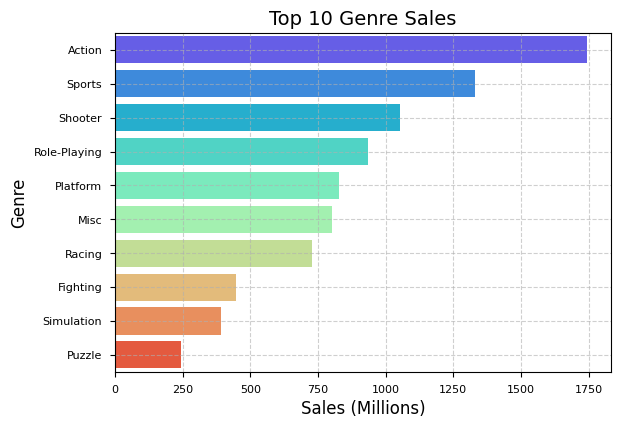

In [5]:
# Ok, the sales are assimetric. But which game category/genre dominates the sales? 
# Suppose we want to know the top10 genre sales. We can use a bar plot to visualize this information.

Genre_Sales = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False) # First we select the total sales for each genre
Genre_Sales = Genre_Sales.head(10) # Select the top 10 genres

sns.barplot(x=Genre_Sales.values, y=Genre_Sales.index, palette='rainbow') # Atention look that we inverted the axes, meaning, the y-axis have the genre and the x-axis have the sales
plt.xlabel("Sales (Millions)", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.title('Top 10 Genre Sales', fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

#### **Box Plots:**

##### It is used to visualize the distribution of a **numerical** variable by displaying the **median**, **quartiles**, and **potential outliers** through a box and whiskers. This helps to identify the spread and skewness of the data, as well as any potential outliers. The **box** represents the interquartile range (**IQR**), with the top and bottom being the 75th and 25th percentiles, respectively. The **line** inside the box represents the median (50th percentile), while the **whiskers** (dot lines) extend to the minimum and maximum values within 1.5 times the IQR from the quartiles. **Outliers** are typically represented as individual points beyond the whiskers.

In [6]:
# Now that we know the top10 best-selling genres, let's investigate the user ratings within them.
# Suppose we want to know if there is a relationship between the top genre sales and the user score. In order to achieve this, 
# we can create a box plot with the top genre sales on the y-axis and the user score on the x-axis.
# As we have multiple games that have score equal to tbd, we need to handle this case. (Data Cleaning)
df_plot = df[df['User_Score'] != 'tbd']
df_plot = df_plot[['User_Score', 'Genre']]
df_plot.dropna(inplace=True)
df_plot.sort_values(by='User_Score', ascending=False,inplace=True)
top5 = df_plot['Genre'].isin(['Action', 'Sports', 'Shooter', 'Role-Playing', 'Platform'])
df_plot = df_plot[top5]
df_plot['User_Score'] = pd.to_numeric(df_plot['User_Score'], errors='coerce')
df_plot

,User_Score,Genre
14414,9.7,Role-Playing
8976,9.6,Role-Playing
16550,9.5,Sports
10106,9.5,Action
1645,9.5,Role-Playing
...,...,...
8266,0.7,Sports
13427,0.7,Sports
5764,0.3,Action
9971,0.2,Sports


/tmp/ipykernel_13317/1319943548.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Genre', y='User_Score', palette='rainbow')


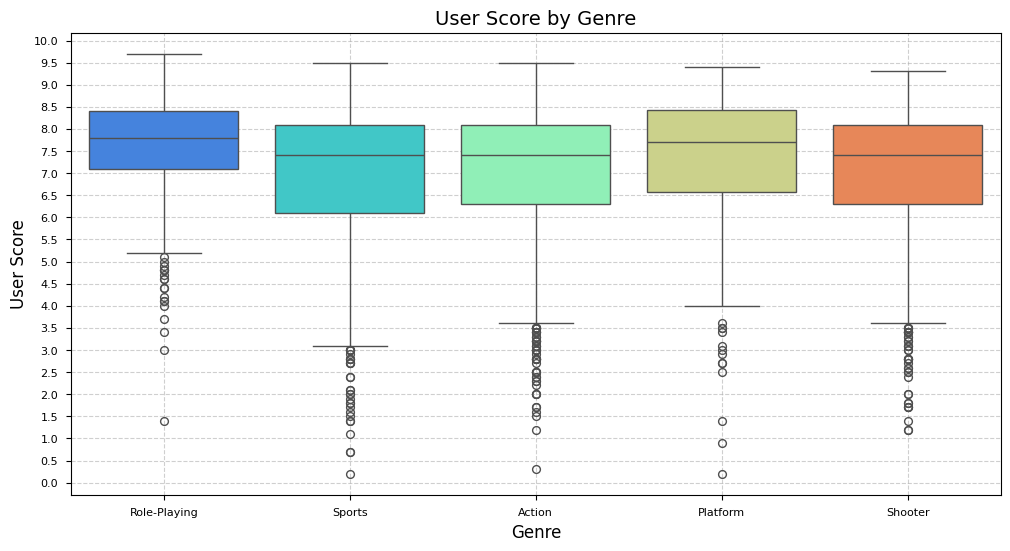

In [7]:
# Now we can plot the data

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x='Genre', y='User_Score', palette='rainbow')
plt.title('User Score by Genre', fontsize=14)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('User Score', fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.yticks(ticks=np.arange(0, 10.5, 0.5), labels=[f'{x:.1f}' for x in np.arange(0, 10.5, 0.5)]) # Organize the y-axis ticks
plt.show()

In [8]:
# The plot above shows the user score metrics for each genre. The boxplot reveals that, although 'Action' sells more, 'Role-Playing' and 
# 'Shooter' tend to have higher median User_Scores and more consistent distributions.
# This statistic can be visualized using pandas built-in plotting capabilities. Those are: .mean(), .median(), .var(),etc. 
df_stats = df_plot.groupby('Genre')['User_Score']
display(df_stats.mean().sort_index(ascending=True))
display(df_stats.median().sort_index(ascending=True))
display(df_stats.agg(pd.Series.mode).sort_index(ascending=True))
display(df_stats.var().sort_index(ascending=True))
# Another incredible tool is the .describe() method, which provides a summary of most of the statistics metrics that we discussed 
# in part 1 and 2.
# It shows the count, mean, std, min, 25%, 50%, 75%, and max values, all at once. 
# Counts in this case refers to the number of games in each genre.
display(df_stats.describe().sort_index(ascending=True))

Genre
Action          7.054044
Platform        7.301402
Role-Playing    7.619515
Shooter         7.041883
Sports          6.961197
Name: User_Score, dtype: float64

Genre
Action          7.4
Platform        7.7
Role-Playing    7.8
Shooter         7.4
Sports          7.4
Name: User_Score, dtype: float64

Genre
Action                 8.0
Platform               8.6
Role-Playing           8.2
Shooter         [7.8, 8.2]
Sports                 7.8
Name: User_Score, dtype: object

Genre
Action          2.031747
Platform        2.291052
Role-Playing    1.185239
Shooter         2.304582
Sports          2.596515
Name: User_Score, dtype: float64

,count,mean,std,min,25%,50%,75%,max
Genre,,,,,,,,
Action,1830.0,7.054044,1.425394,0.3,6.300,7.4,8.100,9.5
Platform,428.0,7.301402,1.513622,0.2,6.575,7.7,8.425,9.4
Role-Playing,743.0,7.619515,1.088687,1.4,7.100,7.8,8.400,9.7
Shooter,924.0,7.041883,1.518085,1.2,6.300,7.4,8.100,9.3
Sports,1103.0,6.961197,1.611370,0.2,6.100,7.4,8.100,9.5


#### **Scatter Plots:** 

##### It is used to visualize the relationship between **two** **numerical** variables by displaying data points on a two-dimensional plane. Each point represents an observation, with its position determined by the values of the two variables. Scatter plots are useful for identifying trends, **[correlations](#correlations)**, and potential outliers in the data. They can also help to reveal the distribution and density of data points in different regions of the plot.


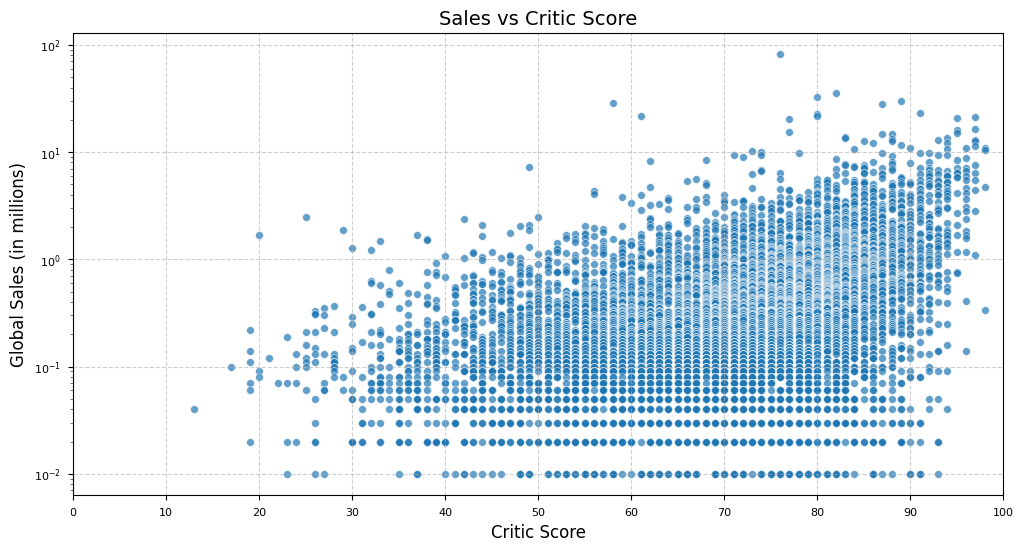

In [9]:
# Since ratings seem to matter, is there a direct relationship between the critic score (Critic_Score) and global sales? 
# # In order to investigate this, we can create a scatter plot with the number of copies sold on the y-axis and the critic score on the x-axis.
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Critic_Score', y='Global_Sales', alpha=0.7)
plt.title('Sales vs Critic Score', fontsize=14)
plt.xlabel('Critic Score', fontsize=12)
plt.ylabel('Global Sales (in millions)', fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(ticks=np.arange(0, 101, 10), labels=[f'{x}' for x in np.arange(0, 101, 10)]) # Organize the x-axis ticks
plt.xlim(0, 100)
plt.yscale('log') # Here we used a logarithmic scale for the y-axis in order to better visualize the sales distribution
plt.show()

# The scatter plot shows a positive relationship: games with higher scores tend to sell more. However, there is a large variance;
# meaning a high score does not guarantee high sales, but very few games with low scores become best-sellers.


- ##### **Line Plots:** line plots are used to visualize the relationship between two continuous variables. They are particularly useful for showing trends over time.

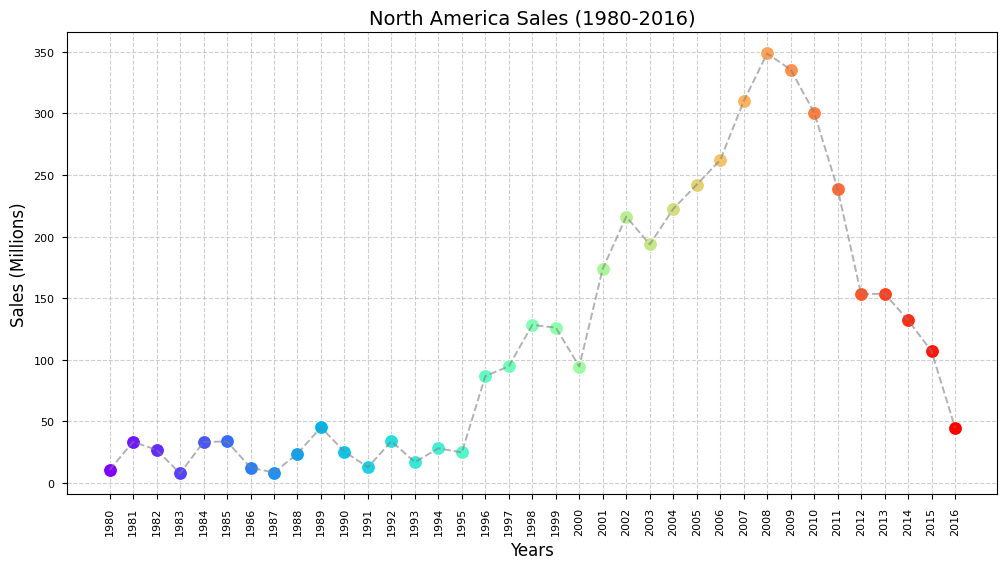

In [10]:
# Another example would be to analyze the North American sales over the years.
NA_Sales = df.groupby("Year_of_Release")["NA_Sales"].sum()
NA_Sales = NA_Sales.drop([2017, 2020]) # Drop years with incomplete data
NA_Sales.index = NA_Sales.index.astype(int) # Convert years to int
plt.figure(figsize=(12, 6))
sns.lineplot(
    x=NA_Sales.index,
    y=NA_Sales.values,
    hue=NA_Sales.index,
    palette="rainbow",
    marker="o",
    markersize=10,
    legend=False
)
plt.plot(NA_Sales.index, NA_Sales.values, linestyle='--', color='gray', alpha=0.6)
plt.ticklabel_format(useOffset=False, style='plain', axis='x') # Avoid scientific notation
plt.xticks(range(min(NA_Sales.index), max(NA_Sales.index)+1), rotation=90) # Organize x-axis ticks
plt.grid(True, linestyle="--", alpha=0.6)
plt.xlabel("Years", fontsize=12)
plt.ylabel("Sales (Millions)", fontsize=12)
plt.title("North America Sales (1980-2016)", fontsize=14)
plt.show()

---

## **Probability & Data Distributions**

#### The **goal** of this section is to build the theoretical bedrock upon which all statistical inference rests. We will journey from the fundamental rules of uncertainty to the practical application of sampling, creating a solid foundation for data-driven decision-making. This knowledge is crucial for understanding *why* statistical tests and machine learning models work.

- **Foundations of Probability:** We will begin with the core language of uncertainty, defining conditional probability, independence, and the powerful **Bayes' Theorem** for updating beliefs.

- **Random Variables & Distributions:** Next, we will translate random outcomes into numerical values and study the key theoretical distributions (**Normal, Binomial, Poisson**) that model a vast range of real-world phenomena.

- **Theory of Estimation:** We will then bridge the gap between samples and populations by exploring how to use sample statistics to estimate unknown population parameters.

- **Sampling in Practice:** Finally, we will bring the theory to life by demonstrating the **Central Limit Theorem**, showing how the properties of samples allow us to make reliable inferences about the whole.

### **1. The Language of Uncertainty: From Probability to Distributions**

#### **1.1 Probability Fundamentals**

##### To understand inference, we must first speak the language of uncertainty: probability. This part covers the essential rules and concepts that govern how we reason about random events, from basic definitions to the powerful idea of updating our beliefs as we gather more data.

##### **1.1.1 The Core Components**

In the relative frequency approach, probability is simply how likely an event is to occur, and is always a number between 0 and 1 (although it can also be expressed as a percentage between 0% and 100%). A probability of 0 means the event will never happen, while a probability of 1 means it will always happen. To calculate the probability of an event, we use the formula:

##### $$ \boxed{P(E) = \frac{\text{Number of outcomes in an event}}{\text{Total number of possible outcomes}}} $$

- **Random Experiment:** An action or process that leads to one of several possible outcomes, where the outcome cannot be predicted with certainty.

- **Sample Space:** The set of all possible outcomes of a random experiment.

- **Events:** Set of outcomes of interest.

**Example 1:** Suppose we have a bag with 10 balls: 5 red, 3 blue and 2 green. Consider the *random experiment* of drawing one ball from the bag. What is the probability of drawing a red ball?

- **Solution:**
  - The *sample space (S)* consists of all possible outcomes: {Red, Blue, Green}.
  - The *event (E)* of interest is drawing a red ball. This can be represented as E = {Red} = {${R_1, R_2, R_3, R_4, R_5}$} (since there are 5 red balls).
  - The number of favorable outcomes for event E (drawing a red ball) is 5 (since there are 5 red balls).
  - The total number of possible outcomes is 10 (since there are 10 balls in total) or S = {${R_1, R_2, R_3, R_4, R_5, B_1, B_2, B_3, G_1, G_2}$}.
- Using the probability formula, we can calculate the probability of drawing a red ball: ${P(E) = \frac{5}{10} = 0.5 = 50\%}$

**Example 2:**: Consider a person that is buying a game from our dataset (random experiment 2). The person can choose between several categories of games: Action, Strategy, Puzzle, etc. What is the probability that the person will choose an Action game? 


In [11]:
# The total number of possible outcomes is the total number of games in our dataset.
total_outcomes = len(df)

# The number of outcomes in our event is the number of games with the genre 'Action'.
action_outcomes = len(df[df['Genre'] == 'Action'])

# Calculate the empirical probability
p_action_empirical = action_outcomes / total_outcomes

display(Latex(fr"The probability of a randomly selected game being from the 'Action' genre is: "
              fr"$P(\text{{Action}}) = \frac{{\text{{Number of Action Games}}}}{{\text{{Total Number of Games}}}} = "
              fr"\frac{{{action_outcomes}}}{{{total_outcomes}}} \approx {p_action_empirical*100:.2f}\%$ ."))

<IPython.core.display.Latex object>

In order to describe static events, i.e, those that do not depend on other events, we use the following rules:

- **Complement Rule:** The probability of an event **NOT** occurring is equal to 1 minus the probability of the event occurring.

  $ \boxed{P(A^{c} ) = 1 - P(A)} $

- **Intersection Rule:** The probability of two events A and B **both** occurring (i.e., the intersection of A and B) is given by:

  $ \boxed{P(A \cap B)}$

- **Union Rule:** The probability of either event A **OR** event B occurring (i.e., the union of A and B) is given by:

  $ \boxed{P(A \cup B) = P(A) + P(B) - P(A \cap B)} $

We also use **Venn diagrams** to visualize the relationships between different events and their probabilities. In a Venn diagram, each event is represented by a circle, and the area of overlap between circles represents the intersection of events, while the area outside the circles represents the complement of events, and the entire area covered by the circles represents the union of events.

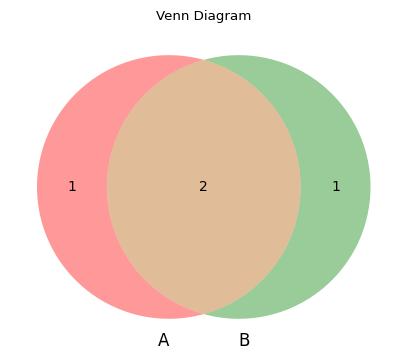

The intersection (A ∩ B), represented by the overlapping area with number 2, are the outcomes that are common to both events A and B. The regions labeled 1 represent outcomes that belong exclusively to either event A or event B.


In [12]:
from matplotlib_venn import venn2

plt.figure(figsize=(5,5))
venn2(subsets=(1, 1, 2), set_labels=("A", "B"))
plt.title("Venn Diagram")
plt.show()
print('The intersection (A ∩ B), represented by the overlapping area with number 2, are the outcomes that are common to both events A and B. ' \
'The regions labeled 1 represent outcomes that belong exclusively to either event A or event B.')


##### **1.1.2 Conditional Probability & Independence**

* **Independent Events:** Consider two events, A and B, that happen *simultaneously*. They are **independent** if the occurrence of one event does **NOT** affect the probability of the other event occurring. Mathematically, this is expressed as:

    $\boxed{P(A ∩ B) = P(A) * P(B)}$

    **Example:** Suppose we have two events: rolling a die and flipping a coin. What is the probability of rolling a 6 and getting heads on the coin flip? 

  **Solution:** 
    - Since the outcome of rolling the die does not affect the outcome of flipping the coin, and vice versa, these two events are independent. So, the probability of both events occurring is:

        $ P(6 \text{ and Heads}) = P(6) * P(\text{Heads}) = \frac{1}{6} \cdot \frac{1}{2} = \frac{1}{12} \approx 0.0833 $ (or 8.33%)

* **Conditional Probability:** Consider two events, A and B, that happen *sequentially*. If the occurrence of event B affects the probability of event A, then we say that B is **conditional** on A. Mathematically, this is expressed as:

    $\boxed{P(A|B) = \frac{P(A ∩ B)}{P(B)}}$

    The equation above states that 'the probability of A given (|) B' is equal to the probability of both A and B occurring together, divided by the probability of B. In other words, it tells us: out of all the times B happens, how often does A also happen?

    It allows us to update our beliefs about the likelihood of an event based on new information, meaning the probabilities are not static, but can change as we learn more about the situation.

    **Example:** Suppose we have a deck of 52 playing cards, and we want to find the probability of drawing a King of Spades  given that we have already drawn a card and it is a king.

    **Solution:**
    - Let A be the event of drawing a King of Spades, and B be the event of drawing a King. We want to find P(A|B), the probability of drawing a King of Spades given that we have drawn a King.
    - There are 4 Kings in a deck of 52 cards, and only one of them is the King of Spades. So, P(A ∩ B) = P(drawing King of Spades) = $\frac{1}{52}$.
    - The probability of drawing a King (event B) is P(B) = $\frac{4}{52}$.
    - Now, we can use the conditional probability formula to find P(A|B):

      $P(A|B) = \frac{P(A ∩ B)}{P(B)} = \frac{\frac{1}{52}}{\frac{4}{52}} = \frac{1}{4} = 0.25$ (or 25%)

    **Example 2:** What is the probability of a game being from the 'Action' genre given that it was released on the PS4 platform?

In [13]:
# Our new "universe" is only games released on the PS4 platform.
df_ps4 = df[df['Platform'] == 'PS4']

# Now, within this universe, what is the probability of the genre being 'Action'?
# This is simply the proportion of 'Action' games within the df_ps4 DataFrame.
p_action_given_ps4 = (df_ps4['Genre'] == 'Action').mean() # shortcut for calculating proportion

# Display the results
total_ps4_games = len(df_ps4)
action_on_ps4 = len(df_ps4[df_ps4['Genre'] == 'Action'])

display(Latex(fr"There are ${total_ps4_games}$ games on the PS4 platform in the dataset."))
display(Latex(fr"Out of those, ${action_on_ps4}$ are of the 'Action' genre."))
display(Latex(fr"Therefore, the probability of a game being 'Action' GIVEN it is on PS4 is: "
              fr"$P(A|S) = \frac{{{action_on_ps4}}}{{{total_ps4_games}}}$ $\approx {p_action_given_ps4*100:.2f}\%$."))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

* Previously, we've seen that if $P(A ∩ B) = P(A) \cdot P(B)$, then A and B are independent. Given what we know about conditional probability, we can also write the equation as follows:

    $\boxed{P(A|B) = P(A)}$

    This means that if the probability of A occurring given B is the same as the probability of A occurring on its own, then A and B are independent events. In other words, knowing that B has occurred does not change the likelihood of A occurring. Given this information, we can write a **General Multiplication Rule** for events that might not be independent: 

    $\boxed{P(A ∩ B) = P(A|B) \cdot P(B)}$



    **Example 3:** Supose we have a class of 100 students, and we want to find out if passing the midterm exam (event A) is independent of passing the final exam (event B). The results are as follows:
    - 50 pass mid and final exams.
    - 10 pass mid but fail final.
    - 5 fail mid but pass final.
    - 35 fail both exams.



In [14]:
# We can create a table that shows the joint probabilities of all the events possible. In this case, we have: Pass Midterm, Pass Final, Fail Midterm, Fail Final.
# The joint probability table would look like this:

df_joint = pd.DataFrame({
    'Pass Final': [50, 5, 55],
    'Fail Final': [10, 35, 45],
    'Total': [60, 40, 100]
}, index=['Pass Mid', 'Fail Mid', 'Total'])
display(df_joint)

# The values in the center of the table represent the joint probabilities of the events. For example, the value 50 represents the number of students who passed both 
# the midterm and final exams, therefore P(Pass Mid ∩ Pass Final) = 50/100 = 0.50
# The values in the margins (last row and last column) represent the marginal probabilities of each event. For example, the value 60 in the last row represents the
# total number of students who passed the midterm exam, therefore P(Pass Mid) = 60/100 = 0.60

# To check if the events are independent, we can use the multiplication rule of probability and our joint probability table
# P(A ∩ B) = P(A) * P(B) if A and B are independent events.
# Let's check if passing the midterm and passing the final are independent events.
# P(Pass Mid) = 60/100 = 0.60
# P(Pass Final) = 55/100 = 0.55
# P(Pass Mid ∩ Pass Final) = 0.60 * 0.55 = 0.33
# However, from the joint probability table, we know that P(Pass Mid ∩ Pass Final) = 50/100 = 0.50
# Since 0.33 ≠ 0.50, we can conclude that passing the midterm and passing the final are not independent events.

,Pass Final,Fail Final,Total
Pass Mid,50,10,60
Fail Mid,5,35,40
Total,55,45,100



&emsp;&emsp;    **Example 4:** Are the events of being of the Genre 'Action' (event A) and being released on the PS4 platform (event B) independent?

In [15]:
# 1. Calculate the overall probability of a game being 'Action' (our P(A))
# We already calculated this in section 1.1.1, let's recalculate for clarity.
p_A = (df['Genre'] == 'Action').mean()

# 2. Get the conditional probability P(Action | PS4) (our P(A|B))
# We just calculated this intuitively above.
p_A_given_B = p_action_given_ps4

# 3. Compare them.
display(Latex(fr"The overall probability of a game being 'Action' is $P(A) \approx {p_A:.4f}$."))
display(Latex(fr"The probability of a game being 'Action' GIVEN it is on PS4 is $P(A|B) \approx {p_A_given_B:.4f}$."))

# Conclusion
if np.isclose(p_A, p_A_given_B):
    display(Latex(r"Since $P(A|B)$ is approximately equal to $P(A)$, the events are **independent**."))
else:
    display(Latex(r"Since $P(A|B)$ is not equal to $P(A)$, the events are **NOT** independent."))
    display(Latex(r"In fact, knowing a game is on PS4 makes it MORE likely to be an Action game."))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

* **Law of Total Probability:** We can use the law of total probability when we have a set of mutually exclusive and exhaustive events that partition the sample space. This law allows us to calculate the probability of an event A by considering all the different ways that A can occur through these partitioning events. 

    $\boxed{P(A) = \sum_{i}^{N} P(A|B_i) \cdot P(B_i)}$
    
    **Example:** Suppose we have two bags of balls. Bag A contains 5 red balls and 5 blue balls, while Bag B contains 1 red ball and 7 blue balls. A bag is chosen at random, and then a ball is drawn from that bag. What is the total probability of drawing a blue ball? 

  **Solution:** 
    - Let $A$ be the event of drawing a blue ball. Let $B_1$ be the event of choosing Bag $A$, and $B_2$ be the event of choosing Bag $B$. We want to find P(A), the total probability of drawing a blue ball.   

    - The conditional probabilities (the probability of drawing a blue ball given a specific bag was chosen) are:
      - $ P(A|B_{1}) = \frac{5}{10} = 0.5$
      - $ P(A|B_{2}) = \frac{7}{8} = 0.875$ 

    - Since a bag is chosen at random, the probability of choosing each bag is:
      - $ P(B_{1}) = 0.5$
      - $ P(B_{2}) = 0.5$

    - Now we can use the law of total probability to find P(A):

      - $ P(A) = P(A|B_{1}) \cdot P(B_{1}) + P(A|B_{2}) \cdot P(B_{2}) = (0.5 \cdot 0.5) + (0.875 \cdot 0.5) = 68.75\%$


##### **1.1.3 Bayes' Theorem**

Summarizing what we've learned so far, we can combine the concepts of conditional probability and the law of total probability to arrive at **Bayes' Theorem**. It is specially useful when we have the $P(B|A)$ and want to find the reverse conditional probability $P(A|B)$. Mathematically:

##### $$ \boxed{P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}} $$

The equation above states that 'the probability of A given B is equal to the probability of B given A, multiplied by the probability of A, divided by the probability of B. Each component has a specific interpretation:

- $P(A)$ is known as the **prior belief**, representing our initial probability about the likelihood of event A before considering the evidence B. 
- $P(B|A)$ is called the **likelihood**, indicating how probable the evidence B is, assuming that event A has occurred. 
- $P(B)$ is the **marginal probability or evidence** of event B, representing the total probability of B occurring under all possible scenarios.

This is perhaps the most important rule in data science for performing inference. It provides a mathematical formula for updating our initial beliefs (prior probability) with new evidence to arrive at a refined belief (posterior probability).

- Since the denominator $P(B)$ is rarely known, we can use the **Law of Total Probability** to rewrite Bayes' Theorem as follows:

#####    $$ \boxed{P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B|A) \cdot P(A) + P(B|A^{c}) \cdot P(A^{c})}} $$

**Example:** Historical data shows: 20% of days are rainy. On rainy days, 80% are cloudy. On non-rainy days, 30% are cloudy. What is the probability that a day is rainy given that it is cloudy?

**Solution:**
- Let R be the event of a rainy day, and C be the event of a cloudy day. We want to find P(R|C), the probability of a rainy day given that it is cloudy.
- We know:
  - $P(R) = 0.2$ (prior probability of a rainy day)
  - $P(C|R) = 0.8$ (likelihood of a cloudy day given a rainy day)
  - $P(C|R^c) = 0.3$ (likelihood of a cloudy day given a non-rainy day)
  - $P(R^c) = 0.8$ (prior probability of a non-rainy day)
- Therefore, we can conclude that:

  - 0.16 of the days are rainy and cloudy, since 80% of the rainy days are cloudy and 20% of the days are rainy (0.2 * 0.8 = 0.16)
  - 0.24 of the days are non-rainy and cloudy, since 30% of the non-rainy days are cloudy and 80% of the days are non-rainy (0.8 * 0.3 = 0.24)
  - The total probability of a cloudy day is P(C) = 0.16 + 0.24 = 0.4
  - Now we can use Bayes' Theorem to find P(R|C):

    $ P(R|C) = \frac{P(C|R) \cdot P(R)}{P(C)} = \frac{0.8 \cdot 0.2}{0.4} = 0.4 = 40\% $

In [16]:
# The example above is easier to understand if we use a joint probability table.

bayes_table = pd.DataFrame({'Rainy': [0.16, 0.04, 0.2], 'Not Rainy': [0.24, 0.56, 0.8],'Total': [0.4, 0.6, 1.0]}, index=['Cloudy', 'Not Cloudy', 'Total'])
display(bayes_table)

,Rainy,Not Rainy,Total
Cloudy,0.16,0.24,0.4
Not Cloudy,0.04,0.56,0.6
Total,0.20,0.80,1.0


**Example 2:** Given that a game in our dataset was considered a success, what is the probability that it was from the 'Action' genre? Note: Consider a game a success if its global sales are above 1 million units.

In [17]:
# We want to know P(A|S), where A is the event of being action and S is the event of being a success.
# A game is considered a success if its global sales are above 1 million units.
# By bayes theorem, we have: P(A|S) = P(S|A) * P(A) / P(S)
df = pd.read_csv('../data/Video_Games_Sales.csv')
df = df[['Genre', 'Global_Sales']].dropna()
df['Global_Sales'] = df['Global_Sales'].astype(float)
df['Success'] = df['Global_Sales'] > 1
display(df)

# The probability of being action (event A) is:
Action = df.groupby('Genre').size()
P_Action = Action.get('Action', 0) / Action.sum()
display(Latex(fr"The probability of a game being in the 'Action' genre is $P(A) = {P_Action:.3f}$."))

# The probability of being a success (event S) is:
P_Success = df['Success'].sum() / len(df)
display(Latex(fr"The probability of a game being a success is $P(S) = {P_Success:.3f}$."))

# The probability of being a success given that the game is action (event S|A) is:
P_S_given_A = df[df['Genre'] == 'Action']['Success'].sum() / Action.get('Action', 0)
display(Latex(fr"The probability of a game being a success given that it is in the 'Action' genre is $P(S|A) = {P_S_given_A:.3f}$."))

# Finally, we can calculate P(A|S):

P_A_given_S = P_S_given_A * P_Action / P_Success
display(Latex(fr"The probability of a game being in the 'Action' genre given that it is a success is $P(A|S) = {P_A_given_S:.2f}$."))

,Genre,Global_Sales,Success
0,Sports,82.53,True
1,Platform,40.24,True
2,Racing,35.52,True
3,Sports,32.77,True
4,Role-Playing,31.37,True
...,...,...,...
16714,Action,0.01,False
16715,Sports,0.01,False
16716,Adventure,0.01,False
16717,Platform,0.01,False


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

##### **1.1.4 Random Variables & Probability Distributions**

* **Random Variable:** A random variable is a statistic or an individual observation/process that can take on different values based on the outcome of a random event. There are two main types of random variables:


    * **Discrete Random Variables**: Those can only assume a finite or countably infinite number of possible values and are described by a **Probability Mass Function (PMF)**. The *pmf* is a function that gives the probability that a discrete random variable is exactly equal to some value.
    
    * **Continuous Random Variables**: Those can assume any value in a specified interval and are described by a **Probability Density Function (PDF)**. 
    The *pdf* is a function that describes the likelihood of a **continuous** random variable taking on a particular value. The probability in this case is represented by the area under the curve of the pdf over a specific interval, rather than the height of the curve at a specific point. Mathematically:

    #### $$ \boxed{P(a < X < b) = \int_{a}^{b} f(x) \, dx} $$

    * **Cumulative Distribution Function (CDF)**: typically denoted as **$F(x)$**, is a fundamental concept in probability. It provides the probability that a random variable X will take on a value that is **less than or equal** to a specific value x (threshold). Simply put, the CDF accumulates probability as x increases. It is very usefull for:

        - Calculating probabilities over intervals: It provides an efficient way to find the probability that X falls within a range (a, b). Instead of summing or integrating, you can simply calculate:

            $P(a < X \leq b) = F(b) - F(a)$.

        - Verifying distributions: The CDF serves as a powerful check for the validity of a Probability Mass Function (PMF) or Probability Density Function (PDF). A valid CDF must range from 0 to 1. If the function does not converge to 1 as x approaches infinity, the underlying probability distribution is flawed.

        The CDF is defined differently for discrete and continuous random variables:

        - For a discrete random variable, the CDF is the sum of the PMF:

            $ \boxed{F(x) = P(X \leq x) = \sum_{t \leq x} P(X = t)} $

        - For a continuous random variable, the CDF is the integral of the PDF:

            $ \boxed{F(x) = P(X \leq x) = \int_{-\infty}^{x} f(t) \, dt} $

    * **Expected Value (EV):** The expected value (EV) of a random variable is a measure of its central tendency, representing the **long-term average outcome** of the random variable over many trials. It is calculated by multiplying each possible value of the random variable by its corresponding probability and summing these products.

        - For a discrete random variable:

            $ \boxed{E[X] = \sum_{x} x \cdot P(X = x)} $

        - For a continuous random variable:

            $ \boxed{E[X] = \int_{-\infty}^{\infty} x \cdot f(x) \, dx} $  

    * **Variance ($\sigma^2$):** The variance of a random variable is a **measure of its dispersion** or **spread around the expected value**. It quantifies how much the values of the random variable deviate from the mean on average. It is calculated by taking the expected value of the squared differences between each possible value and the expected value.

        - For a discrete random variable:

            $ \boxed{Var(X) = E[(X - E[X])^2] = \sum_{x} (x - E[X])^2 \cdot P(X = x)} $

        - For a continuous random variable:

            $ \boxed{Var(X) = E[(X - E[X])^2] = \int_{-\infty}^{\infty} (x - E[X])^2 \cdot f(x) \, dx} $
    
    * **Standard Deviation ($\sigma$):** The standard deviation is the square root of the variance, providing a measure of dispersion in the same units as the random variable itself.


    Note the strong connection with [exploratory analysis](##1-measures-of-central-tendency): the Expected Value, $E[X]$, of a random variable is the theoretical analogue of the sample mean ($\bar{x}$), and the Variance, $Var(X)$, is the theoretical analogue of the sample variance ($s^{2}$). Probability theory provides the foundation for understanding the long-term behavior of these metrics.


* **Example**: Consider the games rating score from our dataset. We can treat these scores as a discrete random variable X, where each score has a certain probability of occurring based on the frequency of that score in the dataset. Divide the data into the top-4 most common ratings and group the rest into an "Other" category. Then, plot the PMF for this discrete random variable.

array(['E', 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

Rating_grouped
E        3991
T        2961
M        1563
E10+     1420
Other      15
Name: count, dtype: int64

/tmp/ipykernel_13317/2139430176.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating_grouped', stat='probability', order=df['Rating_grouped'].value_counts().index, palette='rainbow')


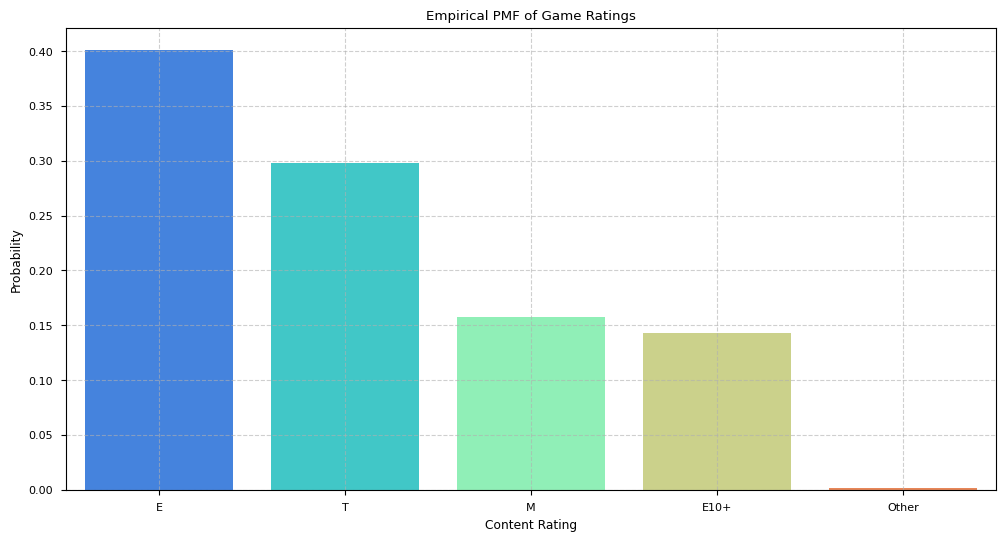

In [18]:
df = pd.read_csv('../data/Video_Games_Sales.csv')
df = df[['Name', 'Rating']].dropna()
display(df['Rating'].unique()) # Display the unique ratings available
# Group less common ratings into 'Other'
top_ratings = df['Rating'].value_counts().nlargest(4).index # Get the top 4 most common ratings
df['Rating_grouped'] = df['Rating'].where(df['Rating'].isin(top_ratings), 'Other') # Create a new column with the grouped ratings, where less common ratings are labeled as 'Other'
display(df['Rating_grouped'].value_counts())
# Plot the empirical PMF
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Rating_grouped', stat='probability', order=df['Rating_grouped'].value_counts().index, palette='rainbow')
plt.title('Empirical PMF of Game Ratings')
plt.xlabel('Content Rating')
plt.ylabel('Probability')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

* **Example 2**: Consider the variable "Critic_Score" from our dataset. We can treat these scores as a continuous random variable Y, where the scores can take on any value within a certain range (e.g., 0 to 100). We can estimate the PDF of this continuous random variable using techniques such as kernel density estimation or by fitting a theoretical distribution to the data. Plot the PDF and CDF for the "Critic_Score" variable.

,Critic_Score
0,76.0
2,82.0
3,80.0
6,89.0
7,58.0
...,...
16700,61.0
16701,53.0
16702,48.0
16706,60.0


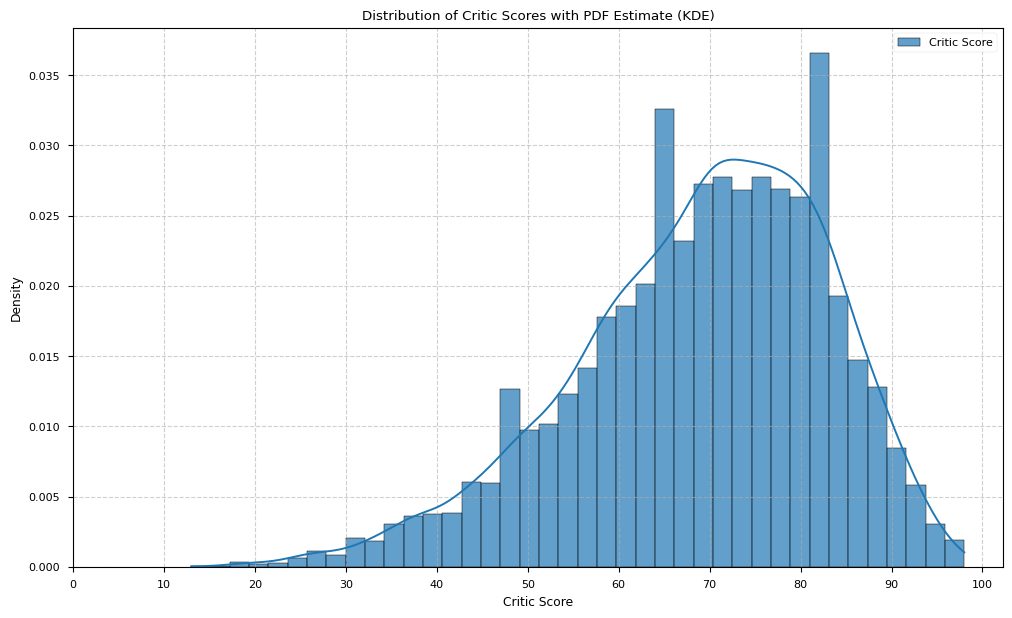

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

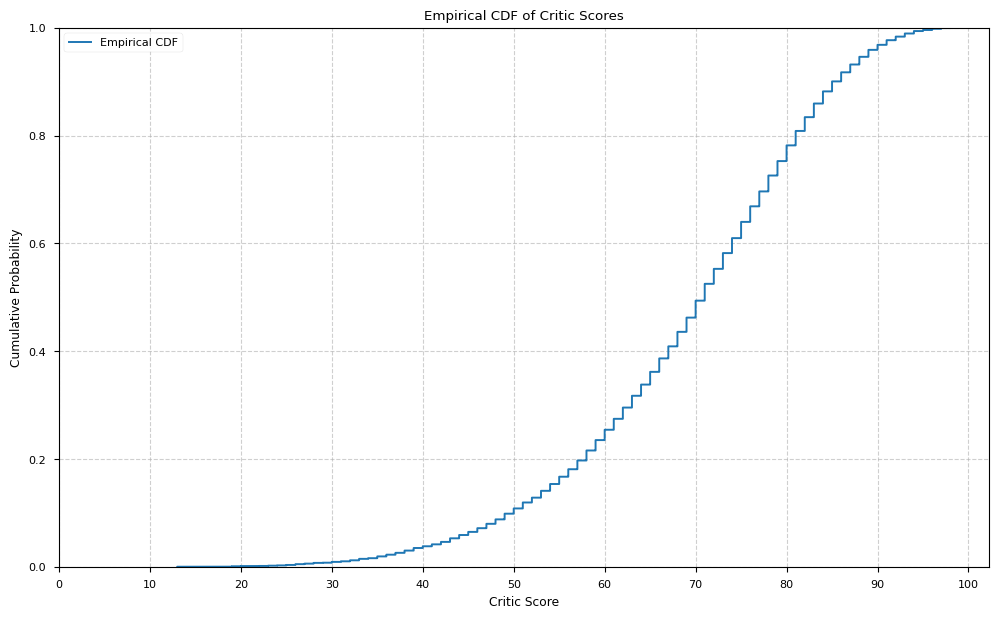

<IPython.core.display.Latex object>

In [19]:
# In order to plot the PDF we will use the Kernel Density Estimation (KDE) method, which is a non-parametric way to estimate the probability density function
# of a random variable. We do this by plotting a histogram, that groups continuous data into discrete "bins" to estimate the shape of the distribution. The
# PDF is the smooth and theoretical curve that the histogram is trying to approximate.
df = pd.read_csv('../data/Video_Games_Sales.csv')
df = df[['Critic_Score']].dropna()
display(df)

# Plot the histogram and the PDF estimate (KDE)
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='Critic_Score', bins=40, kde=True, linewidth=0.35, alpha=0.7, stat='density', label='Critic Score') # kde=True adds the Kernel Density Estimate (KDE) line
plt.title('Distribution of Critic Scores with PDF Estimate (KDE)')
plt.xlabel('Critic Score')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(ticks=np.arange(0, 101, 10), labels=[f'{x}' for x in np.arange(0, 101, 10)])
plt.legend()
plt.show()

display(Latex("The bars represent the histogram, a binned count of the data."))
display(Latex("The smooth line is the Kernel Density Estimate (KDE), which is our best guess for the underlying continuous Probability Density Function (PDF)."))


# Plot the CDF
plt.figure(figsize=(12, 7))
sns.ecdfplot(data=df, x='Critic_Score', label='Empirical CDF')
plt.title('Empirical CDF of Critic Scores')
plt.xlabel('Critic Score')
plt.ylabel('Cumulative Probability')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(ticks=np.arange(0, 101, 10), labels=[f'{x}' for x in np.arange(0, 101, 10)])
plt.legend()
plt.show()

display(Latex("The Empirical CDF shows the cumulative probability up to each score value. Since we collect the data from the df, the values are discrete, therefore the CDF is a step function."))


* **Example 3**: What is the probability of a game having a critic score of 75 or less? And what is the probability of having a score between 50 and 75?

In [20]:
# Calculate the probability for a specific value (e.g., score <= 75)
prob_at_75 = (df['Critic_Score'] <= 75).mean()

# Calculate the probability for another value (e.g., score <= 50)
prob_at_50 = (df['Critic_Score'] <= 50).mean()

# The probability of being in the interval (50, 75] is the difference
prob_50_to_75 = prob_at_75 - prob_at_50

# Calculate the probability of being in the interval [50, 75]
prob_50_to_75 = prob_at_75 - prob_at_50

display(Latex(fr"The probability of a game having a critic score $\leq 75\%$ is approximately ${prob_at_75:.2%}$ $\%$."))
display(Latex(fr"The probability of a game having a critic score between 50\% and 75\% is approximately ${prob_50_to_75:.2%}$ $\%$."))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

*  For more details on how the the Kernel Density Estimation method works, check: [Towards Data Science: Intuitive derivation of the KDE formula ](https://towardsdatascience.com/kernel-density-estimation-explained-step-by-step-7cc5b5bc4517/).

#### **1.2 Modeling Real-World Phenomena: Common Probability Distributions**

##### Now that we understand the fundamentals of random variables, we can explore how they are used to model the world. Different random processes follow different patterns, and **probability distributions** are mathematical functions that describe these patterns. For a data scientist, knowing the most common distributions is like having a toolkit of templates to understand and predict data. We will cover five of the most important distributions: **Normal, Binomial, Poisson, Exponential, and Log-Normal**.

##### **1.2.1 Binomial Distribution**


The binomial distribution can be thought of as a generalization of the product rule for independent events. It is used to model the total number of **successes** over a **fixed** number of trials, provided that certain conditions are met. First, each trial must have only **two possible outcomes**, typically labeled "success" and "failure." Second, the probability of success, denoted by **p**, must remain the **same for every trial**. Finally, each trial must be **independent**, meaning the outcome of one does not influence the outcome of another. Mathematically, the probability of getting exactly **k** successes in **n** trials is given by the formula:


##### $$\boxed{P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}}$$


where $\binom{n}{k}$ is the binomial coefficient, representing the number of ways to choose **k** successes from **n** trials.

- The mean ($\mu$) and variance ($\sigma^2$) of a binomial distribution are given by:

    - ##### $\boxed{\mu = n \cdot p}$

    - ##### $\boxed{\sigma^2 = n \cdot p \cdot (1 - p)}$


- **Example:** What is the probability of **exactly** 5 out of the next 8 *Nintendo* games being a 'critical success'? Consider a game a 'critical success' if its critic score is equal to or above 85.

,Publisher,Critic_Score,Success
0,Nintendo,76.0,False
2,Nintendo,82.0,False
3,Nintendo,80.0,False
6,Nintendo,89.0,True
7,Nintendo,58.0,False
...,...,...,...
13215,Nintendo,64.0,False
14295,Nintendo,71.0,False
16424,Nintendo,70.0,False
16514,Nintendo,82.0,False


<IPython.core.display.Latex object>

,Publisher,Critic_Score,Success
0,Nintendo,76.0,False
2,Nintendo,82.0,False
3,Nintendo,80.0,False
6,Nintendo,89.0,True
7,Nintendo,58.0,False
...,...,...,...
16700,Destineer,61.0,False
16701,Ubisoft,53.0,False
16702,Majesco Entertainment,48.0,False
16706,Unknown,60.0,False


<IPython.core.display.Latex object>

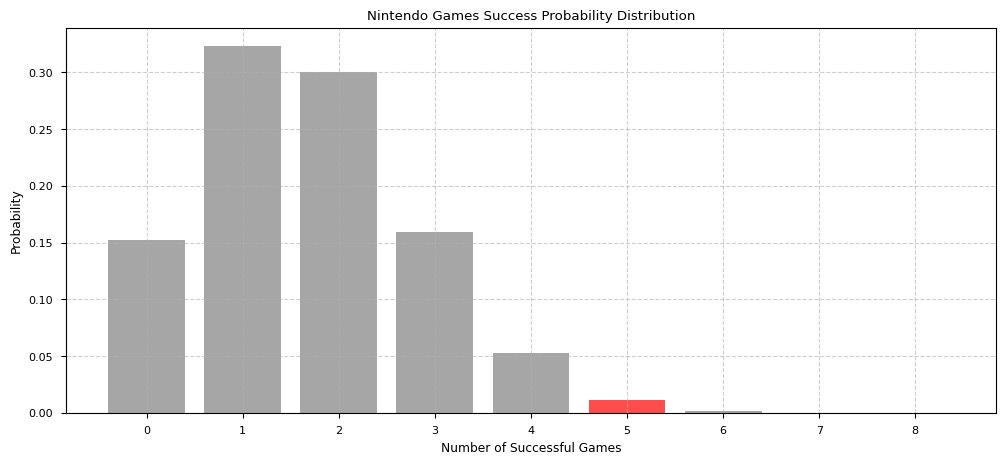

<IPython.core.display.Latex object>

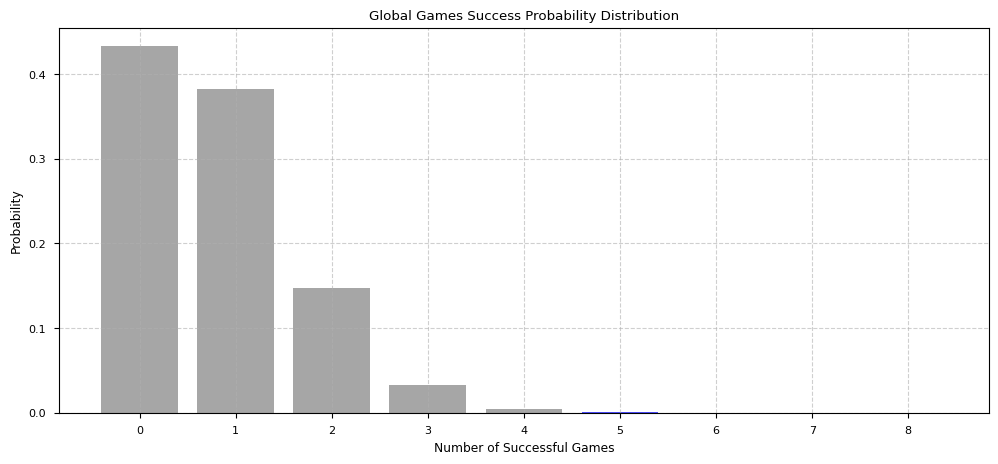

<IPython.core.display.Latex object>

In [21]:
# Nintendo has historically been known for producing high-quality games that receive excellent reviews from critics. Therefore, to accurately 
# model the future of the company's game ratings, we need to know its specific probability of success. This is a conditional probability: 
# P(Success | Publisher = 'Nintendo').

df = pd.read_csv('../data/Video_Games_Sales.csv')
df['Critic_Score'] = df['Critic_Score'].astype(float)
df = df[['Publisher', 'Critic_Score']].dropna()
df_nintendo = df[df['Publisher'] == 'Nintendo'].copy()
df_nintendo['Success'] = df_nintendo['Critic_Score'] > 85 # Let's define a "successful" game as one that has a Critic_Score above 85.
display(df_nintendo)
p_nintendo_success = df_nintendo['Success'].mean() # This is the conditional probability P(Success | Publisher = 'Nintendo')
display(Latex(fr"The probability of a Nintendo game being successful (Critic_Score > 85) is $\approx {p_nintendo_success*100:.2f}\%$."))

# Now, let's compare this with the overall probability of success for all games in the dataset.
df_global = df.copy()
df_global['Success'] = df_global['Critic_Score'] > 85
display(df_global)
p_global_success = df_global['Success'].mean() # This is the overall probability P(Success)
display(Latex(fr"The overall probability of a game from any publisher being successful (Critic_Score > 85) is $\approx {p_global_success*100:.2f}\%$."))

# Let's plot the probabilities:

# Nintendo
plt.figure(figsize=(12, 5))
k_success = 5
n_trials = 8
p_success = p_nintendo_success
# Plot the binomial distribution
x = np.arange(0, n_trials + 1)
colors = ['red' if val == k_success else 'grey' for val in x]
p_nintendo_5_success = binom.pmf(x, n_trials, p_success)
plt.bar(x, p_nintendo_5_success, color=colors, alpha=0.7)
plt.title('Nintendo Games Success Probability Distribution')
plt.xlabel('Number of Successful Games')
plt.ylabel('Probability')
plt.xticks(x)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
display(Latex(fr"The probability of the next {k_success} of {n_trials} **Nintendo** games being successful is $\approx {p_nintendo_5_success[5]*100:.2f}\%$."))

# Global
plt.figure(figsize=(12, 5))
k_success = 5
n_trials = 8
p_success = p_global_success
# Plot the binomial distribution
x = np.arange(0, n_trials + 1)
colors_2 = ['blue' if val == k_success else 'grey' for val in x]
p_next_5_success = binom.pmf(x, n_trials, p_success)
plt.bar(x, p_next_5_success, color=colors_2, alpha=0.7)
plt.title('Global Games Success Probability Distribution')
plt.xlabel('Number of Successful Games')
plt.ylabel('Probability')
plt.xticks(x)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
display(Latex(fr"The probability of the next {k_success} of {n_trials} games from **ANY** publisher being successful is $\approx {p_next_5_success[5]*100:.2f}\%$."))


##### **1.2.2 Poisson Distribution**


The Poisson distribution can be thought of as a limiting case of the binomial distribution, where the number of trials **n** approaches infinity, and the probability of success **p** approaches zero, such that the product $\lambda = n \cdot p$ remains constant. It is used to model the number of times an event occurs within a **fixed interval** of time or space, provided that certain conditions are met. First, the events must occur **independently**, meaning the occurrence of one event does not affect the occurrence of another. Second, the average rate of occurrence, denoted by **$\lambda$**, must remain **constant** over the interval. Finally, two events cannot occur at exactly the same instant; they must be separated by some minimum amount of time or space. Mathematically, the probability of observing exactly **k** events in a given interval is given by the formula:


##### $$\boxed{P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}}$$


where $\lambda$ is the average rate of occurrences in a given interval.

- The mean ($\mu$) and variance ($\sigma^2$) of a Poisson distribution are both equal to $\lambda$:

    - ##### $\boxed{\mu = \sigma^2 = \lambda}$


- **Example:** Since the 2000's the video game industry's growth has been significant, with a certain average number of games released per year. Based on this historical average rate ($\lambda$), what is the probability that in a future year, we would see **exactly 900** games released? Additionally, what is the probability of seeing **fewer than 850** games released? Consider the time period from 2000 to 2016 for your calculations.

Year_of_Release
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
dtype: int64

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

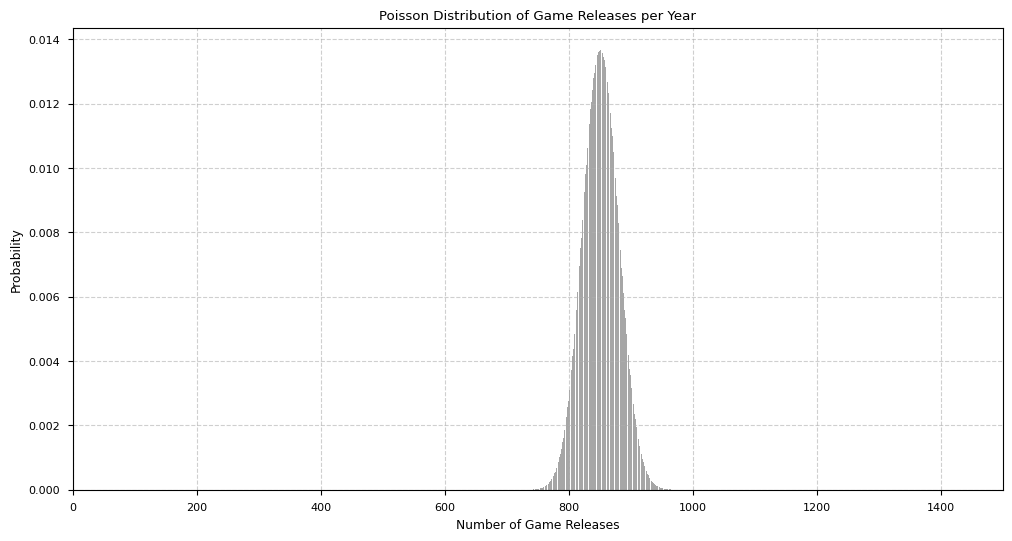

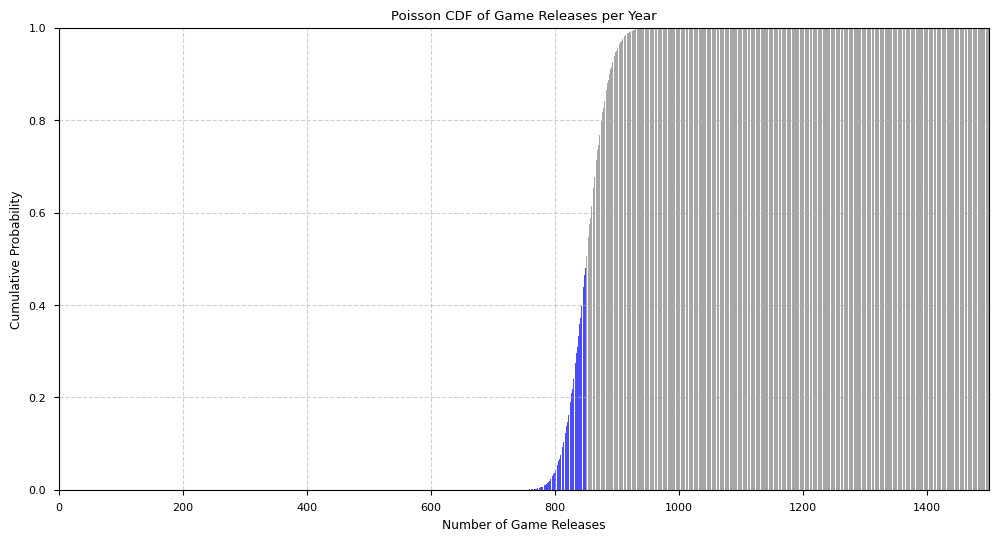

In [22]:
# First we need to calculate the average rate ($\lambda$) of game releases per year during the peak years (2005-2010).
df = pd.read_csv('../data/Video_Games_Sales.csv')
df = df[['Name', 'Year_of_Release']].dropna()
df['Year_of_Release'] = df['Year_of_Release'].astype(int)
df_peak_years = df[(df['Year_of_Release'] >= 2000) & (df['Year_of_Release'] <= 2016)]
display(df_peak_years.groupby('Year_of_Release').size())
average_releases_per_year = df_peak_years.groupby('Year_of_Release').size().mean()
display(Latex(fr"The average number of game releases per year during the peak years (2000-2016) is $\lambda \approx {average_releases_per_year:.2f}$."))

# Now we can use the Poisson distribution to calculate the probability of exactly 900 games being released in a year.
k = 900
k_poisson = np.arange(0, k + 1)
lambda_ = average_releases_per_year
p_900_games = poisson.pmf(k_poisson, lambda_)
display(Latex(fr"The probability of exactly {k} games being released in a year is $\approx {p_900_games[k]*100:.2f}\%$."))

# Next, in order to determine the probability of seeing fewer than 850 games, we need to calculate the cumulative probability for k < 850.
k_cdf = 850
k_less_than_850 = np.arange(0, k + 1)
p_less_than_850 = poisson.cdf(k_less_than_850, lambda_)
display(Latex(fr"The probability of fewer than {k_cdf} games being released in a year is $\approx {p_less_than_850[849]*100:.2f}\%$."))

# Finally, we can plot the Poisson distribution for the number of game releases per year.
plt.figure(figsize=(12, 6))
x = np.arange(0, 1500)
poisson_pmf = poisson.pmf(x, lambda_)
colors = ['red' if val == k else 'grey' for val in x]
plt.bar(x, poisson_pmf, color=colors, alpha=0.7)
plt.title('Poisson Distribution of Game Releases per Year')
plt.xlabel('Number of Game Releases')
plt.ylabel('Probability')
plt.xlim(0, 1500)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot the Poisson CDF
plt.figure(figsize=(12, 6))
x_cdf = np.arange(0, 1500)
poisson_cdf = poisson.cdf(x_cdf, lambda_)
colors_cdf = ['blue' if val < k_cdf else 'grey' for val in x_cdf]
plt.bar(x_cdf, poisson_cdf, color=colors_cdf, alpha=0.7)
plt.title('Poisson CDF of Game Releases per Year')
plt.xlabel('Number of Game Releases')
plt.ylabel('Cumulative Probability')
plt.xlim(0, 1500)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### **1.2.3 Exponential Distribution**


The exponential distribution is closely related to the Poisson distribution. While the first describes the number of events in a fixed interval, the exponential distribution describes the **time between events** in a Poisson process. It is used to model the time until the next event occurs, provided that the same conditions for the Poisson distribution are met. To obtain the formula for the exponential distribution, we start with the Poisson distribution and consider the probability of observing **zero** events in a given interval **t**. Mathematically, the probability of observing zero events in an interval of length t is $e^{-\lambda t}$, where $\lambda$ is the rate parameter of the Poisson distribution. If we consider T as the random variable representing the time until the next event, it follows that the probability that T is greater than t (i.e., no events occur in the interval [0, t]) is equal $e^{-\lambda t}$. Therefore, the probability that T is less than or equal to t (i.e., at least one event occurs in the interval [0, t]) is $1 - e^{-\lambda t}$. Since this last expression represents the cumulative distribution function (CDF) of the exponential distribution, we can differentiate it ($ \frac{d}{dt}(1 - e^{-\lambda t})$) to obtain the probability density function (PDF), which mathematically is given by the formula:

##### $$\boxed{f(t) = \lambda e^{-\lambda t}, \quad t \geq 0}$$

where $\lambda$ is the rate parameter.

- The mean ($\mu$) and standard deviation ($\sigma$) are equal and given by:

    - ##### $\boxed{\mu = \sigma = \frac{1}{\lambda}}$


- **Memoryless Property:** The exponential distribution has a unique property known as the memoryless property. This means that the probability of an event occurring in the future is independent of how much time has already passed. Mathematically, this can be expressed as:

    $\boxed{P(T > s + t | T > s) = P(T > t)}$

    This property is particularly useful in scenarios where the waiting time for an event does **NOT** depend on how long one has already waited.

- **Example:** Given that games were released at an average rate of λ per year between 2000 and 2016, the time between each release can be modeled by an Exponential Distribution. What is the probability that the time until the next game is released is less than half a day (approximately 0.00137 years)?


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

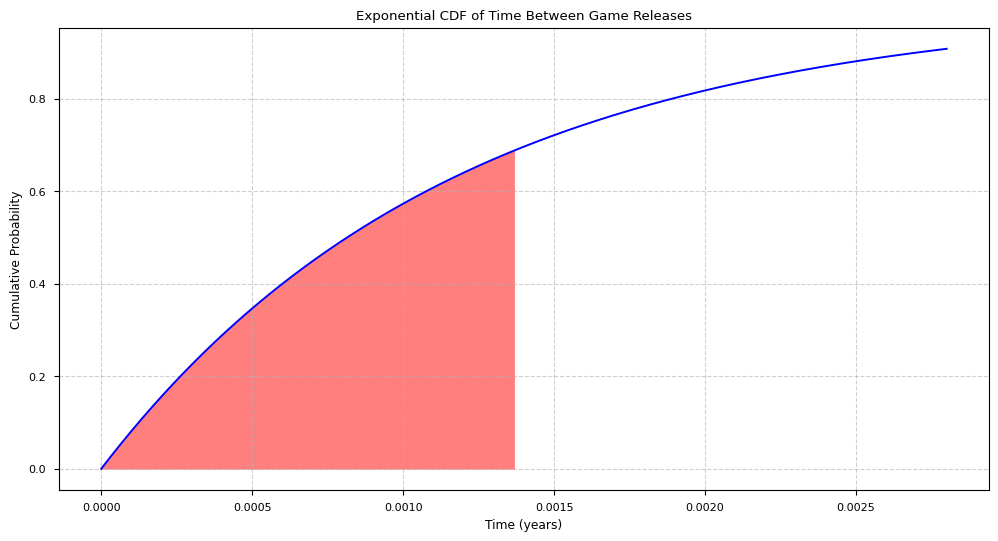

In [23]:
# We already obtained the rate parameter (λ) in section 1.3.1, let's recalculate for clarity.
df = pd.read_csv('../data/Video_Games_Sales.csv')
df = df[['Name', 'Year_of_Release']].dropna()
df['Year_of_Release'] = df['Year_of_Release'].astype(int)
df_peak_years = df[(df['Year_of_Release'] >= 2000) & (df['Year_of_Release'] <= 2016)]
average_releases_per_year = df_peak_years.groupby('Year_of_Release').size().mean()
# The rate parameter (λ) is the average number of game releases per year.
lambda_ = average_releases_per_year
display(Latex(fr"The rate parameter (λ) for game releases is approximately $\lambda \approx {lambda_:.2f}$ games per year."))

# Since we want to know the probability being last than half a day, we can use the cdf of the exponential distribution. 
P_less_half_day = expon.cdf(0.00137, scale=1/lambda_) # half a day is approximately  0.00137 years. scale = 1/lambda be
display(Latex(fr"The probability of waiting less than half a day for the next game release is $\approx {P_less_half_day*100:.2f}\%$."))

#Plot the CDF:
plt.figure(figsize=(12, 6))
# Define the range for x-axis (time in years)
x = np.linspace(0, 0.0028, 1000) # From 0 to 0.0028 years (about 1 day)
# Calculate the CDF values using the exponential distribution formula
expon_cdf = expon.cdf(x, scale=1/lambda_)
plt.plot(x, expon_cdf, color='blue')
plt.fill_between(x, 0, expon_cdf, where=(x <= 0.00137), color='red', alpha=0.5)
plt.title('Exponential CDF of Time Between Game Releases')
plt.xlabel('Time (years)')
plt.ylabel('Cumulative Probability')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### **1.2.4 Normal Distribution**


The normal (or Gaussian) distribution can be thought of as the cornerstone of probability and statistics. It is used to model a wide variety of natural phenomena, from heights and weights to test scores and measurement errors. It is characterized by its bell-shaped curve, which is *symmetric* around the mean. The mean ($\mu$) determines the center of the distribution, while the standard deviation ($\sigma$) controls the spread or width of the curve. Mathematically, the probability density function of a normal distribution is given by the formula:

##### $$\boxed{f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}}$$

where $x$ is the random variable value, $\mu$ is the mean, $\sigma$ is the standard deviation, and $e$ is the Euler's number.

- If $\mu = 0$ and $\sigma = 1$, the distribution is called the **standard normal distribution (STD)**. Every normal distribution can be transformed into the standard normal distribution using the **z-score** formula, which allows us to compare the spread between different normal distributions, even if they have different parameters. This re-scaling makes it possible to utilize the STD [table](https://math.arizona.edu/~rsims/ma464/standardnormaltable.pdf) to find probabilities and percentiles for **any** normal distribution. Mathematically, the **z-score** is given by:

    - ##### $\boxed{z = \frac{(X - \mu)}{\sigma}}$


- **The Empirical Rule:** The Empirical Rule states that for a normal distribution:

    - Approximately **68%** of the data falls within **one** standard deviation of the mean ($\mu \pm \sigma$).
    - Approximately **95%** of the data falls within **two** standard deviations of the mean ($\mu \pm 2\sigma$).
    - Approximately **99.7%** of the data falls within **three** standard deviations of the mean ($\mu \pm 3\sigma$).




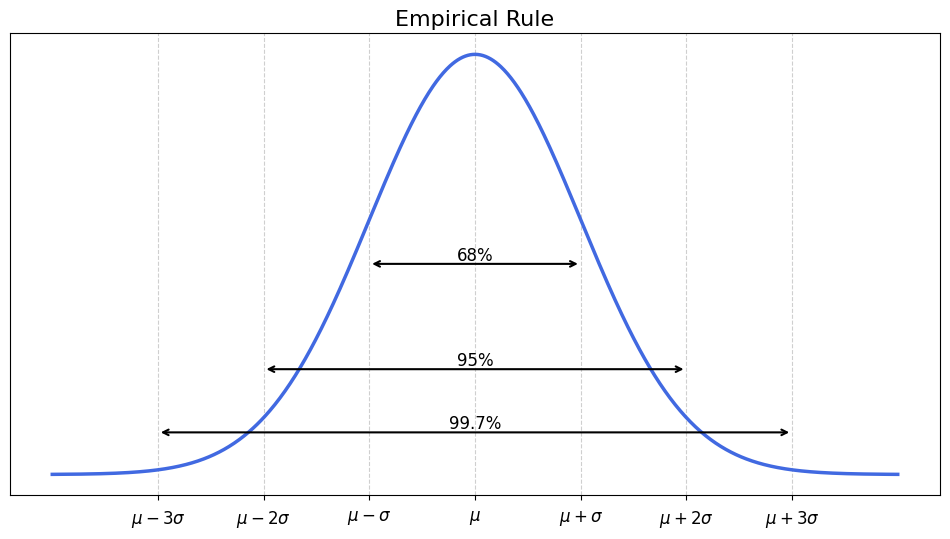

In [24]:
# Plot the Empirical Rule on a standard normal distribution
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(12, 6))
plt.plot(x, y, color="royalblue", linewidth=2.5, label="Curva Normal Padrão")


rule_data = [
    (1, "68%", 0.20),
    (2, "95%", 0.10),
    (3, "99.7%", 0.04)
]

for k, percentage, y_pos in rule_data:
    
    start = mu - k * sigma
    end = mu + k * sigma
    
    
    plt.annotate(
        '', xy=(start, y_pos), xytext=(end, y_pos),
        arrowprops={'arrowstyle': '<->', 'color': 'black', 'lw': 1.5}
    )
    
    
    plt.text(
        mu, y_pos, percentage, 
        ha="center", va="bottom", fontsize=12, color="black"
    )

plt.xticks(
    [mu - 3*sigma, mu - 2*sigma, mu - sigma, mu, mu + sigma, mu + 2*sigma, mu + 3*sigma],
    [r"$\mu-3\sigma$", r"$\mu-2\sigma$", r"$\mu-\sigma$", r"$\mu$",
     r"$\mu+\sigma$", r"$\mu+2\sigma$", r"$\mu+3\sigma$"],
    fontsize=12
)

plt.yticks([]) 
plt.title("Empirical Rule", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

- **Example:** The Critic_Score variable appears to be bell-shaped, suggesting it might follow a Normal Distribution. Verify this assumption both visually and statistically. First, plot a histogram with a Kernel Density Estimate (KDE) to visually inspect the distribution's shape. Then, create a Quantile-Quantile (Q-Q) plot to formally compare the data's quantiles to those of a theoretical Normal Distribution. Based on these plots, can we conclude that the Critic_Score data is approximately normally distributed?

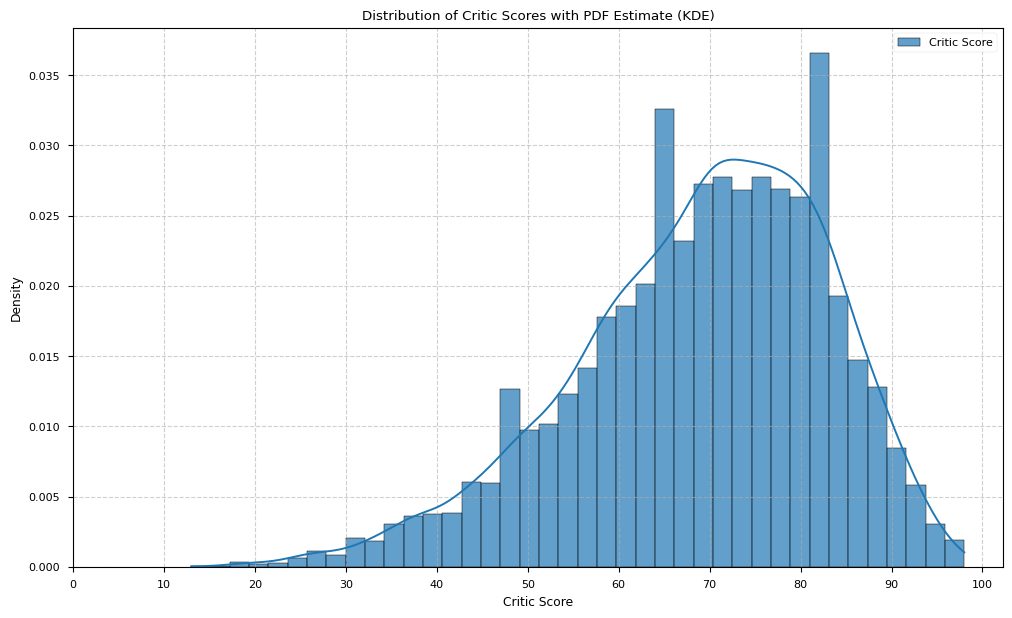

<IPython.core.display.Latex object>

In [25]:
df = pd.read_csv('../data/Video_Games_Sales.csv')
df['Critic_Score'] = df['Critic_Score'].astype(float)
df = df[['Critic_Score']].dropna()
# Plot the histogram and the PDF estimate (KDE)
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='Critic_Score', bins=40, kde=True, linewidth=0.35, alpha=0.7, stat='density', label='Critic Score') # kde=True adds the Kernel Density Estimate (KDE) line
plt.title('Distribution of Critic Scores with PDF Estimate (KDE)')
plt.xlabel('Critic Score')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(ticks=np.arange(0, 101, 10), labels=[f'{x}' for x in np.arange(0, 101, 10)])
plt.legend()
plt.show()

display(Latex("The distribution of Critic Scores shows a bell-shaped curve but exhibits a left-skewed asymmetry, with more games having lower scores. However, we need to conduct further tests to confirm this assumption."))


<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_13317/889241294.py:21: SyntaxWarning: invalid escape sequence '\s'
  display(Latex("In the Q-Q plot above, we can see that the points deviate from the straight line, especially in the $x < -2 \sigma$ and $x > 2 \sigma$ regions. The black line is the $y = x$ line, representing perfect normality. The red line is a linear regression line fitted to the points. The Q-Q plot deepens the insights from the histogram, confirming that the distribution has a heavier left tail and a lighter right tail than a theoretical normal distribution. The deviation from normality is much more pronounced in the right tail. This is because the high concentration of scores in the 70-90 range \"uses up\" the probability that, in a perfect normal distribution, would be allocated to even higher scores (95-100), resulting in a very \"light\" or \"short\" right tail. The left tail, while less dense, c

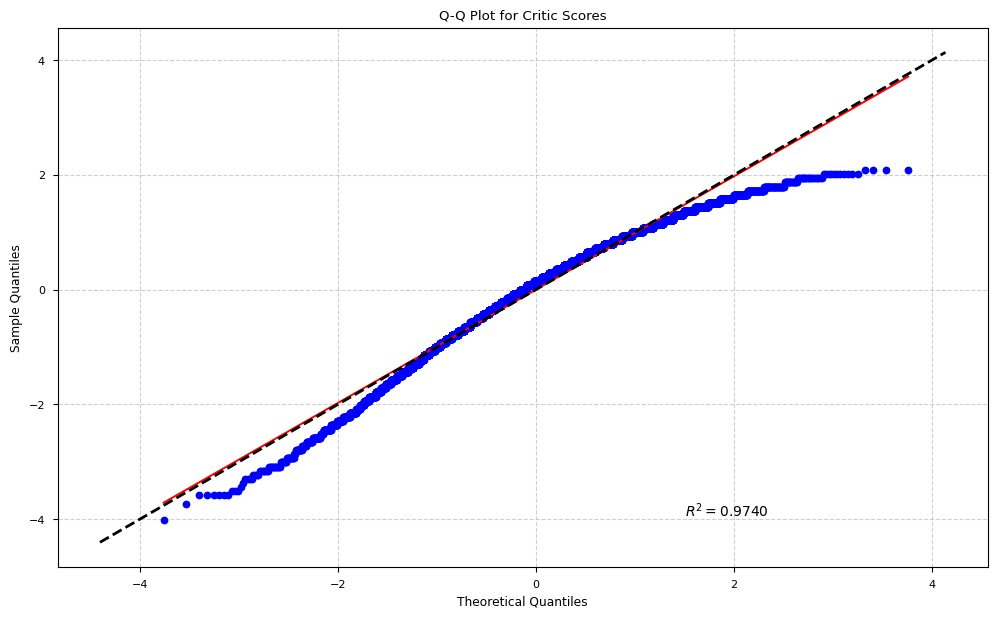

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [26]:
# In order to statistically test if the distribution is normal, we can use a Q-Q plot. Basically, a Q-Q plot compares the quantiles of our sample data against the quantiles of a theoretical normal distribution.
# If the points in the Q-Q plot fall approximately along a straight line, it suggests that the data is normally distributed. Deviations from this line indicate departures from normality.
# Similar to a linear regression, if the points deviate significantly from the line, it suggests that the data does not follow a normal distribution.
# The x-values represent the theoretical quantiles from a standard normal distribution, while the y-values represent the sample quantiles from our dataset.
# The x-values are in std. deviations units, and correspond to: -3σ, -2σ, -1σ, 0, 1σ, 2σ, 3σ = 0.13%, 2.28%, 15.87%, 50%, 84.13%, 97.72%, 99.87%

plt.figure(figsize=(12, 7))
scores = df['Critic_Score']
z_scores = (scores - scores.mean()) / scores.std() # Standardize the data
probplot(z_scores, dist="norm", plot=plt, rvalue=True) # Create the Q-Q plot 
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
lims = [min(x_min, y_min), max(x_max, y_max)]
plt.plot(lims, lims, 'k--', lw=2)
plt.title('Q-Q Plot for Critic Scores')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

display(Latex("In the Q-Q plot above, we can see that the points deviate from the straight line, especially in the $x < -2 \sigma$ and $x > 2 \sigma$ regions. The black line is the $y = x$ line, representing perfect normality. The red line is a linear regression line fitted to the points. The Q-Q plot deepens the insights from the histogram, confirming that the distribution has a heavier left tail and a lighter right tail than a theoretical normal distribution. The deviation from normality is much more pronounced in the right tail. This is because the high concentration of scores in the 70-90 range \"uses up\" the probability that, in a perfect normal distribution, would be allocated to even higher scores (95-100), resulting in a very \"light\" or \"short\" right tail. The left tail, while less dense, contains slightly more extreme low scores than a normal distribution would predict, which is consistent with the left-skew observed in the histogram."))
display(Latex("For many practical applications that are robust to moderate deviations from normality, it can be considered \"approximately normal\", keeping in mind the specific nature of its left-skew and light right tail."))

##### **1.2.5 Log-Normal Distribution**

The log-normal distribution can be thought of as a distribution that models variables that are **positively skewed** and cannot take on negative values. It is used to model phenomena where the logarithm of the variable follows a normal distribution. This is particularly useful in scenarios where the data spans several orders of magnitude, such as income levels, stock prices, or certain biological measurements. Mathematically, if a random variable $X$ is log-normally distributed, then $Y = \ln(X)$, follows a **normal distribution** with mean $\mu$ and standard deviation $\sigma$. The probability density function of a log-normal distribution is given by the formula:

##### $$\boxed{f(x) = \frac{1}{x \sigma \sqrt{2\pi}} e^{-\frac{(\ln(x) - \mu)^2}{2\sigma^2}}, \quad x > 0}$$

**Example:** The Global_Sales variable appears to be right-skewed, suggesting it might follow a Log-Normal Distribution. Verify this assumption both visually and statistically. First, plot a histogram with a Kernel Density Estimate (KDE) to visually inspect the distribution's shape. Does applying a logarithmic transformation to Global_Sales result in a distribution that is approximately normal? Verify this hypothesis visually with a histogram and formally with a Q-Q plot.

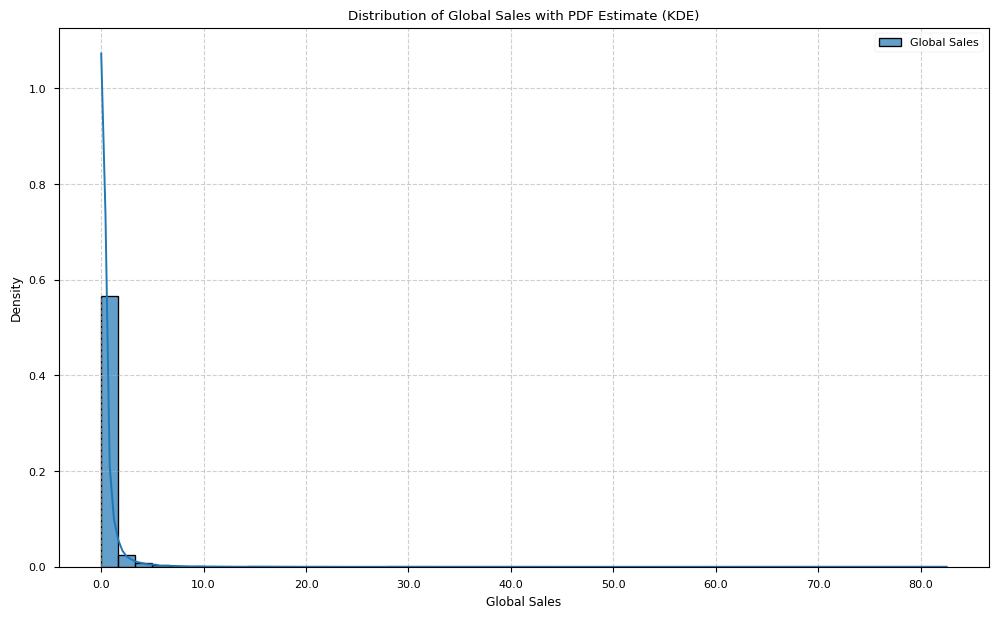

<IPython.core.display.Latex object>

In [27]:
# First let's plot the histogram and the PDF estimate (KDE) again to visualize the distribution.
df = pd.read_csv('../data/Video_Games_Sales.csv')
df['Global_Sales'] = df['Global_Sales'].astype(float)
df = df[['Global_Sales']].dropna()
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='Global_Sales', bins=50, kde=True, linewidth=0.95, alpha=0.7, stat='density', label='Global Sales') # kde=True adds the Kernel Density Estimate (KDE) line
plt.title('Distribution of Global Sales with PDF Estimate (KDE)')
plt.xlabel('Global Sales')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(ticks=np.arange(0, df['Global_Sales'].max(), 10), labels=[f'{x}' for x in np.arange(0, df['Global_Sales'].max(), 10)])
plt.legend()
plt.show()

display(Latex("The distribution of Global Sales is highly right-skewed, with a long tail extending towards higher sales values. " \
"Most games have relatively low sales, while a few games achieve very high sales figures. This kind of distribution is common in sales data, " \
"where a small number of products often account for a large proportion of total sales."))

<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_13317/4072172204.py:33: SyntaxWarning: invalid escape sequence '\s'
  " almost a straight horizontal line in the $y = -2\sigma$ quantile, that comes from the high density that we can observe in the first bin of the histogram." \


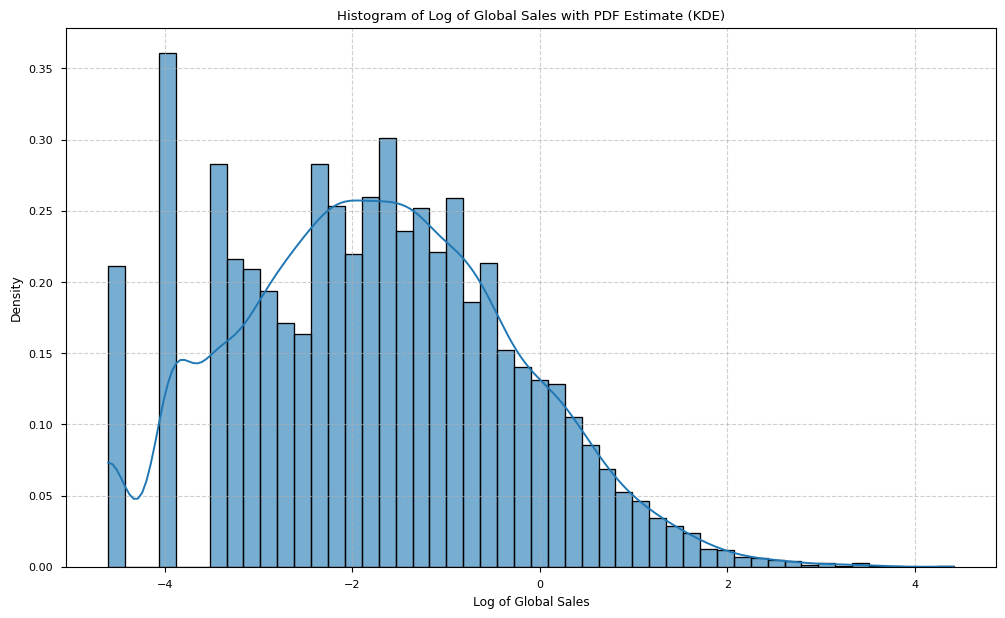

<IPython.core.display.Latex object>

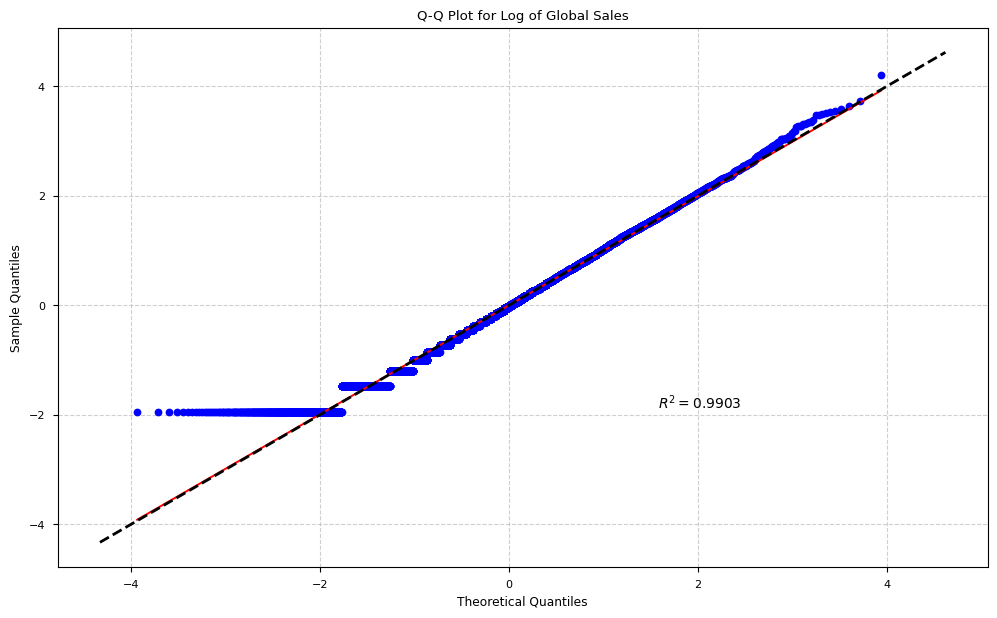

<IPython.core.display.Latex object>

In [28]:
# Now let's create a Q-Q plot to statistically assess the normality of the Global Sales distribution.

plt.figure(figsize=(12, 7))
sales = np.log(df['Global_Sales'])
z_sales = (sales - sales.mean()) / sales.std() # Standardize the data
normalplot = sns.histplot(sales, kde=True, stat='density', bins=50, alpha=0.6, linewidth=0.95) # Plot the histogram of log-transformed sales
plt.title('Histogram of Log of Global Sales with PDF Estimate (KDE)')
plt.xlabel('Log of Global Sales')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

display(Latex("The histogram of the log-transformed Global Sales shows a distribution that is more symmetric and bell-shaped compared to " \
"the original sales data. This transformation helps to reduce the right-skewness and makes the distribution more closely resemble a normal distribution." \
" However, there are still some deviations from normality, particularly in the left tail. This comes from the fact that too many games have very low sales," \
" which can create a heavier left tail even after log transformation."))

# Now we can create the Q-Q plot for the log-transformed Global Sales data.
plt.figure(figsize=(12, 7))
probplot_sales = probplot(z_sales, dist="norm", plot=plt, rvalue=True) # Create the Q-Q plot
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
lims = [min(x_min, y_min), max(x_max, y_max)]
plt.plot(lims, lims, 'k--', lw=2)
plt.title('Q-Q Plot for Log of Global Sales')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

display(Latex("In the Q-Q plot for the log-transformed Global Sales, we observe that the points almost align along the straight line, which suggests " \
"that the log-transformed sales data is approximately normally distributed. However, the previously mentioned deviations (left tail) appears very pronounced," \
" almost a straight horizontal line in the $y = -2\sigma$ quantile, that comes from the high density that we can observe in the first bin of the histogram." \
" Overall, the log transformation has significantly improved the normality of the sales data compared to the original distribution."))

##### **1.2.6 t-Student Distribution**

The t-Student distribution is a set of distributions that are similar to the normal distribution but have heavier tails. It is used to model situations where the sample size is **small**, and the **population** standard deviation is **unknown**. The t-distribution is characterized by its **degrees of freedom (df)**, which is typically equal to the sample size (n) minus one $(n - 1)$. As the degrees of freedom increase, the t-distribution approaches the normal distribution. Mathematically, the probability density function of a t-distribution with df degrees of freedom is given by the formula:

$$\boxed{
f(t) = \frac{\Gamma\left(\frac{n}{2}\right)}{\sqrt{(n - 1) \pi} \Gamma\left(\frac{n-1}{2}\right)} \left(1 + \frac{t^2}{n-1}\right)^{-\frac{n}{2}}
}
$$

where:
- $t$ is the t-score ($t = \frac{(X - \bar{X})}{(s / \sqrt{n})}$).
- $n$ is the sample size.
- $\Gamma$ is the gamma function.


- The mean ($\mu$) and the variance ($\sigma^2$) are given by:

    - $\boxed{\mu = 0, (df > 1)}$ 
    
    - $\boxed{\sigma^2 = \frac{n}{n - 2}, (df > 2)}$


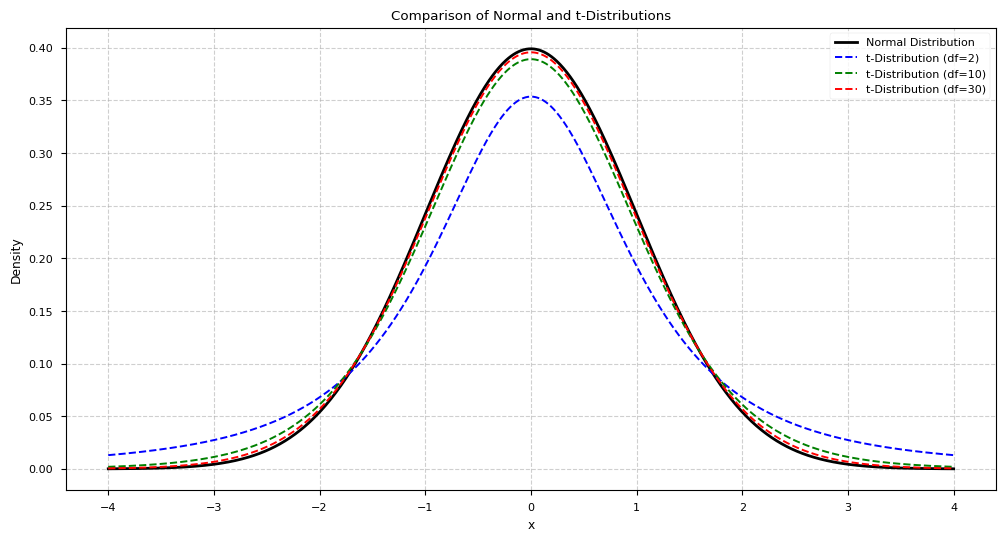

<IPython.core.display.Latex object>

In [29]:
# "The Student's t-distribution is a key tool for inference, especially with smaller samples. How does its shape compare to the Standard Normal Distribution,
#  and how does it change as the sample size (and thus, the degrees of freedom) increases? Let's visualize this relationship."

x = np.linspace(-4, 4, 1000)
normal_pdf = norm.pdf(x, 0, 1)
t_pdf_2 = stats.t.pdf(x, df=2)
t_pdf_10 = stats.t.pdf(x, df=10)
t_pdf_30 = stats.t.pdf(x, df=30)

plt.figure(figsize=(12, 6))
plt.plot(x, normal_pdf, label='Normal Distribution', color='black', linewidth=2)
plt.plot(x, t_pdf_2, label='t-Distribution (df=2)', color='blue', linestyle='--')
plt.plot(x, t_pdf_10, label='t-Distribution (df=10)', color='green', linestyle='--')
plt.plot(x, t_pdf_30, label='t-Distribution (df=30)', color='red', linestyle='--')
plt.title('Comparison of Normal and t-Distributions')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

display(Latex("The t-distribution with low degrees of freedom (df=2) has much heavier tails compared to the normal distribution, indicating a higher probability of extreme values. " \
"As the degrees of freedom increase (df=10 and df=30), the t-distributions tails become lighter and the distribution approaches the shape of the normal distribution. " \
"By df=30, the t-distribution is very close to the normal distribution, with only slight differences in the tails. This illustrates how the t-distribution converges to the normal distribution as the sample size increases."))


### **2. Sampling & The Central Limit Theorem (CLT)**


#### **2.1 The Theory of Estimation**

##### In statistics, we often want to learn about a **population** (the entire group we're interested in). For almost all real-world applications, it's usually impractical or impossible to collect data from every member of a population, so we rely on **samples** (smaller subsets of the population) to make inferences about the whole. To make valid inferences from a sample to a population, we need to ensure that our sample is representative of the population. This means that the sample should be selected in a way that gives every member of the population an equal chance of being included. There are various sampling methods we can use to achieve this, including random sampling, stratified sampling, and cluster sampling. Once we have a representative sample, we can use **sample statistics** (like the sample mean) to estimate **population parameters** (like the population mean). 

#### **2.2 The Central Limit Theorem (CLT)**

##### The **Central Limit Theorem** is a cornerstone of statistics. It states that if you take sufficiently large random samples from a population, the distribution of the **means** of these samples will be approximately **normally distributed**, regardless of the original population's distribution. This is powerful because it allows us to make inferences about a population's mean **without knowing** its *true* distribution. In other words, even if the population is not normally distributed, the sampling distribution of the sample mean will be normal if the sample size is large enough. Mathematically:

##### $$\boxed{ \bar{X} \sim N\left(\mu, \frac{\sigma^2}{n}\right)}$$


##### such that as the sample size $n$ increases, the sample mean $\bar{X}$ converges to the population mean $\mu$. This is often expressed as:

##### $$\boxed{ lim_{n \to \infty} \bar{X} = \mu}$$ 

##### where $\bar{X}$ is the sample mean, $\mu$ is the population mean, and $n$ is the sample size.


* ##### **Standard Error (SE)** : The standard error measures the **variability of the sample mean** as an estimate of the population mean. It is different from the standard deviation, which measures the variability of individual data points in a dataset. There are **two ways to compute SE**, depending on what information you have:

1. **Theoretical SE** (if population standard deviation $\sigma$ is known):

    #### $ \boxed{SE = \frac{\sigma}{\sqrt{n}}} $

    ##### where:

* $n$ is the **sample size**,
* $\sigma$ is the **population standard deviation**.

2. **Practical SE** (when only the sample is available, $\sigma$ unknown):

    #### $ \boxed{SE = \frac{s}{\sqrt{n}}} $

    ##### where:

* $n$ is the **sample size**,
* $s$ is the **sample standard deviation**.

- **Example:** We previously established that the Global_Sales variable follows a Log-Normal distribution (i.e., it is heavily right-skewed). The Central Limit Theorem, however, claims that the distribution of sample means taken from this population should be approximately normal. Can we verify this powerful theorem in practice? Furthermore, can we confirm that the mean of these sample means approximates the true population mean, and that their standard deviation matches the theoretical Standard Error?

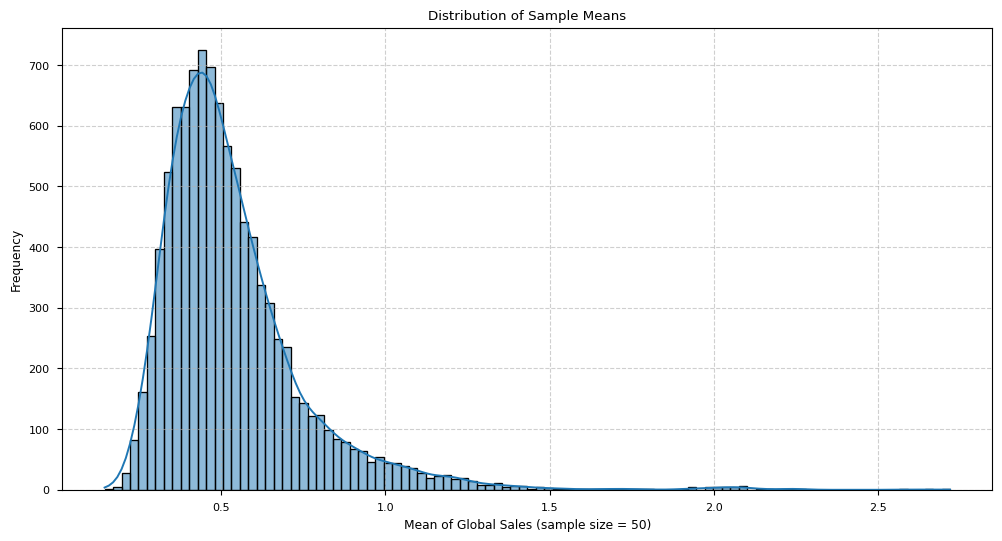

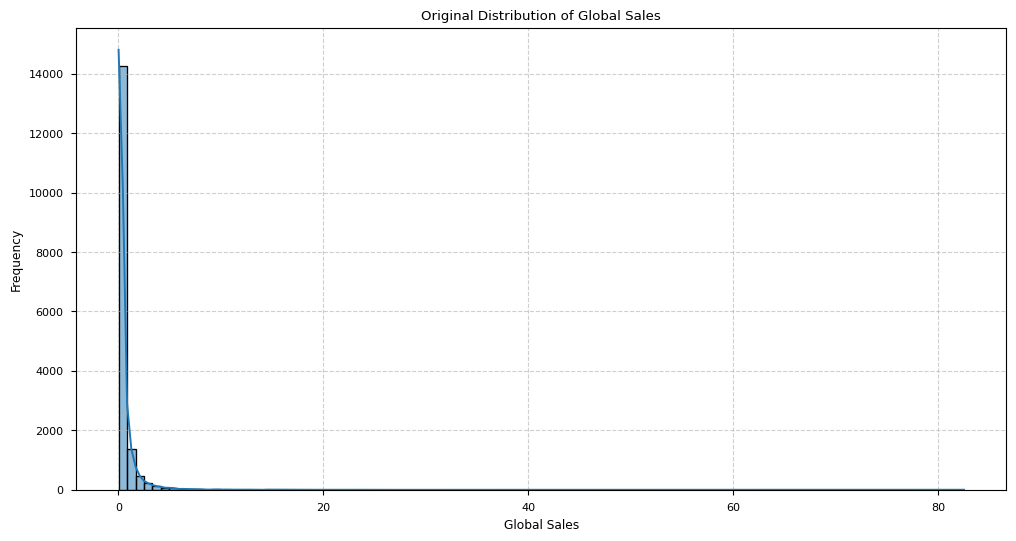

The mean of the entire dataset is: 0.5335426759973684
The mean of the sample means is: 0.5377329399999999


In [30]:
# Step 1: We'll repeatedly (10,000 times) take a random sample of 50 sales values from the 'Global_Sales' column.
# Step 2: For each sample, we'll calculate its mean and store it in a list.
# Step 3: We'll then plot the distribution of these sample means to visualize the CLT in action.

df = pd.read_csv('../data/Video_Games_Sales.csv')
df['Global_Sales'] = df['Global_Sales'].astype(float)
df = df[['Global_Sales']].dropna()
means_sampled = []  # List to store the mean of each sample
sample_size = 50     # Number of values in each sample
n_samples = 10000    # Number of samples to draw

for i in range(n_samples):
    sample_n = df['Global_Sales'].sample(sample_size, random_state=i) # The function sample() randomly selects 'sample_size' values from 'Global_Sales'. It 
    #receives as parameter the desired sample size. We also set a random_state=i, which ensures that every person running this code gets the same results.
    mean_n = sample_n.mean() # Calculate the mean of this sample
    means_sampled.append(mean_n) # Store the mean in our list
    

# Plot the distribution of the sample means
plt.figure(figsize=(12, 6))
sns.histplot(means_sampled, bins=100, kde=True, linewidth=0.95)
plt.title('Distribution of Sample Means')
plt.xlabel('Mean of Global Sales (sample size = 50)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot the original data distribution for comparison
plt.figure(figsize=(12, 6))
sns.histplot(df['Global_Sales'], bins=100, kde=True, linewidth=0.95)
plt.title('Original Distribution of Global Sales')
plt.xlabel('Global Sales')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Compare the mean of the original data to the mean of the sample means
print("The mean of the entire dataset is:", df['Global_Sales'].mean())
print("The mean of the sample means is:", np.mean(means_sampled))

In [31]:
# The theoretical SE is:
s = np.std(df['Global_Sales'], ddof=1) #ddof is the Delta Degrees of Freedom. The divisor used in calculations is N - ddof, where N represents the number of elements.
SE_theoretical = s / np.sqrt(sample_size)

# The simulated SE is:
SE_sim = np.std(means_sampled, ddof=1)

print("Theoretical SE:", SE_theoretical)
print("Simulated SE:", SE_sim)

# 💡 Note: In simulations (like repeatedly sampling and computing means), the standard deviation of the **sample means** itself is already an estimate of SE, 
# so no further division by $\sqrt{n}$ is needed. 
# Observation: When calculating the standard deviation $s$, $n$ is the number of entries minus 1 ($n-1 = 16718$). 
# To calculate the standard error (SE) for a sample of size 50, we divide by $\sqrt{50}$. The denominators are different because they measure different things:
#  s → variability of individual data points.
#  SE → variability of the sample mean for a sample of size 50



Theoretical SE: 0.2189110847049554
Simulated SE: 0.22501359152414208


---

## **Experimentation & Hypothesis Testing**

#### The **goal** of this section is to apply a formal, scientific framework to make decisions and validate assumptions using data. We will move from describing and estimating to actively testing claims by structuring our analysis into three key parts.

- **Inference Fundamentals:** We will begin by defining the core concepts of inference and learning how to create a range of plausible values for a population parameter using **Confidence Intervals**.

- **Hypothesis Testing:** Next, we will formalize the process of testing claims by defining the **null and alternative hypotheses**, understanding **p-values**, and accounting for potential **Type I and Type II errors**.

- **Statistical Tests in Practice:** Finally, we will apply common statistical tests like the **t-test**, **ANOVA**, and **Chi-Square test** to compare means and proportions, allowing us to answer specific questions about differences between various groups in our data.

### **1.1 The Foundations of Statistical Inference**

Statistical inference is the process of drawing conclusions about a population based on a sample. It relies on the principles of probability and the behavior of sampling distributions. In order to further explore this topic, we will start by some key concepts.

#### **1.1.1 Definitions**

- **Population**: The entire group that you want to draw conclusions about.

- **Sample**: A subset of the population that is used to represent the whole.

- **Parameter**: A value of interest that describes a characteristic of the population (e.g., population mean $\mu$, population proportion $p$).

- **Point-Estimate $(\hat{p}$ or $\hat{\theta})$**: A parameter value drawn from a sample that serves as a best guess for the true population parameter. For example, the sample mean ($\bar{x}$) is a point estimate of the population mean ($\mu$).

- **Error**: The difference between the parameter and the point estimate. It mostly occurs due to *sampling errors* (how much an estimate will vary from sample to sample) and *bias* (systematic tendency to over or under-estimate the true population parameter).

#### **1.1.2 Confidence Intervals (CIs)**

Every point estimate has some degree of uncertainty associated with it. A **confidence interval (CI)** provides a *range* of values within which we expect the true population parameter to fall. They describe **only** population parameters, not individual observations or point estimates. When the distribution of $(\hat{p}) \approx N(\mu, \sigma)$, a confidence interval can mathematically expressed as:

##### $$ \boxed{ \hat{p} \pm z^{*} \cdot SE} $$

where:

- $\hat{p}$ is the **point estimate** (e.g., sample mean $\bar{x}$ or sample proportion $\hat{p}$).

- $z^{*}$ is the desired **confidence level** corresponding to the desired level of confidence (**in $\sigma$ units**).

- $SE$ is the **standard error** of the point estimate.

- The product $z^{*} \cdot SE$ is called the **margin of error (ME)**, which quantifies the uncertainty around the point estimate.

The confidence level indicates the proportion of times that the confidence interval would contain the true population parameter if we were to take many samples and construct a confidence interval from each sample. Common $z^{*}$ values for different confidence levels are:

- 90% confidence level: $z^{*} \approx 1.645$
- 95% confidence level: $z^{*} \approx 1.960$
- 99% confidence level: $z^{*} \approx 2.576$
 
- **Example:** We can calculate the average Critic_Score from our sample of games, but how certain are we about this estimate? Calculate and interpret the 95% confidence interval for the true mean Critic_Score of *all* video games.

In [32]:
df = pd.read_csv('../data/Video_Games_Sales.csv')
df['Critic_Score'] = df['Critic_Score'].astype(float)
df = df[['Critic_Score']].dropna()

# Step 1: Calculate the sample mean (x̄) and sample error (SE):
x_bar = df['Critic_Score'].mean()
s = df['Critic_Score'].std(ddof=1) # Sample standard deviation
n = len(df) # Sample size
SE = s / np.sqrt(n) # Standard Error
dff = n - 1 # Degrees of freedom

# Step 2: Determine the critical t-value for a 95% confidence level:
confidence_level = 1.960
m_error = confidence_level*SE
display(Latex(fr"For a {0.95*100:.0f}\% confidence level, the confidence interval, manually calculated, is given by: {x_bar:.2f} $\pm$ {m_error:.2f}."))

# Now let's verify this result using a built-in function from the scipy.stats. The t.interval function computes the confidence interval for a t-distribution.
# It takes the confidence level, degrees of freedom, sample mean, and standard error as inputs.
ci = stats.t.interval(0.95, df=dff, loc=x_bar, scale=SE) 
display(Latex(fr"The 95\% confidence interval calculated using a t-distribution is: ({ci[0]:.2f}, {ci[1]:.2f})."))

display(Latex("Note that our manual calculation used the z-score of 1.96, a common approximation from the Normal distribution for 95% confidence." \
" The scipy.stats.t.interval function uses the more precise t-distribution, which accounts for the uncertainty of using a sample standard deviation. " \
"With our large sample size, the results are nearly identical, confirming the validity of both approaches in this case."))

display(Latex("The confidence interval means that we are 95% confident that the true population mean of Critic Scores lies within this interval. " \
"This does not imply that 95% of individual game scores fall within this range, but rather that if we were to take many samples and compute a confidence " \
"interval from each, approximately 95% of those intervals would contain the true population mean. " \
"Therefore, the average Critic Score for *all* video games is likely between 68 and 70."))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### **2.1 Hypothesis Testing**

#### **2.1.1 Hypothesis Fundamentals**

- **Null Hypothesis ($H_0$)**: The null hypothesis is a logical conclusion that express the notion that nothing special happened and any observed effect is due to random chance. It serves as the default skeptical assumption/perspective that we seek to test against.

- **Alternative Hypothesis ($H_A$)**: The alternative hypothesis is the statement that contradicts the null hypothesis. Its a new or stronger perspective that requires **more evidence** to support it.

  As discussed before, hypothesis testing is based on rejecting or failing to reject $H_0$. Therefore, it **does not** prove the alternative hypothesis to be true, but rather provides evidence against the null hypothesis. For example, if we fail to reject $H_0$, it **does not** mean that $H_0$ is true, just that we do not have enough evidence to support $H_A$. Because we are always working with samples, there is inherent variability, and we can never be $100\%$ certain about our conclusions, so we need to account for the possibility of making errors. The two types of errors in hypothesis testing are:

- **Type I Error ($\alpha$)**: Rejecting $H_0$ when it is actually true.

- **Type II Error ($\beta$)**: Failing to reject the $H_0$ when $H_A$ is true. 

$$
\textbf{TEST CONCLUSION} \\[4pt]
\begin{array}{c|c|c|c}
\hline
 &  & \textbf{Do not reject } H_0 & \textbf{Reject } H_0 \text{ in favor of } H_A \\[4pt]
\hline
\textbf{TRUTH} & H_0 \text{ true} & \text{OK} & \text{Type I Error} \\[4pt]
\hline
\textbf{TRUTH} & H_A \text{ true} & \text{Type II Error} & \text{OK} \\
\hline
\end{array}$$



  In order to control the probability errors and quantify the strength of evidence against $H_0$, we use two key concepts:


- **Significance Level ($\alpha$)**: It is the threshold we set for **rejecting** the null hypothesis. It tells us how often the data lead us to **incorrectly** reject $H_0$ *if* $H_0$ is **true**. Common choices for $\alpha$ are $0.05$, $0.01$, and $0.001$. A **smaller** $\alpha$ means we require **stronger evidence** to reject $H_0$. A confidence level of $95\%$ corresponds to a significance level of $\alpha = 0.05$.

- **P-Value**: The p-value is a tool to quantify the **strength** of evidence against $H_0$ in favor of $H_A$. It tells us the probability of observing a result that is equal or more extreme than we've seen on the data, **assuming** that **$H_0$ is true**. It is calculated as the cumulative distribution function (CDF) of the test statistic under the null hypothesis. Given our p-value, we can extract a conclusion by comparing it to our significance level $\alpha$:

    - If $p \leq \alpha$, we **reject** $H_0$ (the result is statistically significant).
    - If $p > \alpha$, we **fail to reject** $H_0$ (the result is not statistically significant).

  **NOTE:** Tests can be one-sided or two-sided, depending on the nature of the alternative hypothesis. A **one-sided** test is used when we are interested in deviations in only one direction (e.g., testing if a mean is greater than a certain value). A two-sided test is used when we are interested in deviations in both directions (e.g., testing if a mean is different from a certain value, either higher or lower). Regardless of the condition that you choose for analysis, it must be defined **before** looking at the data.


- **Example:** A marketing team claims that games on the 'PS4' platform are, on average, more critically acclaimed than games on the 'Xbox One' platform. We want to test this specific claim. Formulate the null and alternative hypotheses for this scenario. Is this a one-tailed or two-tailed test? Finally, describe what Type I and Type II errors would represent in this context.

  Note that we want to know if $\mu_{PS4} > \mu_{Xbox}$, where $\mu$ is the average rate score. So, we can define as null hypothesis having an average PS4 score being smaller or equal to the average Xbox score: $H_0$ $\longrightarrow$ $\mu_{PS4} \leq \mu_{Xbox}$; and as alternative hypothesis, the average PS4 score being higher: $H_A$ $\longrightarrow$ $\mu_{PS4} > \mu_{Xbox}$. Since we're interested in the case where $\mu_{PS4} > \mu_{Xbox}$, this test is one-tailed, and we can look it through two different perspectives (when analysing the data) that tell the same thing: either $\mu_{PS4} > \mu_{Xbox}$ or $\mu_{Xbox} < \mu_{PS4}$. A Type I Error in this case would be claiming that the PS4 platform has an advantage in relation to Xbox in terms of critical success, $\mu_{PS4} > \mu_{Xbox}$ , when in reality it doesn't. The Type II error would be failing to identify that there is an advantage, $\mu_{PS4} \leq \mu_{Xbox}$, concluding that there is no difference in the critics score between them or that the Xbox platfomr has a higher average sore. 

### **2.2 Statistical Tests**

Statistical tests are formal procedures that allow us to make decisions about population parameters based on sample data. They help us determine whether the observed differences or relationships in our data are **statistically significant** or if they could have occurred by random chance. The **choice** of statistical test depends on several factors, including the type of data (numerical or categorical), the number of groups being compared, and the specific hypotheses being tested.

#### **2.2.1 Tests for Numerical Data**

Statistical tests for numerical data are used to compare means, medians, or other statistics between groups. Common tests include the t-test, ANOVA, and Mann-Whitney U test.

##### **2.2.1.1 Comparing Two Independent Means: The Independent t-Test**

The independent t-test is used to compare the **means** of **two** independent groups to determine if there is a statistically significant difference between them. It is appropriate when the following conditions are met:

- **Independence:** The two groups being compared must be *independent of each other*. This means that the observations in one group should **not** influence or be related to the observations in the other group.

- **Normality:** The data in each group should be **$\approx N(\mu, \sigma^2)$**. This can be assessed using visual methods (e.g., Q-Q plots). However, the t-test is fairly robust to violations of normality, especially with **larger sample sizes** (n \geq 30).

- **Homogeneity of Variance:** The variances of the two groups should be **approximately equal**. If this assumption is violated, a variation of the t-test called [Welch's t-test]() can be used.

The test statistic is calculated using the formula:

##### $$ \boxed{ t = \frac{\bar{X_1} - \bar{X_2}}{\sqrt{\frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}}} } $$

where:

- $\bar{X_1}$ and $\bar{X_2}$ are the sample **means** of the two groups.

- $\sigma_1^{2}$ and $\sigma_2^{2}$ are the sample **variances** of the two groups.

- $n_1$ and $n_2$ are the sample **sizes** of the two groups.

- $df = n_1 + n_2 - 2$ is the **degree of freedom**.


The value of the t-statistic is then compared to a critical value from the **t-distribution table** based on the **chosen significance level ($\alpha$)** and the **degrees of freedom ($df$)**. Alternatively, we can calculate the p-value associated with the t-statistic and compare it to $\alpha$ to make a decision about rejecting or failing to reject the null hypothesis.

**NOTE:** The t-Test can be applied to both **one-tailed** and **two-tailed** hypotheses. In the first case, the signal is only in one direction (e.g., testing if one mean is greater than the other). In the second case, we are interested in deviations in both directions (e.g., testing if the means are different, either higher or lower), so $\bar{X_1} - \bar{X_2}$ and $\bar{X_2} - \bar{X_1}$ leave the same conclusion.

- **Example:** We want to test the marketing team's claim that games on the 'PS4' platform are, on average, more critically acclaimed than games on the 'Xbox One' platform. Using a significance level of $\alpha = 0.05$, perform an independent t-test to evaluate this claim. Based on the results, what conclusion can we draw regarding the null hypothesis?

<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_13317/3488044138.py:31: SyntaxWarning: invalid escape sequence '\m'
  "Furthermore, both samples have a large number of observations ($n > 30$), with shapes almost identical, suggesting that the underlying $\mu$ and $\sigma$ are very similar." ))


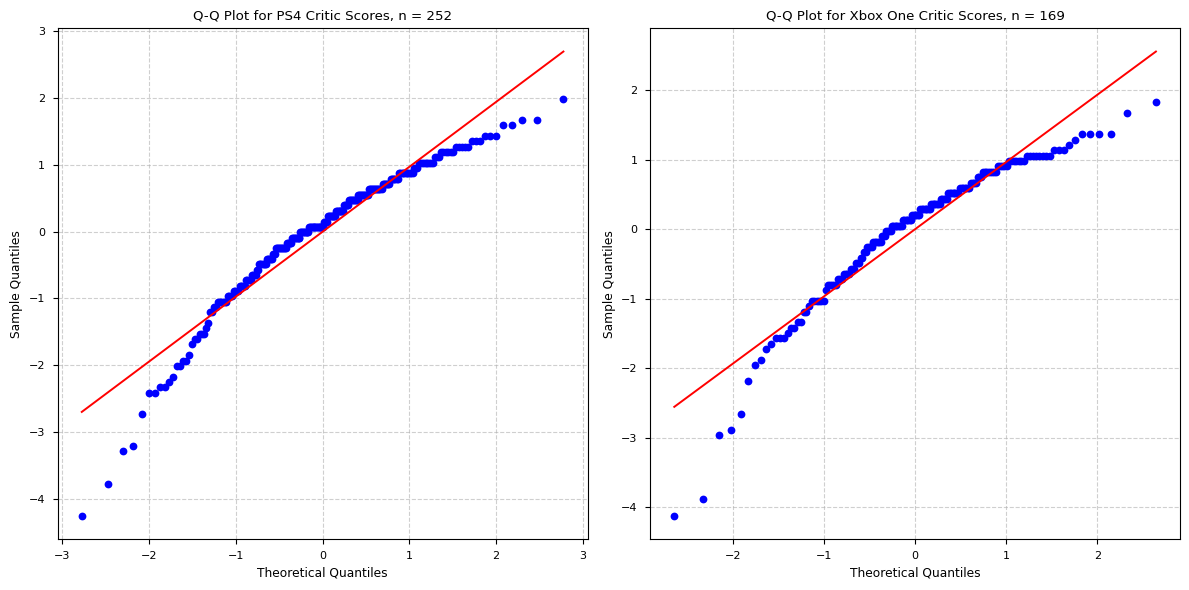

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [33]:
df = pd.read_csv('../data/Video_Games_Sales.csv')
df = df[['Platform', 'Critic_Score']].dropna()
df_PS4 = df[df['Platform'] == 'PS4']
df_Xbox = df[df['Platform'] == 'XOne']
df_PS4 = df_PS4.drop(columns=['Platform'])
df_Xbox = df_Xbox.drop(columns=['Platform'])

#Standardize the data
z_PS4 = (df_PS4 - df_PS4.mean()) / df_PS4.std()
z_Xbox = (df_Xbox - df_Xbox.mean()) / df_Xbox.std()


# Step 1: Check normality assumption with Q-Q plots
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
prob_ps4 = probplot((z_PS4['Critic_Score'] - z_PS4['Critic_Score'].mean()) / z_PS4['Critic_Score'].std(), dist="norm", plot=plt)
plt.title('Q-Q Plot for PS4 Critic Scores, n = {}'.format(len(z_PS4)))
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
prob_xbox = probplot((z_Xbox['Critic_Score'] - z_Xbox['Critic_Score'].mean()) / z_Xbox['Critic_Score'].std(), dist="norm", plot=plt)
plt.title('Q-Q Plot for Xbox One Critic Scores, n = {}'.format(len(z_Xbox)))
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

display(Latex("Both Q-Q plots show that the points approximately follow the straight line, indicating that the distributions of Critic Scores for both PS4 and Xbox One are approximately normal. " \
              "Furthermore, both samples have a large number of observations ($n > 30$), with shapes almost identical, suggesting that the underlying $\mu$ and $\sigma$ are very similar." ))

# Step 2: Our null hypothesis is the same as before: H0: μ1 < = μ2 (the mean Critic Scores for PS4 is smaller or equal to the mean Critic Scores for Xbox One).
# Our alternative hypothesis is: H1: μ1 > μ2 (the mean Critic Scores for PS4 is greater than the mean Critic Scores for Xbox One).
# We will use a significance level of α = 0.05.
# We will assume equal variance based on the Q-Q plots results.

alpha = 0.05
t_stat, p_value = stats.ttest_ind(df_PS4, df_Xbox, equal_var=True, alternative='greater')

if p_value < alpha:
    display(Latex(fr"The t-statistic is {t_stat[0]:.2f} and the p-value is {p_value[0]:.2f}. Since the p-value is less than the significance level of {alpha}, we reject the null hypothesis. Therefore, there is enough evidence to conclude that the mean Critic Score for PS4 is greater than that for Xbox One with 95% confidence."))

else:
    display(Latex(fr"The t-statistic is {t_stat[0]:.2f} and the p-value is {p_value[0]:.2f}. As we can see, since the p-value is greater than the significance level of {alpha}, we have failed to reject the null hypothesis. Therefore, there isn't enough evidence to conclude that the mean Critic Score for PS4 is greater than that for Xbox One with 95% confidence. In fact, our findings demonstrate the opposite of the alternative hypothesis since the mean Critic Score for PS4 is actually lower than that for Xbox One, as shown by the value of t being $\approx {t_stat[0]:.1f}$."))

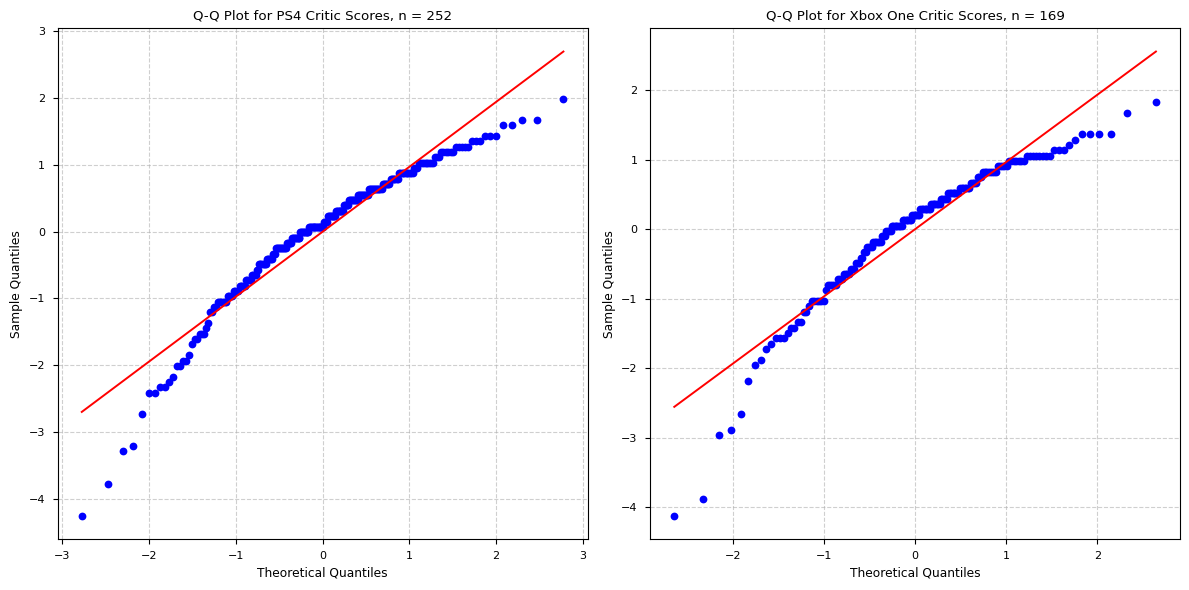

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [34]:
df = pd.read_csv('../data/Video_Games_Sales.csv')
df = df[['Platform', 'Critic_Score']].dropna()
df_PS4 = df[df['Platform'] == 'PS4']
df_Xbox = df[df['Platform'] == 'XOne']
df_PS4 = df_PS4.drop(columns=['Platform'])
df_Xbox = df_Xbox.drop(columns=['Platform'])

#Standardize the data
z_PS4 = (df_PS4 - df_PS4.mean()) / df_PS4.std()
z_Xbox = (df_Xbox - df_Xbox.mean()) / df_Xbox.std()


# Step 1: Check normality assumption with Q-Q plots
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
prob_ps4 = probplot((z_PS4['Critic_Score'] - z_PS4['Critic_Score'].mean()) / z_PS4['Critic_Score'].std(), dist="norm", plot=plt)
plt.title('Q-Q Plot for PS4 Critic Scores, n = {}'.format(len(z_PS4)))
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
prob_xbox = probplot((z_Xbox['Critic_Score'] - z_Xbox['Critic_Score'].mean()) / z_Xbox['Critic_Score'].std(), dist="norm", plot=plt)
plt.title('Q-Q Plot for Xbox One Critic Scores, n = {}'.format(len(z_Xbox)))
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

display(Latex(r"Both Q-Q plots show that the points approximately follow the straight line, indicating that the distributions of Critic Scores for both PS4 and Xbox One are approximately normal. "
              r"Furthermore, both samples have a large number of observations ($n > 30$), with shapes almost identical, suggesting that the underlying $\mu$ and $\sigma$ are very similar."))
 
# Step 2: Our null hypothesis is the same as before: H0: μ1 < = μ2 (the mean Critic Scores for PS4 is smaller or equal to the mean Critic Scores for Xbox One).
# Our alternative hypothesis is: H1: μ1 > μ2 (the mean Critic Scores for PS4 is greater than the mean Critic Scores for Xbox One).
# We will use a significance level of α = 0.05.
# We will assume equal variance based on the Q-Q plots results.

alpha = 0.05
t_stat, p_value = stats.ttest_ind(df_PS4, df_Xbox, equal_var=True, alternative='greater')

if p_value < alpha:
    display(Latex(fr"The t-statistic is {t_stat[0]:.2f} and the p-value is {p_value[0]:.2f}. Since the p-value is less than the significance level of {alpha}, we reject the null hypothesis. Therefore, there is enough evidence to conclude that the mean Critic Score for PS4 is greater than that for Xbox One with 95% confidence."))

else:
    display(Latex(fr"The t-statistic is {t_stat[0]:.2f} and the p-value is {p_value[0]:.2f}. As we can see, since the p-value is greater than the significance level of {alpha}, we have failed to reject the null hypothesis. Therefore, there isn't enough evidence to conclude that the mean Critic Score for PS4 is greater than that for Xbox One with 95% confidence. In fact, our findings demonstrate the opposite of the alternative hypothesis since the mean Critic Score for PS4 is actually lower than that for Xbox One, as shown by the value of t being $\approx {t_stat[0]:.1f}$."))

##### **2.2.1.2 Assumption Check: Homogeneity of Variances (Levene's Test & Welch's t-test)**

One of the key assumptions of the standard Student's t-test is that both groups have approximately equal variances(homogeneity of variance). If this assumption is violated, the standard t-test can become unreliable. In such cases, we need to change our approach to ensure valid results. Therefore, before performing the t-test, we should check for homogeneity of variances. For this purpose, we can use **Levene's Test**.

#####   **Levene's Test:**

Levene's Test is a statistical test used to assess the equality of variances between two or more groups. The conditions for applying Levene's Test are:

**1.** The dependent variable should be continuous.

**2.** The independent variable should consist of two or more categorical groups.

**3.** The observations should be independent of each other.

Unlike other tests, Levene's already has a predefined null and alternative hypothesis:

- **Null Hypothesis $(H_0)$:** The variances are equal across groups.

- **Alternative Hypothesis $(H_1)$:** The variances are not equal across groups.

The test statistic is calculated using the formula:

   $$ \boxed{ W = \frac{(N - k)}{(k - 1)} \cdot \frac{\sum_{i=1}^{k} n_i (Z_{i\cdot} - Z_{\cdot\cdot})^2}{\sum_{i=1}^{k} \sum_{j=1}^{n_i} (Z_{ij} - Z_{i\cdot})^2} } $$

where: 

- $N$ is the total number of observations across all groups.

- $k$ is the number of groups.

- $n_i$ is the number of observations in group $i$.

- $Z_{ij} = |Y_{ij} - \tilde{Y_i}|$ is the absolute deviation of observation $j$ in group $i$ from the group median $\tilde{Y_i}$.

- $Z_{i\cdot}$ is the mean of the absolute deviations for group $i$.

- $Z_{\cdot\cdot}$ is the overall mean of the absolute deviations across all groups.

If the **p-value** of Levene's test is low (e.g., < 0.05), we reject the null hypothesis and conclude that the variances are different. In this case, we should use **Welch's t-test** instead of the standard t-test in order to compare the means. 


##### **Welch's t-test:**

Welch's t-test is a variation of the standard t-test that is used when the assumption of equal variances is violated. It is more robust to differences in variances and sample sizes between the two groups. The test statistic for Welch's t-test is calculated using the formula:

##### $$ \boxed{ t = \frac{\bar{X_1} - \bar{X_2}}{\sqrt{\frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}}} } $$

where:

- $\bar{X_1}$ and $\bar{X_2}$ are the sample **means** of the two groups.

- $\sigma_1^{2}$ and $\sigma_2^{2}$ are the sample **variances** of the two groups.

- $n_1$ and $n_2$ are the sample **sizes** of the two groups.

- The degrees of freedom ($df$) for Welch's t-test is calculated using the Welch-Satterthwaite formula. It accounts for the unequal variances and sample sizes of the two groups. Mathematically, it is given by:

   $ \boxed{ df = \frac{\left(\frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}\right)^2}{\frac{\left(\frac{\sigma_1^2}{n_1}\right)^2}{n_1 - 1} + \frac{\left(\frac{\sigma_2^2}{n_2}\right)^2}{n_2 - 1}} } $


The value of the t-statistic is then compared to a critical value from the **t-distribution table** based on the **chosen significance level ($\alpha$)** and the **degrees of freedom ($df$)**. Alternatively, we can calculate the **p-value** associated with the t-statistic and compare it to $\alpha$ to make a decision about rejecting or failing to reject the null hypothesis, just like in the standard t-test. In practice, it is always **safer** to use Welch's t-test, as it does not assume equal variances between the two groups and does not require any additional steps to check for homogeneity of variances. In the case of equal variances, Welch's t-test will yield results that are very similar to the standard t-test.


- **Example:** In our previous t-test comparing PS4 and Xbox One critic scores, we assumed the variances of the two groups were equal. First, let's formally test this assumption using Levene's test. Then, based on the result, let's perform the appropriate version of the t-test (Student's or Welch's) to confirm our findings.

In [35]:
# First let's do the Levene's test to check the homogeneity of variances assumption.

stat_leve, p_levene = levene(df_PS4['Critic_Score'], df_Xbox['Critic_Score'])
alpha = 0.05

if p_levene < alpha:

    print("Levene's test is significant, therefore we reject the null hypothesis with respect to homogeneity of variances with 95% confidence.")

else:
    
    print("Levene's test is not significant, therefore we fail to reject the null hypothesis with respect to homogeneity of variances with 95% confidence.")

# Now let's perform the Welch's t-test, which does not assume equal variances, and compare the results with the previous t-test.

t_stat_welch, p_value_welch = stats.ttest_ind(df_PS4['Critic_Score'], df_Xbox['Critic_Score'], equal_var=False, alternative='greater')

if p_value_welch < alpha:

    display(Latex(fr"The Welch's t-statistic is {t_stat_welch:.2f} and the p-value is {p_value_welch:.2f}. Since the p-value is less than the significance level of {alpha}, we reject the null hypothesis. Therefore, there is enough evidence to conclude that the mean Critic Score for PS4 is greater than that for Xbox One with 95% confidence."))

else:

    display(Latex(fr"The Welch's t-statistic is {t_stat_welch:.2f} and the p-value is {p_value_welch:.2f}. As we can see, since the p-value is greater than the significance level of {alpha}, we have failed to reject the null hypothesis. Therefore, there isn't enough evidence to conclude that the mean Critic Score for PS4 is greater than that for Xbox One with 95% confidence. In fact, our findings demonstrate the opposite of the alternative hypothesis since the mean Critic Score for PS4 is actually lower than that for Xbox One, as shown by the value of t being $\approx {t_stat_welch:.1f}$."))

if np.isclose(t_stat, t_stat_welch, atol=0.01):

    display(Latex("The results from both the Student's t-test (assuming equal variances) and Welch's t-test (not assuming equal variances) are very similar, as we would expect given the similar sample variances. "))

Levene's test is not significant, therefore we fail to reject the null hypothesis with respect to homogeneity of variances with 95% confidence.


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

##### **2.2.1.3 The Non-Parametric Alternative: Mann-Whitney U Test**

The Mann-Whitney U is used to compare the distributions of two independent groups. It is particularly useful when the assumptions of the t-test (normality and homogeneity of variances) are violated. The conditions for applying the Mann-Whitney U test are: 

**1.** The dependent variable should be ordinal or continuous (can be ordered).

**2.** The two groups being compared should be independent.

It is a very powerful statistical tool because it's **non-parametric**, meaning it does not assume a specific distribution for the data. It doesn't require normality, making it suitable for **skewed distributions** or when dealing with **outliers**. The Mann-Whitney U test compares if the values in one group tend to be larger or smaller than those in the other group. 

The null and alternative hypotheses for the Mann-Whitney U test are:

- **Null hypothesis (H0):** The distributions of the two groups are equal.

- **Alternative hypothesis (H1):** The distributions of the two groups are not equal.

The test adopts the concept of **ranks**. First, we combine the data from both groups and sort them from lowest to highest. Then, we assign ranks to each value, with the smallest value receiving a rank of 1, the next smallest a rank of 2, and so on. If there are tied values, we assign them the average of the ranks they would have received if they were not tied. After ranking the data, we separate the ranks back into their respective groups. The test statistic returns U, the number of times a value from one group precedes a value from the other group in the ranked list. The U statistic is calculated using the formula:

$$ \boxed{ U_1 = n_1 n_2 + \frac{n_1 (n_1 + 1)}{2} - R_1 } $$

where:

- $n_1$ and $n_2$ are the sample sizes of the two groups.

- $R_1$ is the sum of the ranks for group 1.

Given the $U_1$ value, we can calculate the p-value associated with it and compare it to our significance level $\alpha$ to make a decision about rejecting or failing to reject the null hypothesis. If  $N = $n_1 + n_2$ is$ large enough (typically $n_1$ and $n_2$ both greater than 20), the U statistic can be approximated by a normal distribution, allowing us to calculate a z-score and corresponding p-value.

The mean and standard deviation of U (when $N$ is large and *$H_0$* is **true**) are given by:

- $ \mu = \frac{n_1 n_2}{2} $

- $ \sigma = \sqrt{\frac{n_1 n_2 (n_1 + n_2 + 1)}{12}} $


**NOTE:** The test is very usefull to compare the **medians** of two groups, but it actually tests for differences in the overall distributions. If the distributions of the two groups have the same shape, then a significant result from the Mann-Whitney U test can be interpreted as a difference in medians. However, if the shapes of the distributions are different, a significant result indicates a difference in distributions, but it does not specifically point to a difference in medians. Mann-Whitney U test can also be applied to both **one-tailed** and **two-tailed** hypotheses. In the first case, the signal is only in one direction (e.g., testing if one distribution tends to have larger values than the other). In the second case, we are interested in deviations in both directions (e.g., testing if the distributions are different, either higher or lower), so $U_1$ and $U_2$ leave the same conclusion. 

- **Example:** We previously established that *Global_Sales* follows a highly skewed distribution, violating the normality assumption of the t-test. Let's use the appropriate non-parametric test, the Mann-Whitney U test, to determine if there is a statistically significant difference in the median global sales between games released on the 'Wii' and 'DS' platforms. Use a significance level of $\alpha = 0.05$.

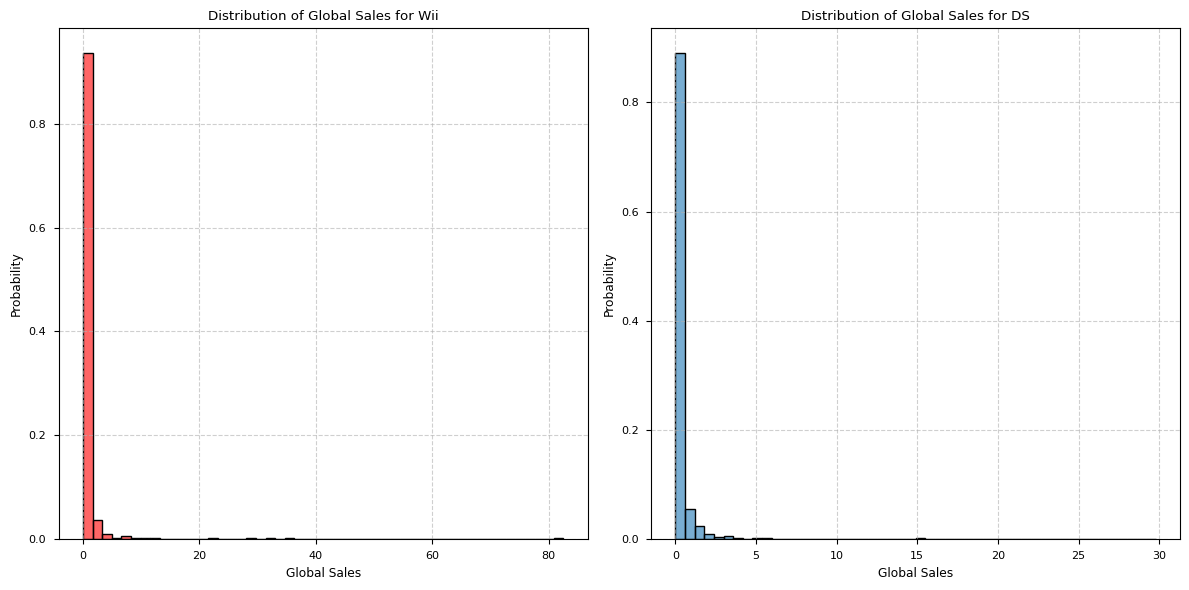

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [36]:
# First let's define the hypotheses:
# Null hypothesis (H0): The median of sales for Wii is equal to the median of sales for DS.
# Alternative hypothesis (H1): The median of sales for Wii is different from the median of sales for DS.

# Let's load the data and filter for the two platforms.
df = pd.read_csv('../data/Video_Games_Sales.csv')
df = df[['Platform', 'Global_Sales']].dropna()
df_Wii = df[df['Platform'] == 'Wii']
df_DS = df[df['Platform'] == 'DS']
df_Wii = df_Wii.drop(columns=['Platform'])
df_DS = df_DS.drop(columns=['Platform'])

# Let's visualize the distributions of sales for both platforms using histograms.
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_Wii['Global_Sales'], bins=50, color='red', linewidth=1, alpha=0.6, stat='probability')
plt.title('Distribution of Global Sales for Wii')
plt.xlabel('Global Sales')
plt.ylabel('Probability')
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
sns.histplot(df_DS['Global_Sales'], bins=50, linewidth=1, alpha=0.6, stat='probability')
plt.title('Distribution of Global Sales for DS')
plt.xlabel('Global Sales')
plt.ylabel('Probability')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

display(Latex("The histograms show that both distributions are right-skewed, with a long tail extending towards higher sales values. " \
"Most games on both platforms have relatively low sales, while a few games achieve very high sales figures. Therefore we have a non-normal "
"and asymmetric distribution."))

# Since the distributions are non-normal and asymmetric, we will use the Mann-Whitney U test

U_stat, U_p_value = mannwhitneyu(df_Wii['Global_Sales'], df_DS['Global_Sales']) # By default, this function performs a two-sided test.

alpha = 0.05

prob_U = U_stat / (len(df_Wii) * len(df_DS)) # This gives us the probability that a randomly selected game from Wii has higher sales than a randomly selected game from DS.

if U_p_value < alpha:

    display(Latex(fr"The Mann-Whitney U statistic is {U_stat:.2f} and the p-value is {U_p_value:.2f}. Since the p-value is less than the significance level of {alpha}, we reject the null hypothesis. Therefore, there is enough evidence to conclude that the median Global Sales for Wii is different from that for DS with 95% confidence. Also, the probability that a randomly selected game from Wii has higher sales than a randomly selected game from DS is approximately {prob_U*100:.2f}\%."))

else:

    display(Latex(fr"The Mann-Whitney U statistic is {U_stat:.2f} and the p-value is {U_p_value:.2f}. As we can see, since the p-value is greater than the significance level of {alpha}, we have failed to reject the null hypothesis. Therefore, there isn't enough evidence to conclude that the median Global Sales for Wii is different from that for DS with 95% confidence. Also, the probability that a randomly selected game from Wii has higher sales than a randomly selected game from DS is approximately {prob_U*100:.2f}\%."))

##### **2.2.1.4 Comparing More Than Two Means: ANOVA**

Analysis of Variance (ANOVA) is a statistical method used to compare the means of **three or more** independent groups to determine if there are statistically significant differences among them. If we were to perform multiple t-tests to compare more than two groups, we would increase the risk of committing a **Type I error** (false positive) by inflating the overall significance level. For example, if we have three groups (A, B, and C) and we perform t-tests for A vs. B, A vs. C, and B vs. C, the probability of making at least one Type I error across these tests is higher than the significance level set for each individual test. For clarity, if we set $\alpha = 0.05$ for each t-test, the overall probability of making at least one Type I error across the three tests is $(1 - \alpha)^3$. This is known as the **multiple comparisons problem**. ANOVA addresses this issue by testing all group means simultaneously, maintaining the overall significance level and reducing the risk of Type I errors. Therefore, it can be thought as an extension of the t-test. ANOVA is appropriate when the following conditions are met:

- **Independence:** The groups being compared must be *independent of each other*. 

- **Normality:** The data in each group should be approximately normally distributed. 

- **Homogeneity of Variances:** The variances of the groups should be approximately equal. 

The null and alternative hypotheses for ANOVA are:

- **Null Hypothesis $(H_0)$:** All group means are equal ($\mu_1 = \mu_2 = \mu_3 = ... = \mu_k$).

- **Alternative Hypothesis $(H_A)$:** At least one group mean is different from the others.

The key idea behind ANOVA is to compare the variability **between** groups to the variability **within** groups. If the *variance* **between** groups ($\sigma^2_{btw}$) is significantly larger than the *variance* **within** groups ($\sigma^2_{wtn}$), it suggests that at least one group mean is different. The test statistic for ANOVA is called the F-statistic, which is calculated using the formula:

$$ \boxed{F = \frac{\sigma^2_{btw}}{\sigma^2_{wtn}} = \frac{\frac{1}{k-1} \sum_{i=1}^{k} n_i (\bar{X}_i - \bar{X})^2}{\frac{1}{N-k} \sum_{i=1}^{k} \sum_{j=1}^{n_i} (X_{ij} - \bar{X}_i)^2}} $$

Where:

- **$k$** is the number of groups.

- **$N$** is the total number of observations across all groups.

- **$n_i$** is the number of observations in group $i$.

- **$\bar{X}_i$** is the mean of group $i$.

- **$\bar{X}$** is the overall mean of all observations.

- **$X_{ij}$** is the j-th observation in group $i$.



A larger F-statistic indicates a greater disparity between the group means relative to the variability within the groups, providing evidence against the null hypothesis. If $F \approx 1$, it suggests that the group means are similar, and we fail to reject the null hypothesis, meaning that the differences are due to random chance. If $F >> 1$, it indicates that at least one group mean is significantly different from the others, leading us to reject the null hypothesis. The value of the F-statistic is then compared to a critical value from the **F-distribution table** based on the **chosen significance level ($\alpha$)** and the **degrees of freedom** for both the numerator (between groups) and denominator (within groups). Alternatively, we can calculate the p-value associated with the F-statistic and compare it to $\alpha$ to make a decision about rejecting or failing to reject the null hypothesis.

**NOTE**: ANOVA tells us if there is a significant difference among the group means, but it **DOES NOT** specify *which* groups are different. If we find a significant result, we may need to perform post-hoc tests (e.g., Tukey's HSD) to identify the specific group differences. The Tukey HSD test returns a confidence interval for the difference between each pair of group means. If the confidence interval for a pair of means is higher than the HSD value, we can conclude that there is a significant difference between those two groups. But for simplicity, we will not cover it in detail in this material.


##### **Welch's ANOVA**

Welch's ANOVA is a variation of the standard ANOVA that is used when the assumption of equal variances is **violated**. Resembling Welch's t-test, it is more robust to differences in variances and sample sizes between the groups. Instead of grouping the data and calculating means and variances, Welch's ANOVA uses a weighted approach that gives more weight to groups with smaller variances. This helps to mitigate the impact of unequal variances on the test results. The conditions for applying Welch's ANOVA are the same as for standard ANOVA, except that the homogeneity of variances assumption is relaxed. The null and alternative hypotheses for Welch's ANOVA are also the same. The test statistic for Welch's ANOVA is calculated using the formula:

$ \boxed{ F^* = \frac{\sum_{i=1}^{k} \frac{\bar{X}_i^2}{\sigma_i^2 / n_i}}{\sum_{i=1}^{k} \frac{1}{\sigma_i^2 / n_i}} - \frac{\left(\sum_{i=1}^{k} \frac{\bar{X}_i}{\sigma_i^2 / n_i}\right)^2}{\left(\sum_{i=1}^{k} \frac{1}{\sigma_i^2 / n_i}\right)^2} } $

where:

- **$k$** is the number of groups.

- **$\bar{X}_i$** is the mean of group $i$.

- **$\sigma_i^2$** is the variance of group $i$.

- **$n_i$** is the sample size of group $i$.

The degrees of freedom for Welch's ANOVA are calculated using the Welch-Satterthwaite equation, which accounts for the unequal variances and sample sizes of the groups. The value of the F-statistic is then compared to a critical value from the **F-distribution table** based on the **chosen significance level ($\alpha$)** and the **degrees of freedom** for both the numerator (between groups) and denominator (within groups). Alternatively, we can calculate the p-value associated with the F-statistic and compare it to $\alpha$ to make a decision about rejecting or failing to reject the null hypothesis, just like in standard ANOVA. In practice, it is always **safer** to use Welch's ANOVA, as it does not assume equal variances between the groups and does not require any additional steps to check for homogeneity of variances. In the case of equal variances, Welch's ANOVA will yield results that are very similar to standard ANOVA.

In [37]:
# Scipy does not have a builtin function to calculate Welch's ANOVA, but we can use define it.

import numpy as np
from scipy import stats

def welch_anova(*groups):
    

    groups = [np.asarray(g).astype(float) for g in groups if len(g) > 0]
    groups = [g[~np.isnan(g)] for g in groups]

    k = len(groups)
    if k < 2:
        raise ValueError("Welch's ANOVA requires at least two groups.")

    ni = np.array([len(g) for g in groups], dtype=float)
    mi = np.array([np.mean(g) for g in groups], dtype=float)
    si2 = np.array([np.var(g, ddof=1) for g in groups], dtype=float)

    wi = ni / si2
    mean_weighted = np.sum(wi * mi) / np.sum(wi)

    numerator = np.sum(wi * (mi - mean_weighted) ** 2) / (k - 1)
    denominator = 1 + (2 * (k - 2) / (k ** 2 - 1)) * np.sum((1 / (ni - 1)) * (1 - (wi / np.sum(wi))) ** 2)
    df_num = k - 1
    df_den = 1 / (3 * denominator)

    F = numerator / denominator
    p = 1 - stats.f.cdf(F, df_num, df_den)

    return F, p


/tmp/ipykernel_13317/2328540211.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genre', y='Critic_Score', data=df[df['Genre'].isin(['Racing', 'Platform', 'Misc'])], palette='rainbow')


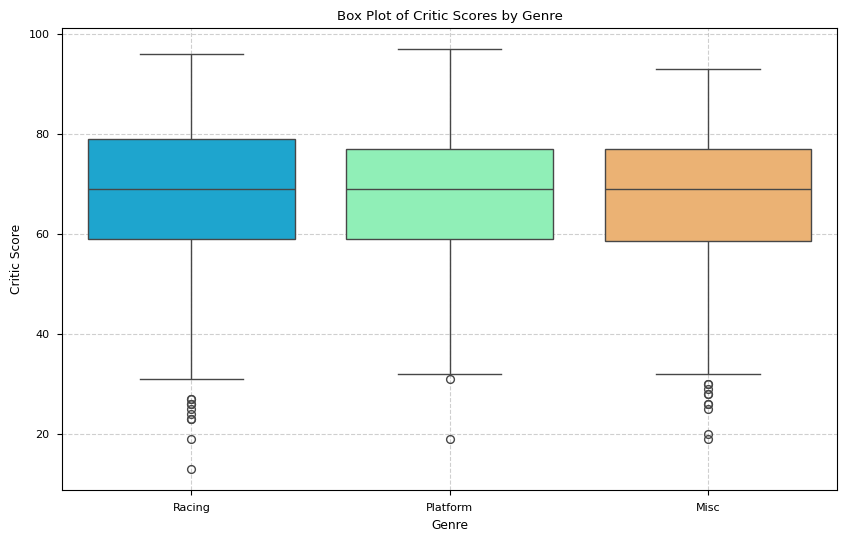

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [38]:
# - **Example:** We want to know if there is a statistically significant difference in the average *Critic_Score* among different game genres. Let's use ANOVA to compare the mean critic scores for the *'Racing'*, *'Platform'*, and *'Misc'* genres. Use a significance level of $\alpha = 0.05$.

# First we define our hypotheses:
# Null hypothesis (H0): There is no difference in the average critic scores across different game genres.
# Alternative hypothesis (H1): At least one game genre has a different average critic score.

# Let's load the data and filter for the relevant columns.
df = pd.read_csv('../data/Video_Games_Sales.csv')
df = df[['Genre', 'Critic_Score']].dropna()
df_racing = df[df['Genre'] == 'Racing']['Critic_Score']
df_platform = df[df['Genre'] == 'Platform']['Critic_Score']
df_misc = df[df['Genre'] == 'Misc']['Critic_Score']

# Let's visualize the distributions of critic scores for the three genres using box plots.
plt.figure(figsize=(10, 6))
sns.boxplot(x='Genre', y='Critic_Score', data=df[df['Genre'].isin(['Racing', 'Platform', 'Misc'])], palette='rainbow')
plt.title('Box Plot of Critic Scores by Genre')
plt.xlabel('Genre')
plt.ylabel('Critic Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

display(Latex("The box plots show that the distributions of critic scores for the three genres have some differences in their spreads. " \
              "Their median is almost the same, however, the Misc genre has a lower variability. The outliers are present in all three  " \
              "genres, with Racing having the most extreme outliers. "))

# Let's check the homogeneity of variances assumption using Levene's test.
stat2_levene, p2_levene = levene(df_racing, df_platform, df_misc)
alpha = 0.05
if p2_levene < alpha:
   
    display(Latex("Levene's test is significant, therefore we reject the null hypothesis with respect to homogeneity of variances with 95% confidence."))

    # Now let's perform the Welch's ANOVA test, since the Levene's test indicated that the variances are different.

    F_stat_welch, p_value_welch = welch_anova(df_racing, df_platform, df_misc) 

    if p_value_welch < alpha:
        
        display(Latex(fr"The Welch's ANOVA F-statistic is {F_stat_welch:.2f} and the p-value is {p_value_welch:.2f}. Since the p-value is less than" \
                       f"the significance level of {alpha}, we reject the null hypothesis. Therefore, there is enough evidence to conclude that at " \
                       f"least one game genre has a different average critic score with 95% confidence."))

    else:

        display(Latex(fr"The Welch's ANOVA F-statistic is {F_stat_welch:.2f} and the p-value is {p_value_welch:.2f}. As we can see, since the p-value "
                      f"is greater than the significance level of {alpha}, we have failed to reject the null hypothesis. Therefore, there isn't enough "
                      f"evidence to conclude that at least one game genre has a different average critic score with 95% confidence."))

else:
    display(Latex("Levene's test is not significant, we failed to reject the null hypothesis with respect to homogeneity of variances with 95% confidence." \
    " Therefore, we can assume that the variances across the groups are equal and proceed with the standard ANOVA."))

    # Now let's perform the standard ANOVA test.
    F_stat_std, p_value_std = f_oneway(df_racing, df_platform, df_misc)

    if p_value_std < alpha:

        display(Latex(fr"The standard ANOVA F-statistic is {F_stat_std:.2f} and the p-value is {p_value_std:.2f}. Since the p-value is less than the significance" \
                      f" level of {alpha}, we reject the null hypothesis. Therefore, there is enough evidence to conclude that at least one game genre has " \
                      f"a different average critic score with 95% confidence."))

    else:

        display(Latex(fr"The standard ANOVA F-statistic is {F_stat_std:.2f} and the p-value is {p_value_std:.2f}. As we can see, since the p-value is greater than" \
                       f" the significance level of {alpha}, we have failed to reject the null hypothesis. Therefore, there isn't enough evidence to conclude" \
                       f" that at least one game genre has a different average critic score with 95% confidence."))





##### **The Two-Way ANOVA** 

The Two-Way ANOVA is an extension of the one-way ANOVA that allows us to examine the effects of **two independent categorical variables** (factors) on a continuous dependent variable. It also enables us to investigate whether there is an **interaction effect** between the two factors, meaning that the effect of one factor on the dependent variable may depend on the level of the other factor. For example, we want to analyze how a fertilizer type (Factor A) and light exposure (Factor B) affect plant growth (dependent variable). The Two-Way ANOVA can help us determine if different fertilizer types (A and B) and light exposure levels have significant effects on plant growth, and if the effect of fertilizer type varies depending on the light exposure level. The one-way ANOVA can only analyze the effect of one factor at a time, while the Two-Way ANOVA can analyze the effects of two factors simultaneously, providing a more comprehensive understanding of the data. The conditions for applying Two-Way ANOVA are similar to those of One-Way ANOVA, i.e, independence, normality, and homogeneity of variances. 

The null and alternative hypotheses for Two-Way ANOVA are:

- **Null Hypothesis $(H_0)$:**
  - There is no main effect of Factor A on the dependent variable ($\mu_{A1} = \mu_{A2} = ... = \mu_{Ak}$).
  - There is no main effect of Factor B on the dependent variable ($\mu_{B1} = \mu_{B2} = ... = \mu_{Bm}$).
  - There is no interaction effect between Factor A and Factor B on the dependent variable.

- **Alternative Hypothesis $(H_A)$:**
  - At least one level of Factor A has a different mean from the others.
  - At least one level of Factor B has a different mean from the others.
  - There is an interaction effect between Factor A and Factor B on the dependent variable.

The test statistic for Two-Way ANOVA is also an F-statistic, and can be thought of as the ratio of within-group variance to between-group variance, but it is calculated separately for each factor and the interaction effect. The formulas for the F-statistics are as follows:

- **Total Variance:** Measures each observation's deviation from the **overall** mean.

  $ \boxed{\sigma^2_{total} = \sigma^2_{btw} + \sigma^2_{wtn} = \sigma^2_{A} + \sigma^2_{B} + \sigma^2_{AB} + \sigma^2_{wtn} = \sum_{i=1}^{a} \sum_{j=1}^{b} \sum_{k=1}^{n} (X_{ijk} - \bar{X})^2} $


- **Main Effect of Factor A:** Measures each $\mu_{A_i}$ 's deviation from the **overall** mean.

  $ \boxed{\sigma^2_{A} = \sum_{i=1}^{a} n b (\bar{X}_{A_i} - \bar{X})^2} $

- **Main Effect of Factor B:** Measures each $\mu_{B_j}$ 's deviation from the **overall** mean.

  $ \boxed{\sigma^2_{B} = \sum_{j=1}^{b} n a (\bar{X}_{B_j} - \bar{X})^2} $

- **Variance within Groups:** Measures each observation's deviation from its **group** mean.

  $ \boxed{\sigma^2_{wtn} = \sum_{i=1}^{a} \sum_{j=1}^{b} \sum_{k=1}^{n} (X_{ijk} - \bar{X}_{A_i B_j})^2} $

- **Interaction Effect (A x B):** Measures how the effect of one factor depends on the level of the other factor.

  $ \boxed{\sigma^2_{AB} = \sigma^2_{total} - \sigma^2_{A} - \sigma^2_{B} - \sigma^2_{wtn}} $

Where:

- **$a$** is the number of levels in Factor A.
- **$b$** is the number of levels in Factor B.
- **$n$** is the number of observations per cell (combination of Factor A and Factor B).
- **$X_{ijk}$** is the k-th observation in the cell defined by level i of Factor A and level j of Factor B.
- **$\bar{X}$** is the overall mean of all observations.
- **$\bar{X}_{A_i}$** is the mean of level i of Factor A.
- **$\bar{X}_{B_j}$** is the mean of level j of Factor B.
- **$\bar{X}_{A_i B_j}$** is the mean of the cell defined by level i of Factor A and level j of Factor B.

Each F-statistic is calculated as the ratio of the variance component to the within-group variance:

- **F-statistic for Factor A:**
 $ F_A = \frac{\sigma^2_{A}}{\sigma^2_{wtn}} $

- **F-statistic for Factor B:** 
$ F_B = \frac{\sigma^2_{B}}{\sigma^2_{wtn}} $

- **F-statistic for Interaction (A x B):** 
$ F_{AB} = \frac{\sigma^2_{AB}}{\sigma^2_{wtn}} $

The **p-value** for each F-statistic is then compared to the significance level $\alpha$ to determine whether to reject or fail to reject the null hypotheses for each factor and the interaction effect, just like in the one-way ANOVA.

- **Example:** "We want to understand how game *Genre* and *Platform_Family* simultaneously influence the average *Critic_Score*. We will perform a Two-Way ANOVA to test three hypotheses: **1.** Is there a main effect of *Genre?* **2.** Is there a main effect of *Platform_Family*? **3.** Is there an interaction effect between *Genre* and *Platform_Family*? Use a significance level of $\alpha = 0.05$. Consider Nintendo, PlayStation, and Xbox as the main platform families, and Action, Sports, and Shooter as the main genres."

In [39]:
# First let's define the hypotheses:
# Null hypothesis (H0): There is no difference in the average critic scores across for different game genres.
# Alternative hypothesis (H1): At least one game genre has a different average critic score.

# Null hypothesis (H0): There is no difference in the average critic scores across for different family platforms. 
# Alternative hypothesis (H1): At least one family platform has a different average critic score.

# Null hypothesis (H0): There is no interaction between the two factors (Genre and Platform) in the average critic scores.
# Alternative hypothesis (H1): There is an interaction between the two factors (Genre and Platform) in the average critic scores.

df = pd.read_csv('../data/Video_Games_Sales.csv')
df = df[['Genre', 'Platform', 'Critic_Score']].dropna()
df['Platform'].unique()

# Now let's group the platforms into family groups. We can use .map() function to map each platform to its family group.
platform_map = {
    'PS4': 'PlayStation',
    'PS3': 'PlayStation',
    'PS2': 'PlayStation',
    'PS': 'PlayStation',
    'PSP': 'PlayStation',
    'PSV': 'PlayStation',
    'XOne': 'Xbox',
    'X360': 'Xbox',
    'XB': 'Xbox',
    'Wii': 'Nintendo',
    'WiiU': 'Nintendo',
    'DS': 'Nintendo',
    '3DS': 'Nintendo',
    'GC': 'Nintendo',
}
df['Family_Platform'] = df['Platform'].map(platform_map)
df = df.dropna(subset=['Family_Platform']) # Drop rows where Family_Platform is NaN
df = df[df['Genre'].isin(['Sports', 'Action', 'Shooter'])] # Drop rows everywhere, except for selected genres
df = df.drop(columns=['Platform']) # Drop the original Platform column
display(df)

# Now we will use statsmodels to perform the two-way ANOVA. 

model = ols('Critic_Score ~ C(Genre) + C(Family_Platform) + C(Genre):C(Family_Platform)', data=df).fit() 

anova_table = sm.stats.anova_lm(model, typ=2) 
display(anova_table)

display(Latex("From the ANOVA table, we can see that the interaction term (C(Genre):C(Family_Platform)) has a p-value of $\\approx 0.14$, which is greater than our significance level of 0.05. " \
"Therefore, we fail to reject the null hypothesis and conclude that there is no significant interaction between Genre and Family Platform in terms of average Critic Scores. " \
"This means that the effect of Genre on Critic Scores does not depend on the Family Platform, and vice versa. Analyzing the main effects, we see that both Genre and Family Platform have p-values " \
"less than 0.05, indicating that they each have a significant effect on average Critic Scores independently."))


,Genre,Critic_Score,Family_Platform
0,Sports,76.0,Nintendo
3,Sports,80.0,Nintendo
13,Sports,80.0,Nintendo
15,Sports,80.0,Nintendo
16,Action,97.0,PlayStation
...,...,...,...
16534,Action,51.0,PlayStation
16581,Shooter,40.0,Nintendo
16601,Action,65.0,Xbox
16656,Action,81.0,Nintendo


,sum_sq,df,F,PR(>F)
C(Genre),17915.716152,2.0,44.446367,8.642240e-20
C(Family_Platform),11703.429736,2.0,29.034560,3.113256e-13
C(Genre):C(Family_Platform),1383.421346,4.0,1.716037,1.435066e-01
Residual,710237.849795,3524.0,NaN,NaN


<IPython.core.display.Latex object>

##### **2.2.1.5 The Non-Parametric Alternative: Kruskal-Wallis Test** 

Just as the Mann-Whitney U test is the non-parametric alternative to the t-test, the **Kruskal-Wallis test** is the non-parametric alternative to the *one-way* ANOVA. It is used to determine if there are statistically significant differences between the distributions of three or more independent groups when the data **does not** meet the **normality** assumption of ANOVA. In order to apply the Kruskal-Wallis test, the following conditions must be met:

**1.** The dependent variable should be ordinal or continuous (can be ordered).

**2.** The independent variable should consist of three or more categorical groups.

**3.** The observations should be independent of each other.

The null and alternative hypotheses for the Kruskal-Wallis test are:

- **Null hypothesis (H0):** The distributions of the groups are equal.

- **Alternative hypothesis (H1):** At least one group distribution is different from the others.

The Kruskal-Wallis test, like the Mann-Whitney U test, uses ranks to compare the groups. The principals are similar: we combine the data from all groups, sort them, and assign ranks. After ranking the data, we separate the ranks back into their respective groups. The following step is to calculate the test statistic H, which is given by the formula:

$$ \boxed{ H = \frac{n-1}{12} \sum_{i=1}^{k} n_{i} \frac{\mu_{i}-E_{r}}{\sigma_{i}^2}} $$

where:

- **$n$** is the total number of observations across all groups.

- **$k$** is the number of groups.

- **$\mu_{i}$** is the mean rank for the $i^{th}$ group.

- **$n_i$** is the number of observations in the $i^{th}$ group.

- **$E_r = \frac{n+1}{2}$** is the expected mean rank under the null hypothesis.

- **$\sigma_{i}^2 = \frac{n^2 - 1}{12}$** is the variance of ranks under the null hypothesis.

The H statistic follows a $\chi^2$ distribution with **$k-1$ degrees of freedom**. We can calculate the p-value associated with the H statistic, by calculating the CDF of a $\chi^2$ distribution with same df, and later, compare it to our significance level $\alpha$ to make a decision about rejecting or failing to reject the null hypothesis. Values of H that are significantly large provide evidence against the null hypothesis, suggesting that at least one group distribution is different from the others. Values of H that are close to 0 indicate that the group distributions are similar, leading us to fail to reject the null hypothesis. P-values on the other hand, follow the same logic as before: if the $p \leq \alpha$, we reject the null hypothesis and conclude that at least one group distribution is different from the others. If the $p > \alpha$, we fail to reject the null hypothesis, indicating that there is no significant difference between the group distributions.

**NOTE:** Similar to ANOVA, the Kruskal-Wallis test tells us if there is a significant difference among the group distributions, but it **DOES NOT** specify *which* groups are different. If we find a significant result, we may need to perform post-hoc tests (e.g., Dunn's test) to identify the specific group differences. But for simplicity, we will not cover it in detail in this material. The Kruskal-Wallis test **cannot** be applied to **two independent categorical variables**. For this, we should use the *Scheirer-Ray-Hare* test, which is the non-parametric alternative to the Two-Way ANOVA. However, we will not cover it in this material. The Kruskal-Wallis test is also **robust to outliers** and can be used with small sample sizes, making it a versatile choice for analyzing non-normal data.

- **Example:** Given the non-normal distribution of Global_Sales, we cannot use a standard ANOVA to compare sales across different genres. Use the Kruskal-Wallis test to determine if there is a statistically significant difference in the distribution of global sales among the 'Action', 'Sports', and 'Shooter' genres. Use a significance level of $\alpha = 0.05$.

/tmp/ipykernel_13317/3866217819.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genre', y='Global_Sales', data=df[df['Genre'].isin(['Action', 'Shooter', 'Sports'])], palette='rainbow')


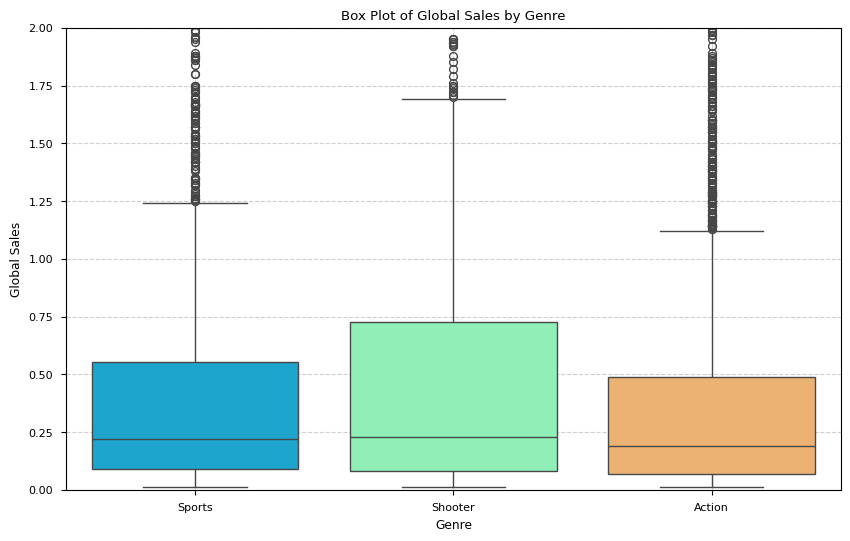

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [40]:
# First we define our hypotheses:
# Null hypothesis (H0): The sales distributions for the three genres are equal.
# Alternative hypothesis (H1): At least one genre has a different sales distribution.

df = pd.read_csv('../data/Video_Games_Sales.csv')
df = df[['Genre', 'Global_Sales']].dropna()
df_action = df[df['Genre'] == 'Action']['Global_Sales']
df_shooter = df[df['Genre'] == 'Shooter']['Global_Sales']
df_sports = df[df['Genre'] == 'Sports']['Global_Sales']

# Let's plot the distributions of sales for the three genres using box plots.
plt.figure(figsize=(10, 6))
sns.boxplot(x='Genre', y='Global_Sales', data=df[df['Genre'].isin(['Action', 'Shooter', 'Sports'])], palette='rainbow')
plt.title('Box Plot of Global Sales by Genre')
plt.xlabel('Genre')
plt.ylabel('Global Sales')
plt.ylim(0, 2) # Limit y-axis to better visualize the distributions
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

display(Latex("The box plots show that the distributions of sales probably have a long tail extending towards higher sales values (many outliers). " \
              "This suggests that while most games have relatively low sales, a few games achieve very high sales figures and therefore " \
              " may not be well-represented by a normal distribution. Hence, we should consider using non-parametric tests like the " \
              "Kruskal-Wallis test to analyze these sales distributions. We should also note that the variances across the groups appear " \
              "to be different, with Shooter having the highest variability and Action the lowest."))

# Let's perform the Kruskal-Wallis H-test for independent samples.

H_stat, p_value_kruskal = kruskal(df_action, df_shooter, df_sports)

alpha = 0.05

if p_value_kruskal < alpha:

    display(Latex(fr"The Kruskal-Wallis H statistic is {H_stat:.2f} and the p-value is {p_value_kruskal}. Since the p-value is less than the significance" \
                   "level of {alpha}, we reject the null hypothesis. Therefore, there is enough evidence to conclude that at least one genre has a different" \
                   " sales distribution with 95% confidence."))

else:

    display(Latex(fr"The Kruskal-Wallis H statistic is {H_stat:.2f} and the p-value is {p_value_kruskal}. As we can see, since the p-value is greater" \
                   f" than the significance level of {alpha}, we have failed to reject the null hypothesis. Therefore, there isn't enough evidence to" \
                   f" conclude that at least one genre has a different sales distribution with 95% confidence."))



#### **2.2.2 Tests for Categorical Data**

So far, our focus has been on numerical data, comparing means, medians and other statistics. However, many important questions involve categorical variables. Categorical data represents distinct groups or categories, such as gender, color, or brand preference. They differ from numerical data, which represents measurable quantities. For example: Is there an association between product category and customer region? Does the choice of platform depend on the game's genre? To answer these questions, we need tests that work with counts and proportions. In this section, we will explore some of the most common statistical tests for categorical data, including the Chi-Square Test of Independence and Z-tests for proportions.

##### **2.2.2.1 The $\chi^2$-Test of Independence**

The Chi-Square Test of Independence is a statistical test used to determine if there is a relationship between two categorical variables. Hence, it provides a way to test the independence of our data. It is appropriate when the following conditions are met:

- **Categorical Variables:** Both variables being analyzed should be categorical (nominal or ordinal).

- **Independence:** The observations should be independent of each other. This means that the occurrence of one observation should not influence the occurrence of another.

- **Expected Frequency:** Each cell in the contingency table should have an expected frequency of at least 5. If this condition is not met, the results of the Chi-Square test may not be reliable.

The null and alternative hypotheses for the Chi-Square Test of Independence are:

- **Null Hypothesis $(H_0)$:** The two categorical variables are independent (no relationship).

- **Alternative Hypothesis $(H_1)$:** The two categorical variables are dependent (there is a relationship).

The test statistic for the Chi-Square Test of Independence is calculated using the formula:

$$ \boxed{ \chi^2 = \sum \frac{(O_i - E_i)^2}{E_i} } $$

where:

- **$O_i$** is the observed frequency for category $i$.

- **$E_i$** is the expected frequency for category $i$, calculated under the assumption that the *null hypothesis* is true.

In order to utilize the Chi-Square Test of Independence, we first need to create a **contingency table** that summarizes the **counts** of observations for each combination of categories from the two variables. For example, if we are analyzing the relationship between *Platform_Family* (e.g., Nintendo, PlayStation, Xbox) and *Genre* (e.g., Action, Sports, Shooter), we would create a table that shows how many games fall into each combination of platform family and genre. 

$$
\textbf{Contingency Table} \\[4pt]
\begin{array}{c|c|c|c|c}
\hline
Genre/Platform &  \textbf{Nintendo } & \textbf{PlayStation} & \textbf{Xbox} & \textbf{Total} \\[4pt]
\hline
\textbf{Action} & n_{A,N} & n_{A,P} & n_{A,X} & n_{A,T} \\[4pt]
\hline
\textbf{Sports} & n_{S,N} & n_{S,P} & n_{S,X} & n_{S,T} \\
\hline
\textbf{Shooter} & n_{SH,N} & n_{SH,P} & n_{SH,X} & n_{SH,T} \\
\hline
\textbf{Total} & n_{T,N} & n_{T,P} & n_{T,X} & N \\
\hline
\end{array}$$

For each cell in the contingency table, we calculate the expected frequency ($E_i$) using the formula:

$ \boxed{ E_{ij} = \frac{(Row\ Total_i) \times (Column\ Total_j)}{Grand\ Total} } $

Where:

- **$Row\ Total_i$** is the total count for row $i$.

- **$Column\ Total_j$** is the total count for column $j$.

- **$Grand\ Total$** is the total count of all observations $N$.

The degrees of freedom ($df$) for the Chi-Square Test of Independence is calculated using the formula:

$ \boxed{ df = (r - 1) \times (c - 1) } $

Where:

- **$r$** is the number of rows in the contingency table.

- **$c$** is the number of columns in the contingency table.

The value of the Chi-Square statistic is then compared to a critical value from the **Chi-Square distribution table** based on the **chosen significance level ($\alpha$)** and the **degrees of freedom ($df$)**. Alternatively, we can calculate the p-value associated with the Chi-Square statistic and compare it to $\alpha$ to make a decision about rejecting or failing to reject the null hypothesis. A larger Chi-Square statistic indicates a greater disparity between the observed and expected frequencies, providing evidence against the null hypothesis. If the p-value is less than or equal to $\alpha$, we reject the null hypothesis and conclude that there is a significant association between the two categorical variables. If the p-value is greater than $\alpha$, we fail to reject the null hypothesis, indicating that there is no significant association between the variables.

Like the previous tests, the Chi-Square Test of Independence does not specify *which* categories are different. If we find a significant result, we may need to perform post-hoc tests to identify the specific category differences. The simplest approach is to look at the standardized **residuals** for each cell in the contingency table. 

The standardized residual for each cell is calculated using the formula:

$ \boxed{ r_{ij} = \frac{O_{ij} - E_{ij}}{\sqrt{E_{ij}}} } $

Where:

- **$O_{ij}$** is the observed frequency for cell $(i,j)$.

- **$E_{ij}$** is the expected frequency for cell $(i,j)$.

The residuals indicate how much each cell's observed frequency deviates from the expected frequency, in expected frequency units. A residual greater than 2 or less than -2 is often considered significant, indicating that the observed frequency is significantly higher or lower than expected under the null hypothesis. It is like a z-score for each cell in the contingency table. This comes from the fact that, under the null hypothesis, the distribution of each cell's count can be approximated by a poisson distribution with mean equal to the expected count. If the expected count is large enough (typically greater than 5), the poisson distribution can be approximated by a normal distribution with mean equal to the expected count and standard deviation equal to the square root of the expected count. Therefore, the standardized residuals follow a standard normal distribution under the null hypothesis and recover the z-score formula.


**NOTE:** It is important to distinguish the Chi-Square Test of Independence from another common test that shares its name: the **Chi-Square Goodness-of-Fit (GoF) Test**. While both use the chi-square statistic, they answer different questions. The Chi-Square Test of Independence assesses whether two categorical variables are related, while the Chi-Square GoF test evaluates whether the distribution of a single categorical variable matches a specified distribution. The GoF test is used when we have one categorical variable and want to see if its observed distribution fits an expected distribution (e.g., uniform, normal, etc.). In contrast, the Test of Independence requires two categorical variables and examines the relationship between them.



- **Example:** Is there a statistically significant association between a game's Genre and its content Rating? For example, are 'Shooter' games more likely to receive an 'M' (Mature) rating than other genres? Let's use the Chi-Square test to investigate. Use a significance level of $\alpha = 0.05$.

Rating,AO,E,E10+,EC,K-A,M,RP,T
Genre,,,,,,,,
Action,1,416,481,1,0,608,0,681
Adventure,0,162,68,2,0,99,0,115
Fighting,0,8,19,0,0,49,0,362
Misc,0,457,167,5,1,13,0,239
Platform,0,358,144,0,0,3,0,64
Puzzle,0,289,43,0,0,0,0,10
Racing,0,585,96,0,0,18,1,172
Role-Playing,0,84,111,0,0,162,0,420
Shooter,0,48,58,0,0,565,0,348


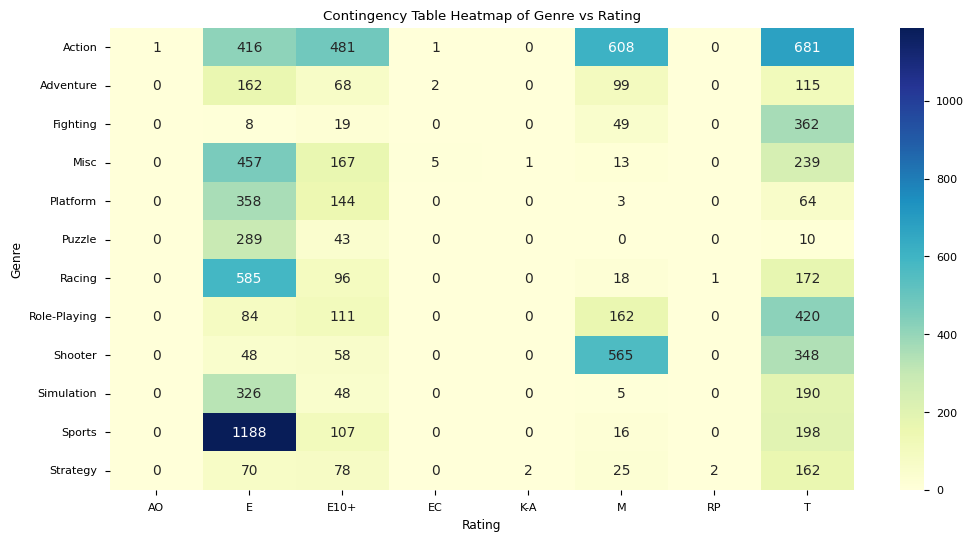

<IPython.core.display.Latex object>

Rating,E,E10+,M,T
Genre,,,,
Action,416,481,608,681
Adventure,162,68,99,115
Fighting,8,19,49,362
Misc,457,167,13,239
Platform,358,144,3,64
Puzzle,289,43,0,10
Racing,585,96,18,172
Role-Playing,84,111,162,420
Shooter,48,58,565,348


<IPython.core.display.Latex object>

Rating,E,E10+,M,T
Genre,,,,
Action,416,481,608,681
Adventure,162,68,99,115
Fighting,8,19,49,362
Misc,457,167,13,239
Platform,358,144,3,64
Racing,585,96,18,172
Role-Playing,84,111,162,420
Shooter,48,58,565,348
Simulation,326,48,5,190


<IPython.core.display.Latex object>

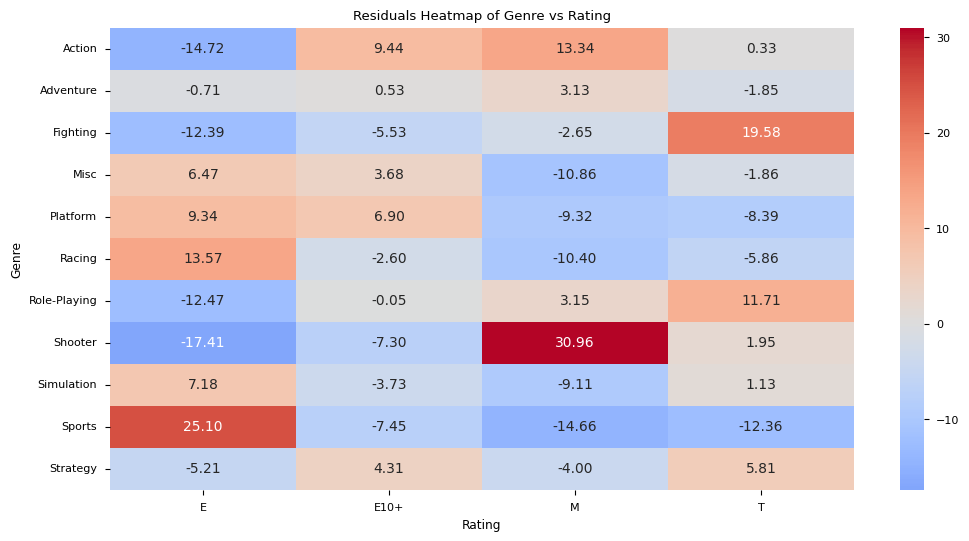

<IPython.core.display.Latex object>

In [41]:
# First we define our hypotheses:
# Null hypothesis (H0): There is no association between genre and rating.
# Alternative hypothesis (H1): There is an association between genre and rating.

df = pd.read_csv('../data/Video_Games_Sales.csv')
df = df[['Genre', 'Rating']].dropna()

contingency_table = pd.crosstab(df['Genre'], df['Rating'])
display(contingency_table)

# Let's visualize the contingency table using a heatmap.
plt.figure(figsize=(12, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Contingency Table Heatmap of Genre vs Rating')
plt.xlabel('Rating')
plt.ylabel('Genre')
plt.show()

display(Latex("The heatmap shows the counts of games for each combination of genre and rating. We can see that the Action genre has a wide distribution of ratings, while others, like Puzzle and Strategy, tend to be for Everyone (E). " \
              "Shooters are mostly rated M, while Sports games are predominantly rated E. This suggests that there may be an association between genre and rating, which we will test using the Chi-Squared test of independence." \
              "On the other hand, some genres like Adventure and Role-Playing have relatively low counts (<5) across ratings, which may affect the reliability of the Chi-Squared test results for those categories."))


# Let's group some of the less frequent ratings into an 'Other' category to ensure that all expected frequencies are sufficiently large for the Chi-Squared test.

rating_counts = df['Rating'].value_counts()
less_frequent_ratings = rating_counts[rating_counts < 84].index
df['Rating'] = df['Rating'].replace(less_frequent_ratings, 'Other') # Ratings with counts less than 84 will be grouped into 'Other'

if df['Rating'].value_counts().min() <= 84:

    df = df[df['Rating'].isin(df['Rating'].value_counts()[df['Rating'].value_counts() > 84].index)]

contingency_table2 = pd.crosstab(df['Genre'], df['Rating'])
display(contingency_table2)

display(Latex("After grouping the less frequent ratings into 'Other', we have ensured that all expected frequencies in the contingency table are sufficiently large for the Chi-Squared test. " \
              "However, some genres still have low counts across ratings. To further improve the reliability of the Chi-Squared test, we will remove any genres that have zero counts in any rating category."))
contingency_table3 = contingency_table2[(contingency_table2 != 0).all(axis=1)] # Remove rows which have any zero counts

display(contingency_table3)

# Let's perform the Chi-Squared test of independence.

chi2_stat, p_value_chi2, dof, expected = chi2_contingency(contingency_table3)
alpha = 0.05

if p_value_chi2 < alpha:

    display(Latex(fr"The Chi-Squared statistic is {chi2_stat:.2f}, the degrees of freedom is {dof}, and the p-value is {p_value_chi2}. Since the p-value is less than the significance" \
                   f" level of {alpha}, we reject the null hypothesis. Therefore, there is enough evidence to conclude that there is an association between genre and rating with 95% confidence."))
    
else:

    display(Latex(fr"The Chi-Squared statistic is {chi2_stat:.2f}, the degrees of freedom is {dof}, and the p-value is {p_value_chi2}. As we can see, since the p-value is greater" \
                   f" than the significance level of {alpha}, we have failed to reject the null hypothesis. Therefore, there isn't enough evidence to conclude that there is an association" \
                   f" between genre and rating with 95% confidence."))
    
# Let's plot the residuals to visualize the differences between observed and expected counts.

residuals = (contingency_table3 - expected) / np.sqrt(expected)

plt.figure(figsize=(12, 6))
sns.heatmap(residuals, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Residuals Heatmap of Genre vs Rating')
plt.xlabel('Rating')
plt.ylabel('Genre')
plt.show()

display(Latex("The residuals heatmap shows the standardized differences between the observed and expected counts for each combination of genre and rating. " \
              "Positive residuals (in red) indicate that the observed count is higher than expected, while negative residuals (in blue) indicate that the observed" \
              " count is lower than expected. For example, the Shooter genre has a higher than expected count of M-rated games and a lower than expected count of E-rated games. " \
              " The residual values help us identify which specific genre-rating combinations contribute most to the overall Chi-Squared statistic."))

##### **2.2.2.2 Comparing Proportions: The Z-Test**


##### **The Z-Test for Two Proportions:**

The Z-Test for two Proportions is a statistical test used to compare the proportions of a categorical outcome between two independent groups. Usually, it is applied when we want to determine if there is a significant difference between the proportions of our sample and a reference proportion; for example, comparing the proportion of clicks on two different ads. The conditions for applying the Z-Test for two Proportions are:

- **Categorical Outcome:** The variable being analyzed should be categorical (binary or dichotomous).

- **Independence:** The observations should be independent of each other.

- **Sample Size:** The sample size should be large enough to ensure that the sampling distribution of the proportion is approximately normal. A common rule of thumb is that both $n_1 \hat{p_1}$, $n_1 (1 - \hat{p_1})$, $n_2 \hat{p_2}$, and $n_2 (1 - \hat{p_2})$ should be at least 10, where $n_1$ and $n_2$ are the sample sizes of the two groups, and $\hat{p_1}$ and $\hat{p_2}$ are the sample proportions (this comes from the CLT applied in the context of a binomial distribution).

The null and alternative hypotheses for the Z-Test for Proportions are usually set up as follows:

- **Null Hypothesis $(H_0)$:** The proportions of the two groups are equal ($\hat{p_1} = \hat{p_2}$).

- **Alternative Hypothesis $(H_A)$:** The proportions of the two groups are not equal ($\hat{p_1} \neq \hat{p_2}$) for a two-tailed test, or $\hat{p_1} > \hat{p_2}$ or $\hat{p_1} < \hat{p_2}$ for a one-tailed test.

The test statistic for the Z-Test for two Proportions is calculated using the formula:

##### $$ \boxed{ Z = \frac{\hat{p_1} - \hat{p_2}}{SE} } $$

where:

- **$\hat{p_1}$** is the sample proportion of group 1.

- **$\hat{p_2}$** is the sample proportion of group 2.

- **$SE$** is the standard error of the difference between the two proportions.

Since we are assuming the null hypothesis is true ($\hat{p_1} = \hat{p_2}$), than $\hat{p_1}$ and $\hat{p_2}$ are just noisy estimations of the same proportion $\hat{p_0}$. Therefore, the standard error should be calculated under the premise that there is only one real proportion, and the p-pool is our best estimate for it. The pooled proportion ($\hat{p_0}$) is calculated as:

$ \boxed{\hat{p_0} = \frac{p_1 + p_2}{n_1 + n_2}} $

where:

- **$\hat{p_1}$** is the number of successes in group 1.

- **$\hat{p_2}$** is the number of successes in group 2.

- **$n_1$** is the sample size of group 1.

- **$n_2$** is the sample size of group 2.

With the pooled proportion, we can now calculate the standard error as:

$ \boxed{SE = \sqrt{\hat{p_0}(1 - \hat{p_0}) \left(\frac{1}{n_1} + \frac{1}{n_2}\right)}} $

The value of the Z-statistic is then compared to a critical value from the **standard normal distribution table** based on the **chosen significance level ($\alpha$)**. Alternatively, we can calculate the p-value associated with the Z-statistic and compare it to $\alpha$ to make a decision about rejecting or failing to reject the null hypothesis. A larger absolute value of the Z-statistic indicates a greater difference between the two proportions, providing evidence against the null hypothesis. If the p-value is less than or equal to $\alpha$, we reject the null hypothesis and conclude that there is a significant difference between the two proportions. If the p-value is greater than $\alpha$, we fail to reject the null hypothesis, indicating that there is no significant difference between the proportions.

##### **The Z-Test for a Single Proportion:**

The Z-Test for a single proportion is used to determine if the proportion of a categorical outcome in a single sample differs significantly from a known or hypothesized population proportion. The conditions for applying the Z-Test for a single proportion are the same to those for the two-proportion test. The null and alternative hypotheses for the Z-Test for a single proportion are usually set up as follows:

- **Null Hypothesis $(H_0)$:** The sample proportion is equal to the reference proportion ($\hat{p} = p_0$).

- **Alternative Hypothesis $(H_A)$:** The sample proportion is not equal to the reference proportion ($\hat{p} \neq p_0$) for a two-tailed test, or $\hat{p} > p_0$ or $\hat{p} < p_0$ for a one-tailed test.

The test statistic for the Z-Test for a single proportion is calculated using the formula:

##### $$ \boxed{ Z = \frac{\hat{p} - p_0}{SE} } $$

where:

- **$\hat{p}$** is the sample proportion.

- **$p_0$** is the reference population proportion.

- **$SE$** is the standard error of the sample proportion, calculated as:

    $ \boxed{SE = \sqrt{\frac{p_0 (1 - p_0)}{n}}} $

  where **$n$** is the sample size.


Just like in the two-proportion test, the value of the Z-statistic is then compared to a critical value from the **standard normal distribution table** based on the **chosen significance level ($\alpha$)**. Alternatively, we can calculate the p-value associated with the Z-statistic and compare it to $\alpha$ to make a decision about rejecting or failing to reject the null hypothesis.


- **Example:** Is there a statistically significant difference in the proportion of 'hit' games (defined as *'Global_Sales'* > 1 million) between 'Nintendo' and 'Electronic Arts'? Let's use a Z-test for two proportions to find out. Use a significance level of $\alpha =0.05$.


In [42]:
# First let's define our hypotheses:
# Null hypothesis (H0): There is no difference in the proportion of hit games between the Nintendo and EA. (p_N = p_EA)
# Alternative hypothesis (H1): There is a difference in the proportion of hit games between the Nintendo and EA. (p_N ≠ p_EA). Remember
# that this is a two-tailed test. It doesn't matter which proportion is higher, just that they are different.

df = pd.read_csv('../data/Video_Games_Sales.csv')
df = df[['Publisher', 'Global_Sales']].dropna()
df_Nintendo = df[df['Publisher'] == 'Nintendo']
df_EA = df[df['Publisher'] == 'Electronic Arts']

# Define hit games as those with Global_Sales greater than 1 million
hit_threshold = 1.0
n_hits_Nintendo = (df_Nintendo['Global_Sales'] >= hit_threshold).sum()
n_hits_EA = (df_EA['Global_Sales'] >= hit_threshold).sum()
p_N = n_hits_Nintendo / len(df_Nintendo)
p_EA = n_hits_EA / len(df_EA)

# Check if the sample sizes are large enough for the normal approximation to be valid
n_N = len(df_Nintendo)
n_EA = len(df_EA)
if n_N * p_N < 10 or n_N * (1 - p_N) < 10 or n_EA * p_EA < 10 or n_EA * (1 - p_EA) < 10:
    raise ValueError("Sample sizes are too small for performing a two-proportion z-test.")

else:
    # Do the two-proportion z-test

    from statsmodels.stats.proportion import proportions_ztest

    count = [n_hits_Nintendo, n_hits_EA]
    nobs = [n_N, n_EA]
    stat_z, pval_z = proportions_ztest(count, nobs)
    alpha = 0.05

    if pval_z < alpha:

        display(Latex(fr"The z-statistic is {stat_z:.2f} and the p-value is {pval_z}. Since the p-value is less than the significance level of {alpha}, we reject the null hypothesis. "
                       "Therefore, there is enough evidence to conclude that there is a difference in the proportion of hit games between Nintendo and Electronic Arts with 95% confidence."\
                        fr" The actual proportions are {p_N*100:.2f}\% for Nintendo and {p_EA*100:.2f}\% for Electronic Arts."))
        
    else:

        display(Latex(fr"The z-statistic is {stat_z:.2f} and the p-value is {pval_z}. As we can see, since the p-value is greater than the significance level of {alpha}, we have failed to reject the null hypothesis. "
                       "Therefore, there isn't enough evidence to conclude that there is a difference in the proportion of hit games between Nintendo and Electronic Arts with 95% confidence."))
        


<IPython.core.display.Latex object>

### **2.3 Summary and Decision Flowchart**

##### We have explored a wide range of hypothesis tests, each suited for different types of data and research questions. To consolidate this knowledge, we can use a decision flowchart. This flowchart provides a structured way to select the appropriate statistical test based on the nature of your data and your analytical goal. It serves as a practical guide for applying the concepts we've learned.

![Decision Flowchart](/home/lucas/stats_for_data_science/images/Decision_Flowchart.png)



---
## **Introduction to Machine Learning**

#### The **goal** of this final section is to bridge the gap between statistical inference and predictive modeling. We will use our statistical foundation to build and evaluate models that can learn from data to make predictions about the future. Following the "from scratch" philosophy, we will build an understanding of the fundamental algorithms that power modern data science. Our journey through this section is structured into four key areas:

- **Modeling Fundamentals:** We will begin by defining the core concepts of Machine Learning (ML), including the crucial practice of splitting data into training and testing sets to evaluate model performance fairly.

- **Supervised Learning:** We will then dive into supervised models, where the goal is to predict a known target. This will include: *Regression* (Simple & Multiple Linear Regression) and *Classification* (Logistic Regression and Decision Trees, along with the essential evaluation metrics).

- **Unsupervised Learning:** Next, we will explore how to find hidden structures in unlabeled data using *K-Means Clustering* to segment our data into natural groups.

- **Specialized Applications:** Finally, we will apply these fundamentals to provide a brief introduction to two specialized and powerful domains: *Time Series Forecasting* and *Natural Language Processing (NLP)*.

### **1.1 The Machine Learning Framework**

Just like physics models reality, we can use computer algorithms to identify mathematical relationships between variables. In Machine Learning, we refer to these algorithms as **models**. The goal of a model is to learn from data and make predictions about new, unseen data. This is achieved through a process called **training**, where the model is exposed to a dataset and adjusts its internal parameters to minimize the difference between its predictions and the actual outcomes. Models can be: 

- **Supervised**: The system receives data that is labeled with the correct answers. For example, predicting energy in a physical system based on its configuration. In this case we might provide a dataset with points $(x_i,y_i)$ and try to learn the function $y = f(x)$, such that $f(x_i) \approx y_i$ for all i.

- **Unsupervised**: System receives data that is not labeled. The model tries to find patterns, extracted/learn distributions, or groupings in the data without any guidance. For example, reconstruct the underlying density function of a physical system based on observed configurations. In this case we might provide a dataset with points $(x_i)$ and try to learn the distribution $P(x)$ that generated the data.

- **Semi-Supervised**: A combination of both above, where the model is trained on a small amount of labeled data and a larger amount of unlabeled data. In this case we might provide a dataset with points $(x_i,y_i)$ for a small subset of the data and only $(x_i)$ for the larger subset, trying to learn the function $y = f(x)$ while also understanding the distribution $P(x)$.

A practical ML workflow typically follows these steps:

1. **Data Collection:** Gather relevant data that will be used to train and test the model.

2. **Data Preprocessing:** Clean and prepare the data for analysis. This may involve handling missing values, encoding categorical variables, normalizing numerical features, and splitting the data into training and testing sets.

3. **Model Selection:** Choose an appropriate model based on the problem type (regression, classification, clustering, etc.) and the characteristics of the data.

4. **Model Training:** Fit the model to the training data by adjusting its parameters to minimize the error between predictions and actual outcomes.

5. **Model Evaluation:** Assess the model's performance using the testing data and appropriate metrics (e.g., accuracy, precision, recall, RMSE).

6. **Final evaluation & deployment:** After selecting the best model, evaluate it once on the held-out test set to estimate real-world performance and deploy if appropriate.

**Important failure modes**

- **Overfitting:** The model learns the training data too well, capturing noise and outliers, but fails to generalize to new data, resulting in poor performance on the testing data.

- **Underfitting:** The model is too simple to capture the underlying structure of the data, resulting in poor performance on both the training and testing data.

- **Data Leakage:** Data leakage occurs when information from outside the training dataset is used to create the model. This can lead to overly optimistic performance estimates during training and poor generalization to new data.


In order to mitigate these issues, we can use techniques such as cross-validation, regularization, and hyperparameter tuning to optimize the model's performance. However, the most important practice to ensure a fair evaluation of our model is to split our data into **training** and **testing** sets. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data. This helps us assess how well the model generalizes to new data and prevents overfitting. A common split ratio is 80% for training and 20% for testing, but this can vary depending on the size of the dataset and the specific problem at hand. In general, the larger the dataset, the smaller the testing set can be, as there will still be enough data to evaluate the model's performance accurately. If the model performs well on testing data, its probably fitting than overfitting.

**NOTE:** We can also choose among models using a third set called the **validation set**. To do it, we first split the data into training and testing sets. Then, we further split the training set into a smaller training set and a validation set. The model is trained on the smaller training set and evaluated on the validation set to tune hyperparameters and select the best model. Finally, the selected model is evaluated on the testing set to assess its performance on unseen data. This approach helps to prevent overfitting and ensures that the best model is optimized for generalization.

- **Example:** We want to build a model to predict the *Global_Sales* of video games based on features like *Genre*, *Platform_Family* and *Critic_Score*. However, before building it, we need to prepare our data for training and evaluation. Let's select our features and target variable, and then split the data into a training set and a testing set.

In [43]:
# We will be using the Scikit-Learn library in our study. It is a popular machine learning library in Python 
# used for statistical modeling and classic algorithms for data mining and data analysis.

from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/Video_Games_Sales.csv')

x = df['Critic_Score'].dropna() # This is our feature variable (independent variable). In the begginning, we only have one feature.
X = pd.DataFrame(x) # Scikit-Learn expects the features to be in a 2D array (DataFrame), even if we have only one feature.
Y = pd.Series(df['Global_Sales'].dropna()) # This is our target variable (dependent variable). Scikit-Learn accepts the target 
# variable as a 1D array (Series).

# The X and Y variables must have the same length. So we will drop any rows in Y that correspond to NaN values in X.
Y = Y[X.index]


# We will split the data into training and testing sets using an 80-20 split.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# test_size=0.2 means 20% of the data will be used for testing
# random_state ensures that the split is the same every time you run the code
display(X_train.shape)
display(Y_train.shape)
display(X_test.shape)
display(Y_test.shape)

(6509, 1)

(6509,)

(1628, 1)

(1628,)

### **1.2 Supervised Learning**

In supervised learning, our goal is to build a model that can predict a specific target variable (y) based on one or more input features (X). We start with the simplest case: analyzing the relationship between two numerical variables.

#### **1.2.1 Regression:** 

Regression analysis is a statistical technique used to model and analyze the relationship between a dependent variable (target) and one or more independent variables (features). The goal of regression is to understand how changes in the independent variables affect the dependent variable, and to make predictions about the dependent variable based on new values of the independent variables. In the ML world, regression can be classified as: *Simple Linear Regression* and *Multiple Linear Regression*.

##### **1.2.1.1 Correlation & Linear Regression**

Linear regression is a statistical method for fitting a linear equation to data where the relationship between two numerical variables can be modeled as a straight line. In order to apply linear regression, the following conditions should be met:

**1. Linearity:** The relationship between the independent and dependent variable should be linear.

**2. Homoscedasticity:** The residuals should have constant variance at all levels of the independent variable.

**3. Normality:** The residuals should be approximately normally distributed.

The simple linear regression follows the equation of a degree 1 polynomial:

##### $$ \boxed{\hat{y} = \beta_0 + \beta_1 x + \epsilon} $$

where:

- **$\hat{y}$** is the predicted dependent variable (target).

- **$x$** is the independent variable (feature).

- **$\beta_1$** is the slope of the line (coefficient).

- **$\beta_0$** is the y-intercept.

- **$\epsilon$** is the error term.


In this scenario, our data can be expressed as: $\text{Data} = \text{Fit} + \text{Residuals}$. The **residuals** represent the difference between the observed values and the values predicted by the linear model. The goal of linear regression is to find the best-fitting line that *minimizes* the sum of residuals. This is typically achieved using the **Ordinary Least Squares (OLS)** method, which minimizes the sum of the *squared* residuals. We square the residuals to ensure that both positive and negative deviations contribute positively to the total error, and later differentiate the error function to find the optimal coefficients $\beta_0$ and $\beta_1$. Residuals are important because they provide insight into the accuracy of the model's predictions. By analyzing the residuals, we can assess whether the linear model is appropriate for the data, identify potential outliers, and evaluate the assumptions of linear regression. Mathematically, the residual for each observation is calculated as:

$ \boxed{ e_i = y_i - \hat{y_i} } $

where:  

- **$e_i$** is the residual for observation $i$.

- **$y_i$** is the observed value of the dependent variable for observation $i$.

- **$\hat{y_i}$** is the predicted value of the dependent variable for observation $i$.

The error of the model can be quantified using the **Root Mean Squared Error (RMSE)**, which provide a measure of how well the model fits the data. Lower values of RMSE indicate a better fit. Mathematically, the RMSE is calculated as:

  $ \boxed{\text{RMSE} =  \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y_i})^2 }} $


The strength and direction of the linear relationship between two numerical variables can be quantified using *correlation coefficients*. The two most common types of correlation coefficients are **Pearson's correlation coefficient** and **Spearman's rank correlation coefficient**.

**Pearson's Correlation**

Pearson's correlation coefficient (r) is calculated as:

$$ \boxed{ r = \frac{1}{n-1} \sum_{i=1}^{n} \frac{(x_i - \bar{x})(y_i - \bar{y})}{\sigma_x \sigma_y} } $$

where:

- **$n$** is the number of paired observations.

- **$x_i$** and **$y_i$** are the individual sample points indexed with i.

- **$\bar{x}$** and **$\bar{y}$** are the means of the x and y variables, respectively.

- **$\sigma_x$** and **$\sigma_y$** are the standard deviations of the x and y variables, respectively.

Pearson's **r** ranges from -1 to 1:

- **1** indicates a perfect positive linear relationship.

- **-1** indicates a perfect negative linear relationship.

- **0** indicates no linear relationship.

The slope of the linear regression line ($\beta_1$) and the intercept ($\beta_0$) can be directly related to Pearson's correlation coefficient. Specifically, the slope can be calculated as:

- $ \boxed{ \beta_1 = r \frac{\sigma_y}{\sigma_x} } $

- $ \boxed{ \beta_0 = \bar{y} - \beta_1 \bar{x} } $

**Spearman's Correlation**

The Spearman's correlation is a non-parametric statistic that measures the strength and direction of the *monotonic* relationship (one that consistently increases or decreases) between two variables. It gives a rank to the individuals $(x_i,y_i)$ data points based on their values, and then computes Pearson's correlation coefficient on the ranks. However, it differs to Mann-Whitney U test/ Kruskal-Wallis, since the ranking doesnt involve grouping the data. The formula for Spearman's correlation coefficient ($\rho$) is:

$$ \boxed{ \rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)} } $$

where:

- **$d_i$** is the difference between the ranks of corresponding variables.

- **$n$** is the number of observations.

Spearman's **$\rho$** also ranges from -1 to 1, with the same interpretations as Pearson's r. However, Spearman's correlation is more robust to outliers and can capture *non-linear* monotonic relationships, making it suitable for ordinal data or non-normally distributed variables.


**Coefficient of Determination ($R²$)**

The coefficient of determination, denoted as $R²$, measures the proportion of variance in the dependent variable that can be explained by the independent variable(s) in a regression model. It provides an indication of how well the model fits the data. $R²$ is calculated as:

$ \boxed{ R² = 1 - \sum_{i=1}^{n} \frac{ (y_i - \hat{y_i})^2}{(y_i - \bar{y})^2} } $

where:

- **$y_i$** is the actual value of the dependent variable.

- **$\hat{y_i}$** is the predicted value of the dependent variable.

- **$\bar{y}$** is the mean of the dependent variable.

$R²$ ranges from 0 to 1:

- **0** indicates that the model does not explain any of the variability in the dependent variable. In other words, the model's predictions are no better than simply using the mean of the dependent variable.

- **1** indicates that the model explains all the variability in the dependent variable.

- A value **between** 0 and 1 indicates the *proportion* of variance explained by the model. For example, an $R²$ of 0.75 means that 75% of the variance in the dependent variable can be explained by the independent variable(s) in the model.

**NOTE:** In the case of *simple linear regression* with **one** independent variable, $R²$ is equal to the square of Pearson's correlation coefficient: **$R² = r²$**

**Correlation as Hypothesis Testing**

In the context of hypothesis testing, correlation coefficients can be used to test the strength and direction of the relationship between two variables. The null hypothesis ($H_0$) typically states that there is no correlation between the variables (i.e., the population correlation coefficient is zero), while the alternative hypothesis ($H_a$) states that there is a significant correlation.

To test the significance of the correlation coefficient, we can use a t-test:

$ \boxed{ t = \frac{r \sqrt{n-2}}{\sqrt{1-r^2}} } $

where:

- **$r$** is the sample correlation coefficient.

- **$n$** is the number of paired observations.

The calculated t-value can be compared against a critical value from the t-distribution to determine whether to reject the null hypothesis based on the desired significance level (e.g., 0.05) and p-value.

##### **1.2.1.2 Simple Linear Regression: From Statistics Inference to ML**

The term "regression" is used in two different contexts: **Statistical Inference** and **Machine Learning**. While both contexts involve modeling linear relationships between variables through the same mathematical framework (least squares method), their goals and approaches differ significantly. 

In the first context, regression is used to *understand* the relationship between variables. We want to know if the relationship is significant, how strong it is, and how changes in one variable affect another. This involves estimating coefficients, testing hypotheses, and constructing confidence intervals. The focus is on interpretation and understanding the underlying data-generating process. 

In the second context, regression is used to *predict* outcomes based on input features. The primary goal is to build a model that can accurately forecast the target variable for new, unseen data. Here, the emphasis is on model performance, generalization, and minimizing prediction error. Techniques such as cross-validation, regularization, and hyperparameter tuning are commonly employed to optimize predictive accuracy.

As we've said, the equation for both contexts is the same, however the tools we use to implement them differ. In Python, the `statsmodels` library is typically used for regression in the context of statistical inference, while the `scikit-learn` library is used for regression in the context of machine learning.

- **Example:** We want to build a ML model to predict *Global_Sales* in relation to *Critic_Score*. Is *Critic_Score* a good candidate for a feature? For this task our goal is to *understand* the relationship between both variables. Is it significant? How strong is it? Use linear regression and correlation analysis to investigate. The following task is to *predict* sales on new data. Build a linear regression model using *Critic_Score* as a feature and evaluate its performance.

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Global_Sales   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     352.2
Date:                Wed, 29 Oct 2025   Prob (F-statistic):           1.41e-76
Time:                        10:41:00   Log-Likelihood:                -13300.
No. Observations:                6509   AIC:                         2.660e+04
Df Residuals:                    6507   BIC:                         2.662e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.4623      0.117    -12.507      0.000      -1.692      -1.233
Critic_Score     0.0312      0.002     18.768      0.000       0.028       0.034
==============================================================================
Omnibus:                    13981.418   Durbin-Watson:                   2.012
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        109539285.225
Skew:                          18.733   Prob(JB):                         0.00
Kurtosis:                     637.421   Cond. No.                         355.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<IPython.core.display.Latex object>

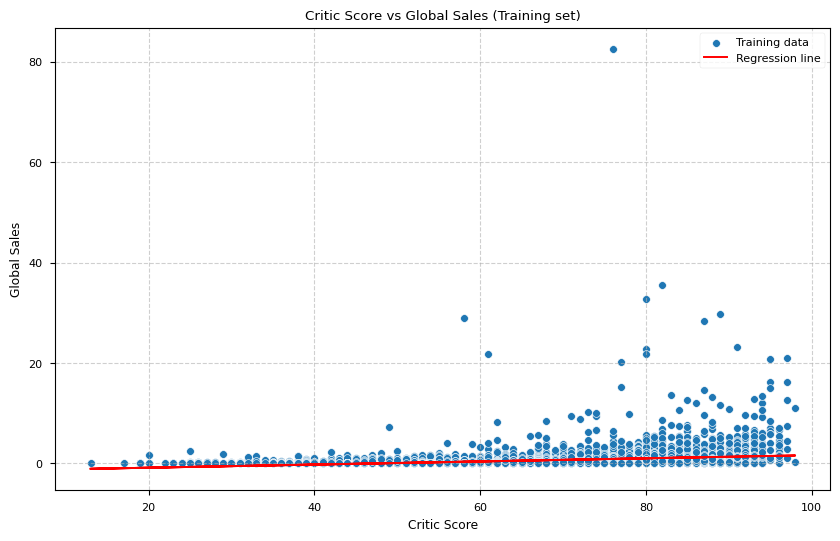

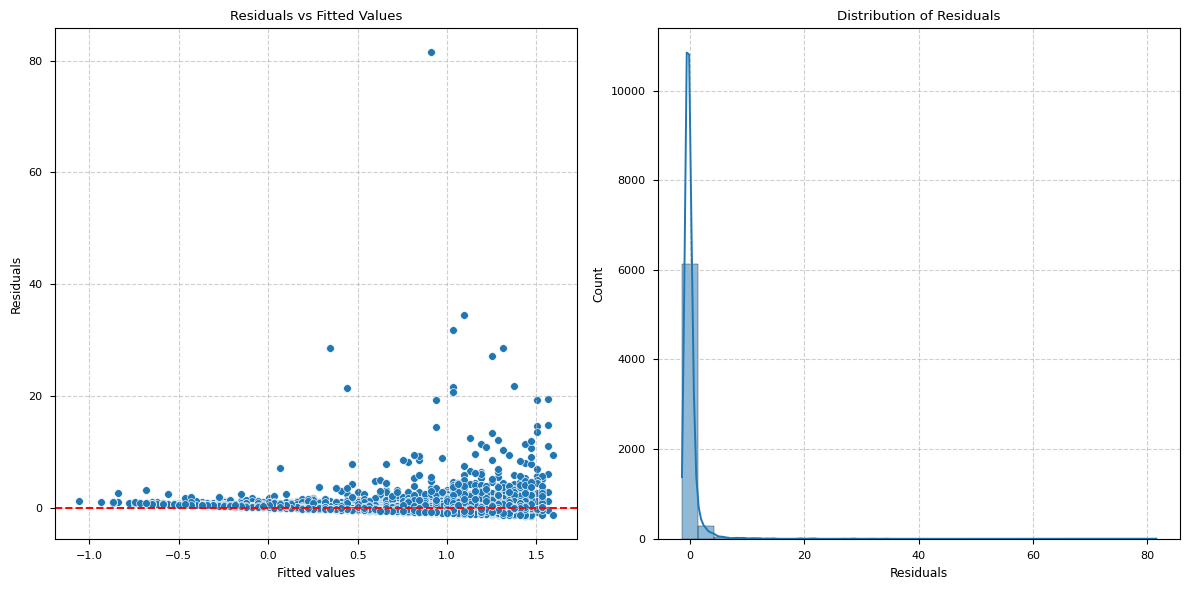

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [44]:
# We will perform a correlation test to assess the relationship between Critic_Score and Global_Sales.
# Since we want to build a model, we will use the training set for this analysis. This is fundamental to avoid data leakage.

X_train_const = sm.add_constant(X_train) # Add a constant term to the predictor variable for the intercept
model = sm.OLS(Y_train, X_train_const).fit() # Fit the ordinary least squares regression model
display(model.summary()) # Display the summary of the regression results

display(Latex(fr"From the regression results, we can see that the coefficient r for Critic_Score is positive (approximately 0.03), however its value is very small. " \
                "This indicates that there is a positive relationship between Critic_Score and Global_Sales, meaning that as Critic_Score increases, Global_Sales tends to increase as well. " \
                "However, the effect size is quite small, suggesting that changes in Critic_Score have a limited impact on Global_Sales. " \
                "Additionally, the p-value for the Critic_Score coefficient is less than 0.05, indicating that this relationship is statistically significant at the 5% significance level. But" \
                fr"happens because the number of observations is large, which increases the power of the statistical test.The R-squared value for the model is $\approx 0.05$," \
                "(a very low value) indicating that only about 5% of the variability in Global_Sales can be explained by Critic_Score alone. " ))

# We can plot the regression line along with the training data points to visualize the relationship.
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train['Critic_Score'], y=Y_train, label='Training data')
plt.plot(X_train['Critic_Score'], model.predict(X_train_const), color='red', label='Regression line')
plt.xlabel('Critic Score')
plt.ylabel('Global Sales')
plt.title('Critic Score vs Global Sales (Training set)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# We can also plot the residuals to check for homoscedasticity and normality and the residuals vs fitted values to check for linearity.
residuals = model.resid
fitted = model.fittedvalues
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Residuals vs Fitted Values')
plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


display(Latex("The residuals vs fitted values plot shows that the residuals are scattered around zero, however non-constant variability" \
              " can be seen. We observe that as the fitted values increase, the spread of the residuals also increases. This pattern suggests" \
              " heteroscedasticity, meaning that the variance of the residuals is not constant across all levels of the fitted values. This" \
              " violates one of the key assumptions of linear regression and may impact the validity of our model's predictions. The residuals " \
              "distribution histogram shows that the residuals are NOT normally distributed, there is an asymmetry in the distribution, it is" \
                " a right-skewed distribution rather than a perfect normal distribution. The first plot confirms both observations. We can see that " \
                "as the critics score increases, the global sales also increases, but is very small, as indicated by the low r and $R^2$ values. "))    

# Now let's calculate the Pearson coefficient indeppendently to confirm the results from the regression analysis.

# Pearson
r_pearson = stats.pearsonr(X_train['Critic_Score'], Y_train)
r_pearson_sq_manual = r_pearson[0] ** 2

display(Latex(fr"The Pearson correlation coefficient r is approximately {r_pearson[0]:.2f}. " \
          fr"If we calculate $r^2$ manually, we get {r_pearson_sq_manual:.2f}. The value obtained from the regression is {model.rsquared:.2f}. This " \
             "confirms that in the statsmodels regression output, the R-squared value, represents the square of the Pearson correlation coefficient " \
              "between the predictor and target variables."))



In [45]:
# Based on our previous analysis, we can infer that while there is a statistically significant positive relationship between 
# Critic_Score and Global_Sales, the effect size is small and the model explains only a small portion of the variability in sales.
# Therefore, we expect that our predictions from a regression model using only Critic_Score as a predictor will have a very poor performance.
# Let's use Scikit-Learn to build a simple linear regression model and evaluate its performance.

model_lm = LinearRegression() # Create a linear regression model
model_lm.fit(X_train, Y_train) # Fit the model to the training data

# Now let's plot the coefficients b_0 (intercept) and b_1 (slope) and compare them with the statsmodels results.
b_0 = model_lm.intercept_
b_1 = model_lm.coef_[0]

display(Latex(fr"The intercept $\beta_0$ from the scikit-learn model is {b_0:.2f} and the slope $\beta_1$ is {b_1:.2f}. " \
              "These values are very similar to those obtained from the statsmodels regression analysis, which were approximately " \
              fr"{model.params[0]:.2f} for the intercept and {model.params[1]:.2f} for the slope. This consistency shows that both " \
              "libraries use OLS regression and got the same curve."))


# Now let's make predictions on the test set and evaluate the model's performance

Y_pred = model_lm.predict(X_test) # Make predictions on the test data
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred) # Compares the model predictions with new data (not used in training), i.e the test.
# It does that by calculating R², with ŷ_i coming from the predictions and y_i from the actual test values.
# In other words, R² tells us how much of the variability in the test data is captured by the model’s predictions

display(Latex(fr"The Root Mean Squared Error (RMSE) of the model on the test set is {rmse:.2f}, indicating that on average, our predictions " \
              fr"deviate from the actual Global Sales by about {rmse:.2f} million units. Considering that videogames sales are typically well below " \
              fr"1 million units, this RMSE is quite large. The $R^2-$ score value is {r2:.2f}, which suggests that " \
              fr"the model performed very poorly in the context of predicting video game sales. As we've pointed out earlier, " \
              fr"that was expected, since the $R^2$ value from the fit is quite low." ))



/tmp/ipykernel_13317/3247071767.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fr"{model.params[0]:.2f} for the intercept and {model.params[1]:.2f} for the slope. This consistency shows that both " \


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

##### **1.2.1.3 Multiple Linear Regression**

Multiple Linear Regression (MLR) is an extension of simple linear regression for the case that the response variable (target) is influenced by more than one predictor variable (feature) simultaneously. The conditions for applying MLR are similar to those for simple linear regression, with an additional consideration: **No multicollinearity**. This means that the independent variables should **not** be correlated with each other. Mathematically, MLR can be expressed as:

##### $$ \boxed{\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_k x_k + \epsilon} $$

where:

- **$\hat{y}$** is the predicted dependent variable (target).

- **$x_1, x_2, ..., x_k$** are the independent variables (features).

- **$\beta_1, \beta_2, ..., \beta_k$** are the coefficients for each independent variable.

- **$\beta_0$** is the y-intercept.

- **$\epsilon$** is the error term.

In MLR, the parameters $\beta_0, \beta_1, \beta_2, ..., \beta_k$ are estimated using the Ordinary Least Squares (OLS) method, which minimizes the sum of squared residuals, just like in simple linear regression. The interpretation of the coefficients in MLR is similar to that in simple linear regression: each coefficient represents the expected change in the dependent variable for a one-unit change in the corresponding independent variable, while holding **all** other *independent* variables *constant*.

**Adjusted Coefficient of Determination ($R²$) in MLR**

In MLR, the coefficient of determination ($R²$) remains with the same interpretation as in simple linear regression, measuring the proportion of variance in the dependent variable explained by the independent variables. However, since MLR involves multiple predictors, we often use the **Adjusted $R²$** to account for the number of predictors in the model. The Adjusted $R²$ is calculated as:

$ \boxed{R²_{adj} = 1 - \frac{(1 - R²)(n - 1)}{(n - k - 1)}} $

where:

- **$R²_{adj}$** is the adjusted coefficient of determination.

- **$R²$** is the coefficient of determination.

- **$n$** is the number of observations.

- **$k$** is the number of independent variables (predictors).

The Adjusted $R²$ will always be less than or equal to the regular $R²$ and provides a more accurate measure of model performance when multiple predictors are involved. It penalizes the addition of unnecessary predictors that do not improve the model's explanatory power, helping to prevent overfitting (if adding a new predictor does not significantly increase the $R²$, the Adjusted $R²$ may decrease, indicating that the new predictor does not contribute meaningfully to the model). In that sense, it is a tool to compare models, by checking if adding or removing predictors improves the model's performance, and should be used in the context of trained data. 


**Adjusted $R²$ and Model Generalization**

As we've seen before, the **adjusted $R²$** measures how well the regression line fits the *training data*. However, a high adjusted $R²$ doesn’t necessarily mean that the model will perform well on *new* data.

When we add more variables to a regression model, the adjusted $R²$ can increase simply by coincidence — the model might capture random patterns or noise that don’t actually exist in the real world. This phenomenon is known as **overfitting**, and it leads to models that perform very well on the training data but fail to generalize to unseen data.

**Why We Split the Data (Train/Test Split)**

To properly evaluate a model’s *true* performance, we need to test it on data it has never seen before.
That’s why datasets are usually divided into:

* **Training set:** Used to fit the model and estimate its coefficients.
* **Testing set:** Used to evaluate how well the model generalizes to new observations.

If the model performs significantly worse on the testing data than on the training data, it’s a clear sign of overfitting.

**Multicollinearity: When Predictors Are Correlated**

Another common issue that can distort model performance is **multicollinearity** — when two or more independent variables are highly correlated with each other. In such cases, the model struggles to determine which variable is actually influencing the target, leading to unstable and unreliable coefficient estimates.

To detect multicollinearity, we can use the **Variance Inflation Factor (VIF)**.
A high VIF indicates that a variable shares a strong linear relationship with other predictors and may need to be removed or transformed.

$\boxed{VIF_i = \frac{1}{1 - R_i^2}}$

where:

- **$R_i^2$** is the $R²$ value obtained when variable *i* is regressed on all the other independent variables.

In general:

- **VIF = 1:** No correlation with other variables.

- **VIF > 5:** Moderate correlation (potential concern).

- **VIF > 10:** High correlation — multicollinearity likely present.

**Visualizing Correlations**

Besides VIF, visual tools are extremely helpful for diagnosing correlated features:

- **Correlation heatmaps:** Show pairwise correlation coefficients between variables.

- **Pairplots (scatterplot matrices):** Reveal linear or nonlinear relationships visually.

Even if a model shows a high adjusted $R²$, that doesn’t guarantee it has captured the *true* underlying relationships.
Always validate the model on unseen data and check for multicollinearity among predictors — this ensures the model is learning real patterns rather than coincidences in the sample.

**Model Improvement Strategies & Diagnostics Practices**

To enhance the performance and reliability of a multiple linear regression model, consider the following strategies and diagnostic practices:

- **Feature Selection:** Use techniques like backward elimination (removing the least significant variables by checking how they change $R²$), forward selection (adding the most significant variables one by one as long as they improve $R²$).

- **Residual Analysis:** Examine residual plots to check for patterns that may indicate non-linearity, heteroscedasticity, or outliers. For this consider plotting residuals vs. fitted values, residuals vs. each predictor, and Q-Q plots/histograms to assess normality.

- **Apply Transformations:** If residuals show non-linearity or heteroscedasticity, consider transforming the dependent variable (e.g., $ln(x_i)$, $\sqrt{x_i}$, $\frac{1}{x_i}$) or the process of truncation (assigning a maximum value to the dependent variable).


**Example:** The previous simple linear model using only *Critic_Score* was very poor and violated key assumptions (heteroscedasticity, non-normal residuals). Build a Multiple Linear Regression (MLR) model to predict *Global_Sales* using all available numerical features (*Critic_Score*, *User_Score*, *Critic_Count*, and *User_Count*). Evaluate its performance and check for assumption violations. If possible, apply transformations and improve the model. 

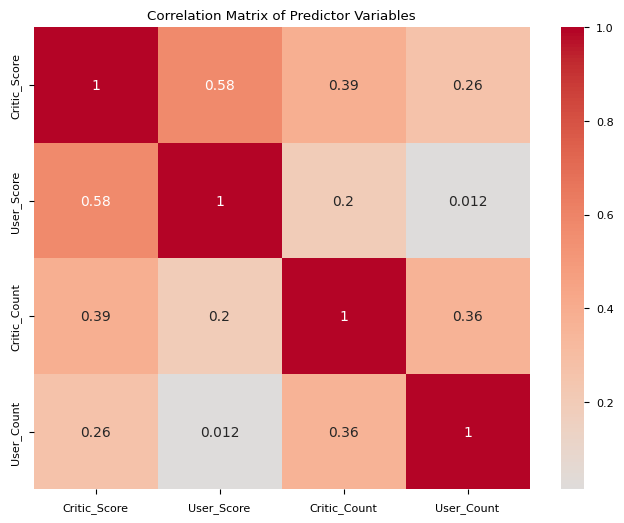

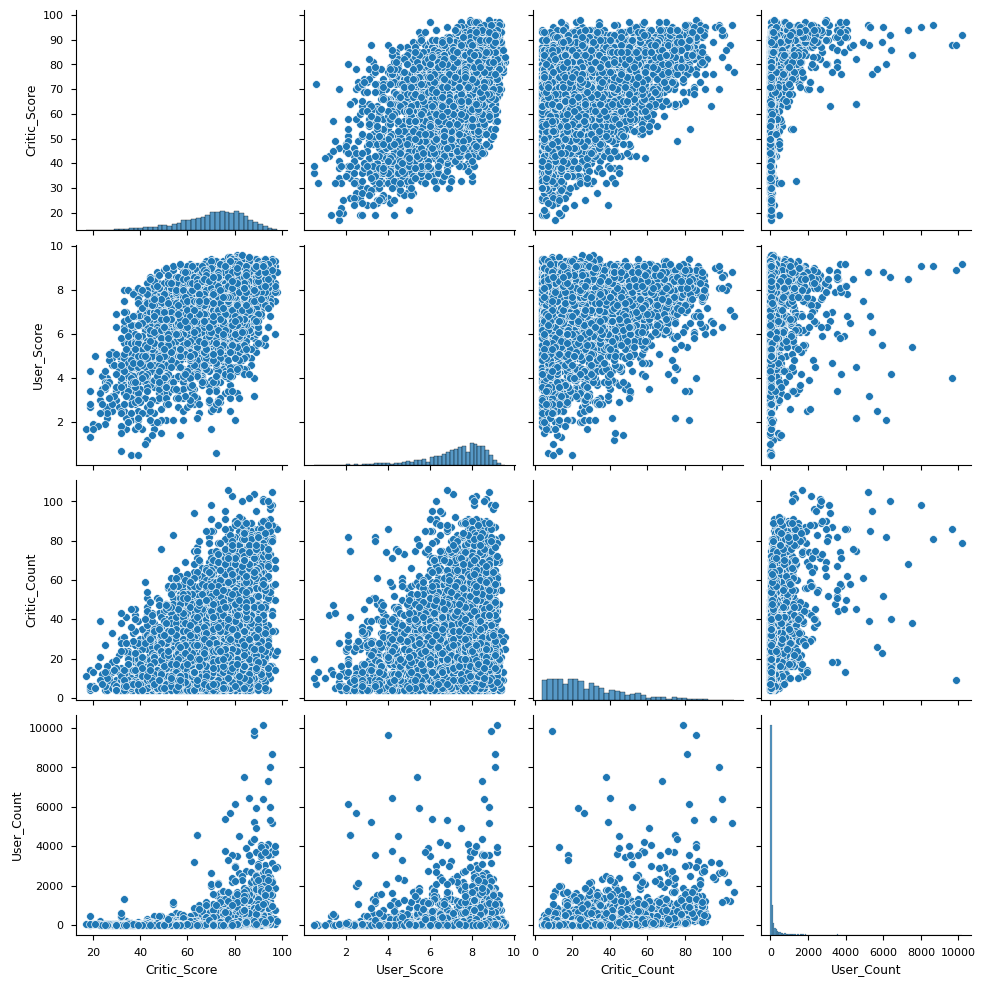

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [46]:
df = pd.read_csv('../data/Video_Games_Sales.csv')
data_mlr = df[['Critic_Score', 'User_Score', 'Global_Sales', 'Critic_Count', 'User_Count']]
data_mlr = pd.to_numeric(data_mlr.stack(), errors='coerce').unstack() # Convert all columns to numeric, setting errors to NaN
data_mlr = data_mlr.dropna() # Drop rows with any NaN values
mlr_x = data_mlr[['Critic_Score', 'User_Score', 'Critic_Count', 'User_Count']]
mlr_y = data_mlr['Global_Sales']
X_train_mlr, X_test_mlr, Y_train_mlr, Y_test_mlr = train_test_split(mlr_x, mlr_y, test_size=0.2, random_state=42) # 80-20 split

# Before building the multiple linear regression model, let's check for multicollinearity among the predictor variables.

corr_matrix = X_train_mlr.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Predictor Variables')
plt.show()

pairplot = sns.pairplot(X_train_mlr)
plt.show()

display(Latex("*Critic_Score × User_Score* is the pair with the strongest linear relationship — the heatmap shows 0.58, which is a" \
    "moderate positive correlation. The pairplot confirms this: there is a visible upward trend between critics' scores and users'" \
    "scores. This makes logical sense for videogame data (if a game is perceived as very good or very bad, both critics and the" \
    "public tend to agree). *Critic_Score × Critic_Count*, *Critic_Count × User_Count*, and *Critic_Score × User_Count* have " \
    "low-to-moderate correlations. These findings suggest that counts (number of reviews) are somewhat related to scores — perhaps" \
    "more popular games (with more reviews) exhibit different scoring patterns, which is natural since they likely attract a larger" \
    "audience. Additionally, *User_Count* is highly skewed, reminiscent of the *Global_Sales* histogram pattern (very right-skewed)." \
    "The pairplot also shows that the scoring scales for users and critics differ (one uses 0–100 and the other 0–10). We also observe" \
     "nonlinearity between scores and counts (for example, many points with low counts and a few with very high counts)." ))

display(Latex("Our data shows some moderate correlations among predictors, but no extreme multicollinearity issues. In order to further" \
               "assess multicollinearity, we will proceed by calculating the Variance Inflation Factor (VIF) for each predictor."))




--- MODEL 1 SUMMARY ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Global_Sales   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     175.5
Date:                Wed, 29 Oct 2025   Prob (F-statistic):          7.44e-142
Time:                        10:41:02   Log-Likelihood:                -11592.
No. Observations:                5613   AIC:                         2.319e+04
Df Residuals:                    5608   BIC:                         2.323e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.9692      0.148     -6.530      0.000      -1.260      -0.678
Critic_Score     0.0193      0.002      7.823      0.000       0.014       0.024
User_Score      -0.0387      0.022     -1.746      0.081      -0.082       0.005
Critic_Count     0.0198      0.002     13.000      0.000       0.017       0.023
User_Count       0.0005   4.91e-05      9.695      0.000       0.000       0.001
==============================================================================
Omnibus:                    12146.924   Durbin-Watson:                   2.016
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         98674781.964
Skew:                          19.014   Prob(JB):                         0.00
Kurtosis:                     651.434   Cond. No.                     3.49e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.49e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

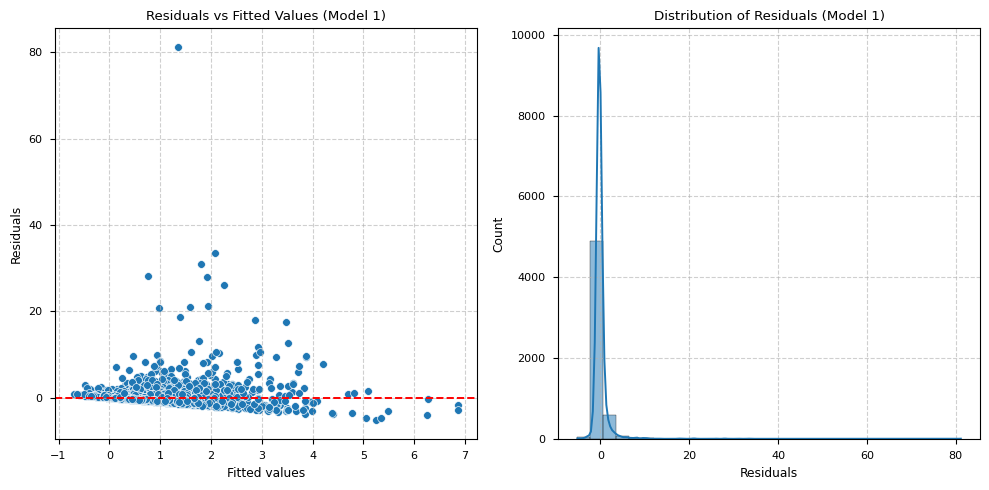

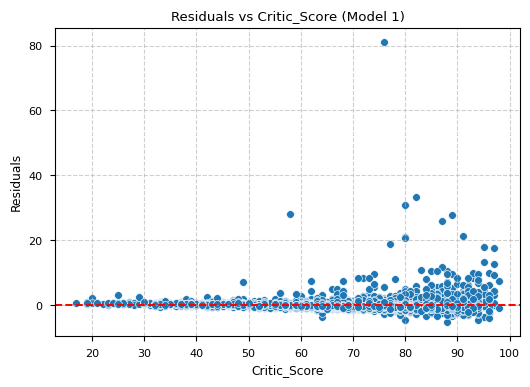

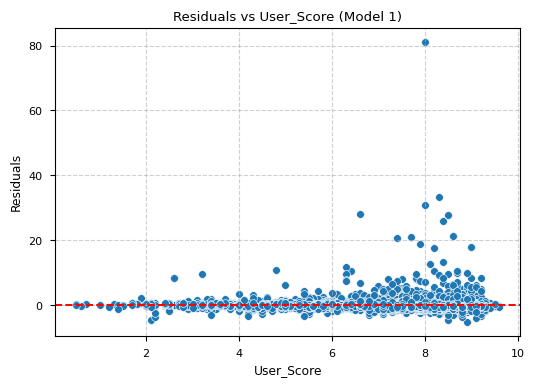

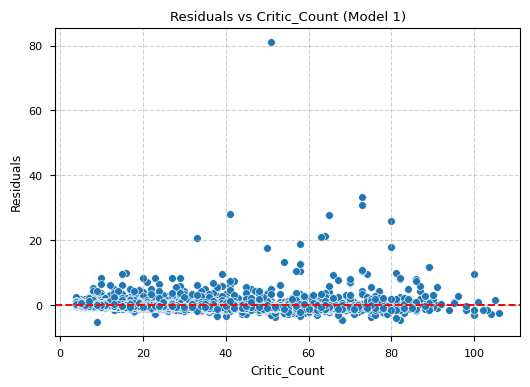

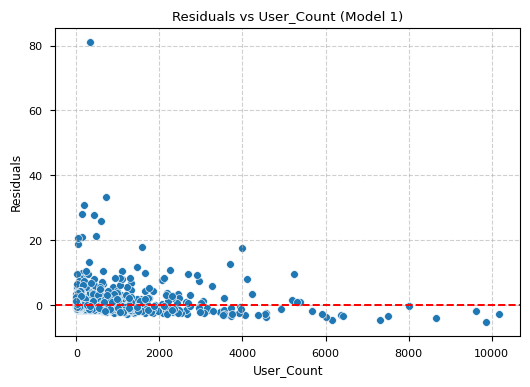

<IPython.core.display.Latex object>

--- VIF FOR MODEL 1 ---


,Feature,VIF
0,Critic_Score,37.744947
1,User_Score,33.835831
2,Critic_Count,4.234983
3,User_Count,1.311800


<IPython.core.display.Latex object>

In [47]:
# Model 1: All predictors + General evaluation

X_train_const_mlr = sm.add_constant(X_train_mlr)
model_1 = sm.OLS(Y_train_mlr, X_train_const_mlr).fit()
print("--- MODEL 1 SUMMARY ---")
display(model_1.summary())

# 2. Evaluate the residuals of Model 1: residuals vs fitted values; residuals histogram; residuals vs each predictor.
residuals_mlr = model_1.resid
fitted_mlr = model_1.fittedvalues
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=fitted_mlr, y=residuals_mlr)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)  
plt.title('Residuals vs Fitted Values (Model 1)')

plt.subplot(1, 2, 2)
sns.histplot(residuals_mlr, bins=30, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals (Model 1)')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 1)
for column in X_train_mlr.columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_train_mlr[column], y=residuals_mlr)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel(column)
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs {column} (Model 1)')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

display(Latex("The model in its current form performs poorly: R² = 0.111, so it only explains about 11% of the variability in Global_Sales." \
            "The regression summary shows that Critic_Score, Critic_Count and User_Count are statistically significant (p ≈ 0.000), " \
            "while User_Score has a marginal/non-significant p-value (0.081) when conditioned on the other predictors. This does not by" \
            "itself prove multicollinearity, but combined with the moderate correlation we saw between Critic_Score and User_Score (≈ 0.58)," \
            "it motivates a targeted check with VIF and the pre-planned comparison between models with and without User_Score. Residual "\
            "diagnostics reveal serious departures from OLS assumptions: residuals are strongly right-skewed and heavy-tailed, there are many" \
            "outliers (residuals up to ≈ 80), and variance is not constant across fitted values. Visually, residuals tend to be mostly positive"\
            "for many fitted values, indicating the model often underpredicts sales. When plotting residuals against predictors we see " \
            "heteroscedastic patterns — variability increases with Critic_Score and User_Score, while Critic_Count shows a more stable spread." \
            "User_Count is extremely right-skewed, and that skewness is reflected in the residuals (a concentration of residuals on the left side" \
             "of the User_Count plot), which is consistent with the skew observed in the pairplot."))


# Let's calculate the VIF for each predictor in Model 1 to assess multicollinearity.
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data_1 = pd.DataFrame()
vif_data_1["Feature"] = X_train_mlr.columns
vif_data_1["VIF"] = [variance_inflation_factor(X_train_mlr.values, i) for i in range(X_train_mlr.shape[1])]
print("--- VIF FOR MODEL 1 ---")
display(vif_data_1)

display(Latex("The VIF values for both Critic_Score and User_Score are extremely high (above 30), indicating severe multicollinearity between these two predictors. " \
                "This confirms our earlier suspicion based on their moderate correlation (≈ 0.58). Such high VIF values suggest that the estimates of their coefficients" \
                "are unstable and unreliable when both are included in the model. Therefore we will consider building a model without User_Score and another without Critic_Score." ))

<IPython.core.display.Latex object>

--- MODEL 2 SUMMARY ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Global_Sales   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                     502.3
Date:                Wed, 29 Oct 2025   Prob (F-statistic):               0.00
Time:                        10:41:03   Log-Likelihood:                -2644.4
No. Observations:                5613   AIC:                             5299.
Df Residuals:                    5608   BIC:                             5332.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.2430      0.030     -8.006      0.000      -0.302      -0.183
Critic_Score     0.0075      0.001     14.546      0.000       0.007       0.009
User_Score      -0.0150      0.005     -3.312      0.001      -0.024      -0.006
Critic_Count     0.0059      0.000     17.512      0.000       0.005       0.007
User_Count       0.0008   6.21e-05     12.818      0.000       0.001       0.001
==============================================================================
Omnibus:                     2294.467   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            14795.172
Skew:                           1.829   Prob(JB):                         0.00
Kurtosis:                      10.062   Cond. No.                         844.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

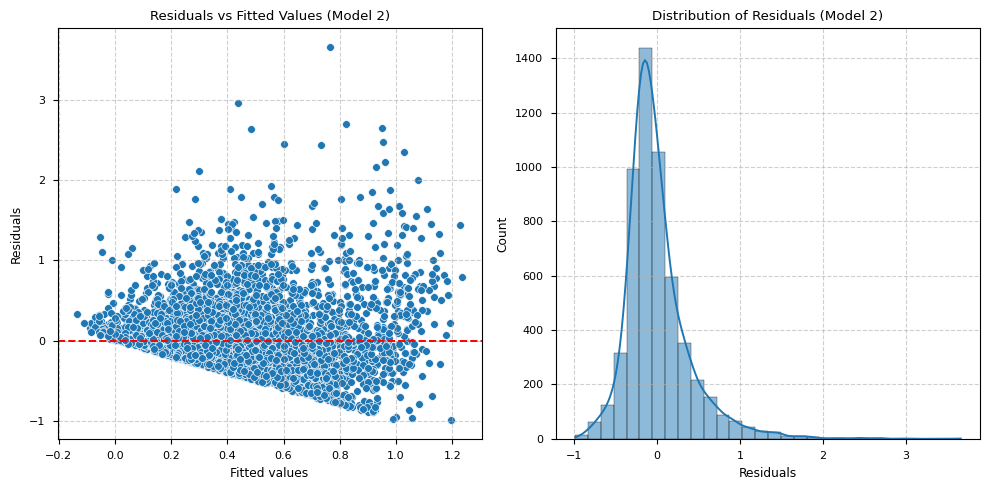

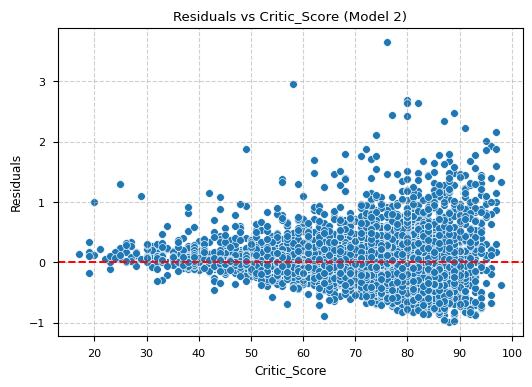

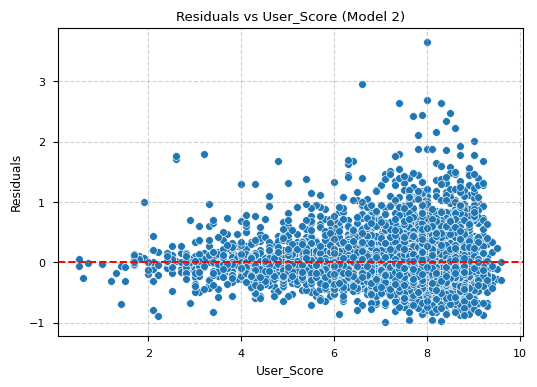

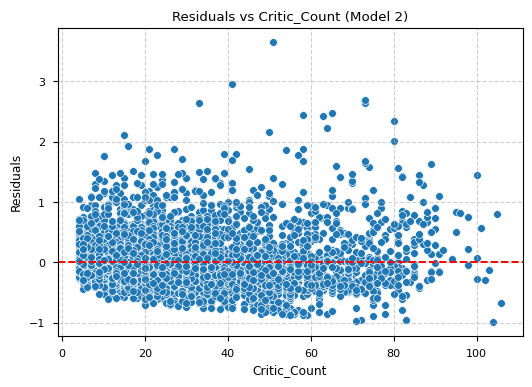

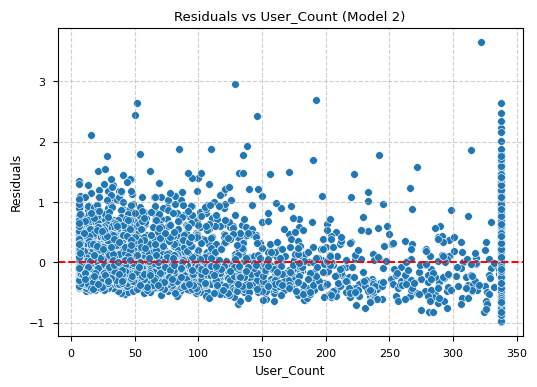

--- VIF FOR MODEL 2 ---


,Feature,VIF
0,Critic_Score,39.675252
1,User_Score,35.120769
2,Critic_Count,5.005273
3,User_Count,2.439933


<IPython.core.display.Latex object>

In [48]:
# Model 2: All predictors with transformations + General evaluation

display(Latex("Our previous analysis showed a very right-skewed distribution for residuals and strong outliers." \
 "To address these issues, we will apply a log transformation to the target variable (Global_Sales) and a winsorize transformation"\
 "to the User_Count predictor to limit the influence of extreme values. Winsorizing involves capping extreme values to reduce their"\
 "impact on the model. It does that by setting all values below a certain percentile to that percentile value, and all values above"\
 "another percentile to that percentile value." ))

Y_train_log = np.log1p(Y_train_mlr) # Log transformation of the target variable
from scipy.stats.mstats import winsorize
X_train_winsorized = X_train_mlr.copy()
X_train_winsorized['User_Count'] = winsorize(X_train_winsorized['User_Count'], limits=[0.1, 0.1]) # Winsorize User_Count at 10% on both ends

X_train_const_mlr2 = sm.add_constant(X_train_winsorized)
model_2 = sm.OLS(Y_train_log, X_train_const_mlr2).fit()
print("--- MODEL 2 SUMMARY ---")
display(model_2.summary())

# 2. Evaluate the residuals of Model 2: residuals vs fitted values; residuals histogram; residuals vs each predictor.
residuals_mlr2 = model_2.resid
fitted_mlr2 = model_2.fittedvalues
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=fitted_mlr2, y=residuals_mlr2)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Residuals vs Fitted Values (Model 2)')

plt.subplot(1, 2, 2)
sns.histplot(residuals_mlr2, bins=30, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals (Model 2)')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 1)
for column in X_train_winsorized.columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_train_winsorized[column], y=residuals_mlr2)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel(column)
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs {column} (Model 2)')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

#VIFs for Model 2
vif_data_2 = pd.DataFrame()
vif_data_2["Feature"] = X_train_winsorized.columns
vif_data_2["VIF"] = [variance_inflation_factor(X_train_winsorized.values, i) for i in range(X_train_winsorized.shape[1])]
print("--- VIF FOR MODEL 2 ---")
display(vif_data_2)

display(Latex("The updated model shows a clear improvement after transformations: adjusted R² increased from ≈ 0.11 to ≈ 0.263, indicating the model now explains substantially more variance in Global_Sales (on the log scale). Applying log1p(Global_Sales) and winsorizing User_Count reduced extreme influence from the right tail and lowered the skew of the residuals from ~19 to ~1.83. Coefficients for Critic_Score, User_Score, Critic_Count and User_Count are all statistically significant in the transformed model, and overall the residuals are much smaller and less extreme than before." \
"Important caveats remain. Although skew decreased, residuals are not perfectly normal. Multicollinearity between Critic_Score and User_Score is severe: VIFs are very high (≈ 39.7 for Critic_Score and 35.1 for User_Score), which inflates standard errors and reduces stability/interpretability of those coefficients. Winsorize compressed the right tail of User_Count and reduced influential points, but it created an artificial cap that is visible in the residual plots." ))

--- MODEL 3 SUMMARY ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Global_Sales   R-squared:                       0.262
Model:                            OLS   Adj. R-squared:                  0.262
Method:                 Least Squares   F-statistic:                     664.8
Date:                Wed, 29 Oct 2025   Prob (F-statistic):               0.00
Time:                        10:41:04   Log-Likelihood:                -2649.9
No. Observations:                5613   AIC:                             5308.
Df Residuals:                    5609   BIC:                             5334.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.2819      0.028    -10.063      0.000      -0.337      -0.227
Critic_Score     0.0065      0.000     15.516      0.000       0.006       0.007
Critic_Count     0.0058      0.000     17.312      0.000       0.005       0.006
User_Count       0.0008   6.07e-05     13.843      0.000       0.001       0.001
==============================================================================
Omnibus:                     2282.968   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            14603.522
Skew:                           1.821   Prob(JB):                         0.00
Kurtosis:                      10.012   Cond. No.                         776.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

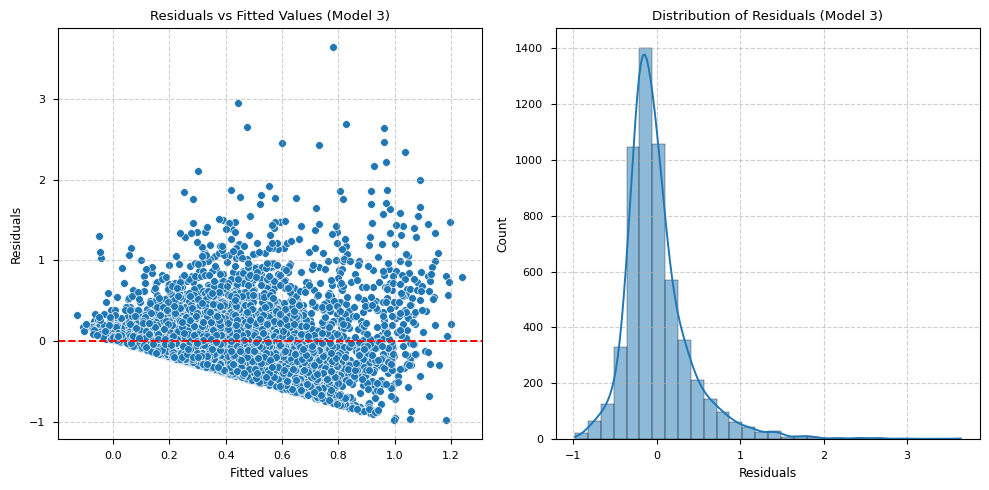

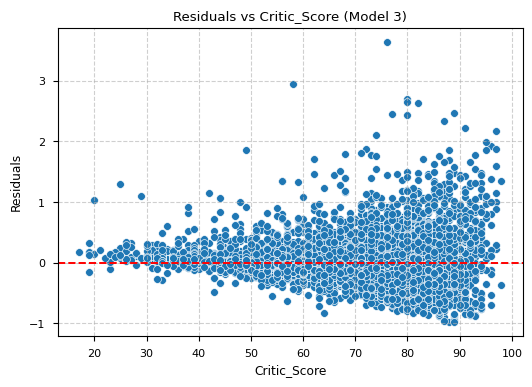

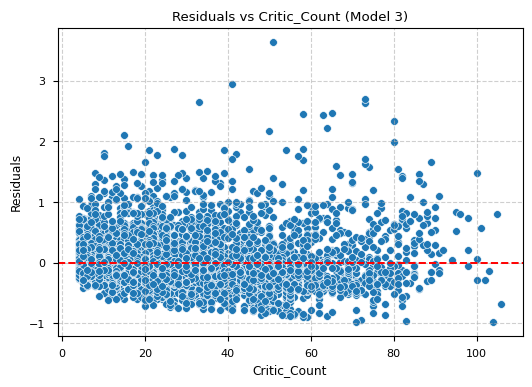

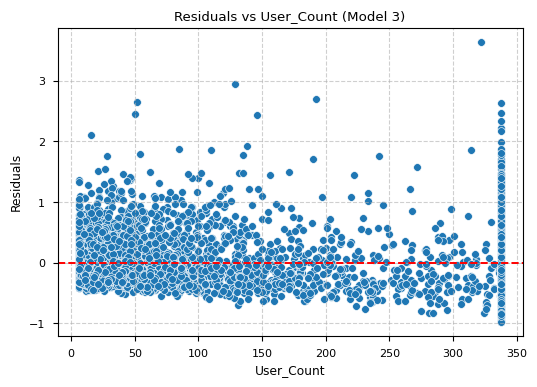

--- VIF FOR MODEL 3 ---


,Feature,VIF
0,Critic_Score,3.837231
1,Critic_Count,4.976066
2,User_Count,2.222008


<IPython.core.display.Latex object>

In [49]:
# Model 3: Without User_Score + General evaluation

X_train_no_user = X_train_winsorized.drop(columns=['User_Score'])
X_train_const_mlr3 = sm.add_constant(X_train_no_user)
model_3 = sm.OLS(Y_train_log, X_train_const_mlr3).fit()
print("--- MODEL 3 SUMMARY ---")
display(model_3.summary())

# 2. Evaluate the residuals of Model 3: residuals vs fitted values; residuals histogram; residuals vs each predictor.
residuals_mlr3 = model_3.resid
fitted_mlr3 = model_3.fittedvalues

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=fitted_mlr3, y=residuals_mlr3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Residuals vs Fitted Values (Model 3)')

plt.subplot(1, 2, 2)
sns.histplot(residuals_mlr3, bins=30, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals (Model 3)')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 1)
for column in X_train_no_user.columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_train_no_user[column], y=residuals_mlr3)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel(column)
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs {column} (Model 3)')
    plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#VIFs for Model 3
vif_data_3 = pd.DataFrame()
vif_data_3["Feature"] = X_train_no_user.columns
vif_data_3["VIF"] = [variance_inflation_factor(X_train_no_user.values, i) for i in range(X_train_no_user.shape[1])]
print("--- VIF FOR MODEL 3 ---")
display(vif_data_3)

display(Latex("Removing User_Score from the model led to a slight decrease in adjusted R² (from ≈ 0.263 to ≈ 0.262), indicating that User_Score contributed some explanatory power despite its multicollinearity with Critic_Score. The coefficients for Critic_Score, Critic_Count, and User_Count remain statistically significant, and the overall pattern of residuals is similar to Model 2. However, removing User_Score drastically reduced multicollinearity: VIF for Critic_Score dropped from ≈ 39.7 to ≈ 3.84, indicating that the instability caused by its correlation with User_Score has been resolved. This makes the coefficient estimates more reliable and interpretable." ))

--- MODEL 4 SUMMARY ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Global_Sales   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     577.5
Date:                Wed, 29 Oct 2025   Prob (F-statistic):               0.00
Time:                        10:41:05   Log-Likelihood:                -2748.4
No. Observations:                5613   AIC:                             5505.
Df Residuals:                    5609   BIC:                             5531.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0312      0.027     -1.149      0.250      -0.084       0.022
User_Score       0.0234      0.004      6.252      0.000       0.016       0.031
Critic_Count     0.0065      0.000     19.304      0.000       0.006       0.007
User_Count       0.0011   5.99e-05     18.175      0.000       0.001       0.001
==============================================================================
Omnibus:                     2276.378   Durbin-Watson:                   1.989
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            13680.680
Skew:                           1.839   Prob(JB):                         0.00
Kurtosis:                       9.706   Cond. No.                         696.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

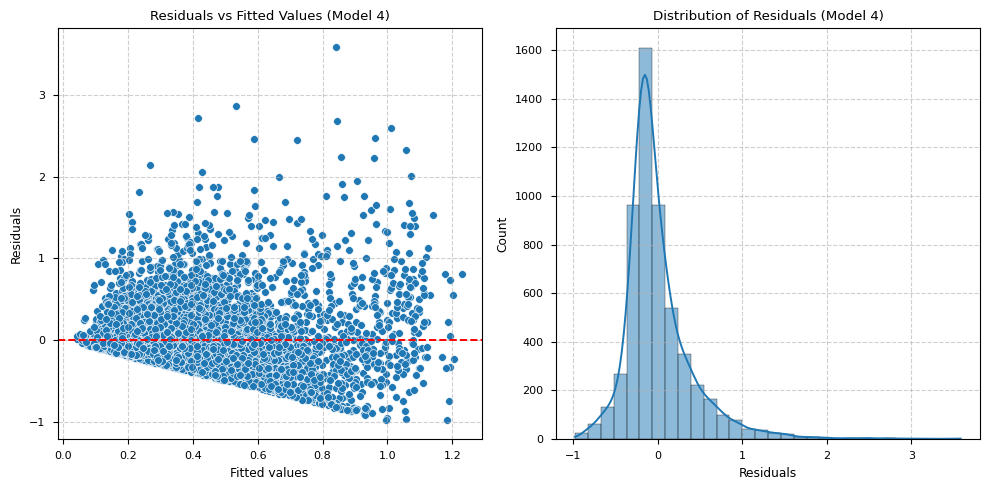

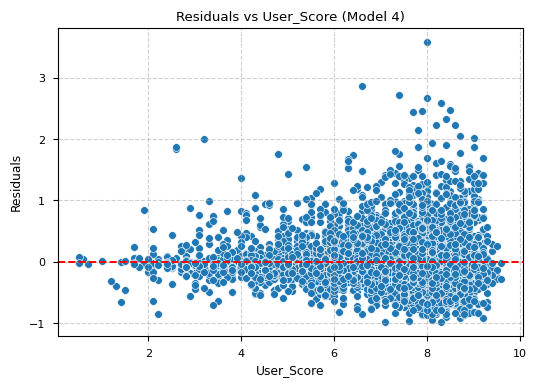

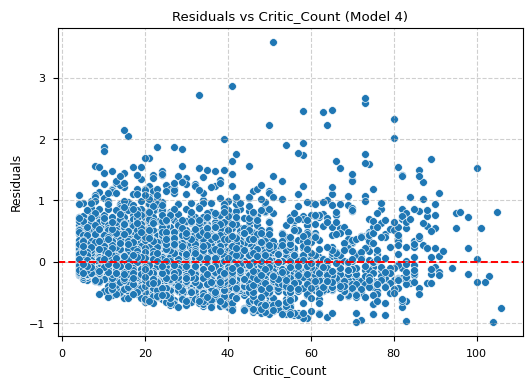

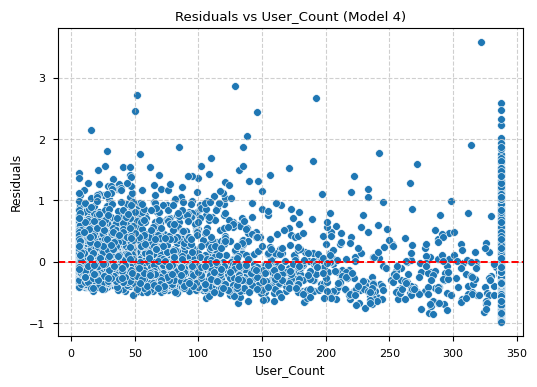

--- VIF FOR MODEL 4 ---


,Feature,VIF
0,User_Score,3.396740
1,Critic_Count,4.880116
2,User_Count,2.233898


<IPython.core.display.Latex object>

In [50]:
# Model 4: Without Critic_Score + General evaluation

X_train_winsorized = X_train_mlr.copy()
X_train_winsorized['User_Count'] = winsorize(X_train_winsorized['User_Count'], limits=[0.1, 0.1])
X_train_no_critic = X_train_winsorized.drop(columns=['Critic_Score'])
X_train_const_mlr4 = sm.add_constant(X_train_no_critic)
model_4 = sm.OLS(Y_train_log, X_train_const_mlr4).fit()
print("--- MODEL 4 SUMMARY ---")
display(model_4.summary())

# 2. Evaluate the residuals of Model 4: residuals vs fitted values; residuals histogram; residuals vs each predictor.
residuals_mlr4 = model_4.resid
fitted_mlr4 = model_4.fittedvalues
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=fitted_mlr4, y=residuals_mlr4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Residuals vs Fitted Values (Model 4)')

plt.subplot(1, 2, 2)
sns.histplot(residuals_mlr4, bins=30, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals (Model 4)')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 1)
for column in X_train_no_critic.columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_train_no_critic[column], y=residuals_mlr4)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel(column)
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs {column} (Model 4)')
    plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#VIFs for Model 4
vif_data_4 = pd.DataFrame()
vif_data_4["Feature"] = X_train_no_critic.columns
vif_data_4["VIF"] = [variance_inflation_factor(X_train_no_critic.values, i) for i in range(X_train_no_critic.shape[1])]
print("--- VIF FOR MODEL 4 ---")
display(vif_data_4)

display(Latex("Removing Critic_Score from the model resulted in a more noticeable decrease in adjusted R² (from ≈ 0.263 to ≈ 0.236), indicating that Critic_Score was a more important predictor of Global_Sales than User_Score. The coefficients for User_Score, Critic_Count, and User_Count remain statistically significant, but the overall explanatory power of the model has diminished without Critic_Score. Multicollinearity is no longer an issue: VIFs for all remaining predictors are below 5, indicating low correlation among them. However, the reduction in R² suggests that Critic_Score provided valuable information that is not fully captured by the other predictors." ))

--- MODEL 5 SUMMARY ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Global_Sales   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.249
Method:                 Least Squares   F-statistic:                     621.3
Date:                Wed, 29 Oct 2025   Prob (F-statistic):               0.00
Time:                        10:41:05   Log-Likelihood:                -2698.6
No. Observations:                5613   AIC:                             5405.
Df Residuals:                    5609   BIC:                             5432.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.2161      0.031     -7.078      0.000      -0.276      -0.156
Critic_Count          0.0060      0.000     17.837      0.000       0.005       0.007
User_Count            0.0010   5.97e-05     16.671      0.000       0.001       0.001
Score_Interaction     0.0527      0.004     11.840      0.000       0.044       0.061
==============================================================================
Omnibus:                     2268.298   Durbin-Watson:                   1.995
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            14013.809
Skew:                           1.820   Prob(JB):                         0.00
Kurtosis:                       9.831   Cond. No.                         791.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

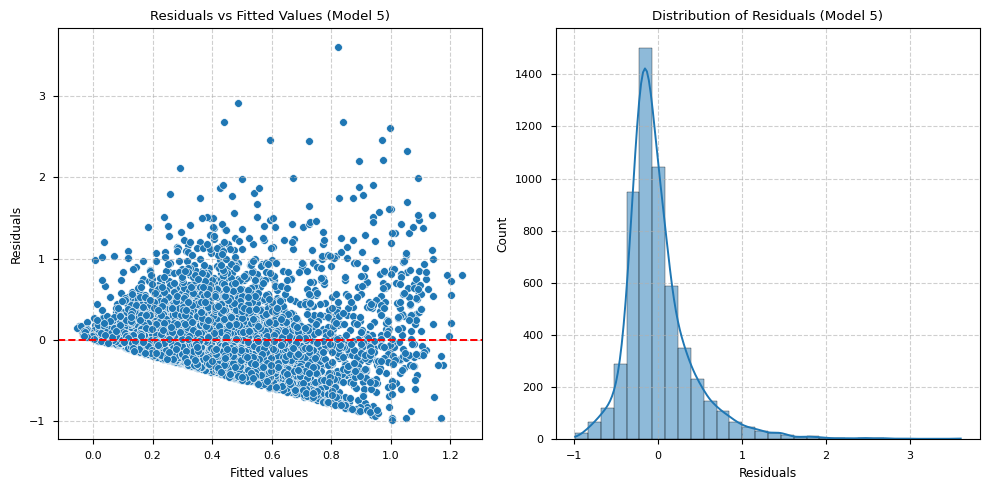

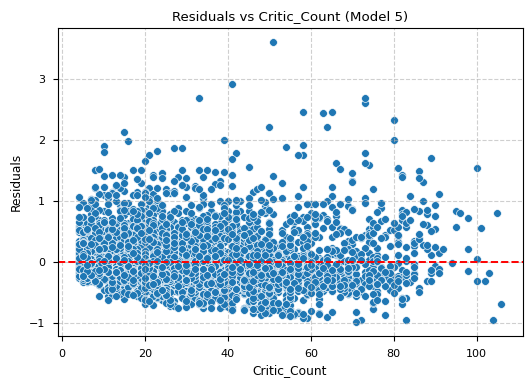

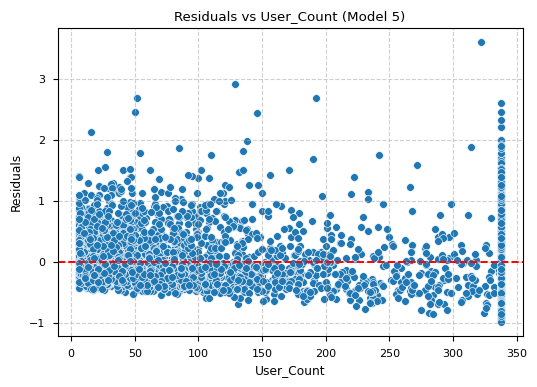

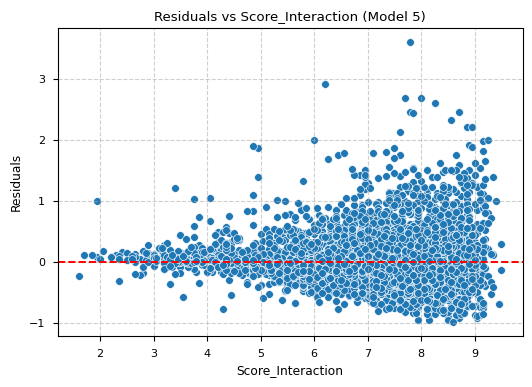

--- VIF FOR MODEL 5 ---


,Feature,VIF
0,Critic_Count,4.994500
1,User_Count,2.222873
2,Score_Interaction,3.666516


<IPython.core.display.Latex object>

In [51]:
# Model 5: Combination of Critic_Score & User_Score + General evaluation

x_train_combined = X_train_winsorized.copy()
x_train_combined['Score_Interaction'] = (((x_train_combined['Critic_Score']/10) + x_train_combined['User_Score'])/2)
x_train_combined = x_train_combined.drop(columns=['Critic_Score', 'User_Score'])
X_train_const_mlr5 = sm.add_constant(x_train_combined)
model_5 = sm.OLS(Y_train_log, X_train_const_mlr5).fit()
print("--- MODEL 5 SUMMARY ---")
display(model_5.summary())

# 2. Evaluate the residuals of Model 5: residuals vs fitted values; residuals histogram; residuals vs each predictor.
residuals_mlr5 = model_5.resid
fitted_mlr5 = model_5.fittedvalues
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=fitted_mlr5, y=residuals_mlr5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Residuals vs Fitted Values (Model 5)')

plt.subplot(1, 2, 2)
sns.histplot(residuals_mlr5, bins=30, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals (Model 5)')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 1)
for column in x_train_combined.columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=x_train_combined[column], y=residuals_mlr5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel(column)
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs {column} (Model 5)')
    plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#VIFs for Model 5
vif_data_5 = pd.DataFrame()
vif_data_5["Feature"] = x_train_combined.columns
vif_data_5["VIF"] = [variance_inflation_factor(x_train_combined.values, i) for i in range(x_train_combined.shape[1])]
print("--- VIF FOR MODEL 5 ---")
display(vif_data_5)

display(Latex("The introduction of the Score_Interaction term in Model 5 has led to a decrease in adjusted R² (from ≈ 0.263 to ≈ 0.249)," \
              "suggesting that this interaction term between Critic_Score and User_Score does not capture as much explanatory power as" \
               "having both scores separately in the model. However, the Score_Interaction term is statistically significant, indicating" \
               "that the combined effect of critics' and users' scores has some predictive value for Global_Sales. Multicollinearity has been" \
               "effectively addressed: VIFs for all predictors are below 5, indicating low correlation among them. Overall, while Model 5 simplifies" \
               "the representation of scores and reduces multicollinearity, it sacrifices some explanatory power compared to Model 3. Therefore," \
                "Model 3 remains the preferred choice for predicting Global_Sales due to its higher R² and better fit to the data." ))

In [52]:
# Final Model Evaluation on Test Set (Model 3) (Scikit-Learn)
#X_train_mlr, X_test_mlr, Y_train_mlr, Y_test_mlr

Y_test_log = np.log1p(Y_test_mlr)
X_test_winsorized = X_test_mlr.copy()
X_test_winsorized['User_Count'] = winsorize(X_test_winsorized['User_Count'], limits=[0.1, 0.1])
X_test = X_test_winsorized.drop(columns=['User_Score'])
X_train_const_mlr3 = X_train_const_mlr3.drop(columns=['const'])

model_mlr_final = LinearRegression()
model_mlr_final.fit(X_train_const_mlr3, Y_train_log)

Y_pred_mlr_final = model_mlr_final.predict(X_test)
mse_mlr_final = mean_squared_error(Y_test_log, Y_pred_mlr_final)
rmse_mlr_final = np.sqrt(mse_mlr_final)
r2_mlr_final = r2_score(Y_test_log, Y_pred_mlr_final)

display(Latex(fr"The final multiple linear regression model (Model 3) evaluated on the test set achieved a Root Mean Squared Error (RMSE) of {rmse_mlr_final:.2f} on the log-transformed Global_Sales. " \
              fr"This indicates that on average, the model's predictions deviate from the actual log(Global_Sales + 1) values by about {rmse_mlr_final:.2f}. The $R^2$ score on the test set is {r2_mlr_final:.2f}, suggesting that the model explains approximately {r2_mlr_final*100:.2f}\% of the variance in log(Global_Sales + 1) for unseen data. " \
              fr"This is a higher performance compared to the training set. While this performance is reasonable, it also indicates that there is room for improvement, potentially by incorporating additional predictors or exploring non-linear modeling techniques. Overall, we were able to develop a much better model, since our previous adjusted R² " \
              fr"for the first model was about $\approx$ 0.11." ))


<IPython.core.display.Latex object>

**NOTE:** The models that we've built as a tool for PREDICTION all FAILED. The majority of the data could not be explained by the features we had available. However, as a tool for INFERENCE and DIAGNOSTICS, they were extremely useful to understand the relationships between variables and identify key factors that influence sales.



**Decision Flowchart for Regression**

Below is a flowchart to help decide which regression technique to use based on the characteristics of your data and research questions.

![Regression Flowchart](/home/lucas/stats_for_data_science/images/Regression_Flowchart.png)

#### **1.2.2 Classification:**

Classification models are a type of supervised learning model whose **goal** is to assign inputs to **discrete categories** or labels, for example, determining whether an email is spam or not spam. These models learn from labeled training data, where the correct category is known, and then use this knowledge to classify new, unseen data. Common classification algorithms include Logistic Regression, Decision Trees and Random Forests. 

##### **1.2.2.1 Logistic Regression**


**Likelihood and Maximum Likelihood Estimation (MLE)**

In the previous sections, we explored the concept of probability distribution functions, whose area under the curve quantifies the probability of observing a certain outcome given a set of parameters. The **likelihood** is the value of a point in the pdf function. It doesn't have an absolute meaning, but it can be used to compare different models. The goal of the likelihood is to answer the question: "Given the observed data, which model turns the observed data 'more dense' (more plausible/likely)?". For example, suppose we have two normal distributions. The first with $\mu = 2.5$ and $\sigma = 1$, and the second with $\mu = 4$ and $\sigma = 1$. If we observe a data point $x = 3$, we can calculate the likelihood of observing this data point under each distribution. The likelihoods are:

- For the first distribution: $\mathcal{L}_1 (\mu=2.5, \sigma=1| X=3) = f(\mu=2.5, \sigma=1| X=3) \approx 0.35$

- For the second distribution: $\mathcal{L}_2 (\mu=4, \sigma=1| X=3) = f(\mu=4, \sigma=1| X=3) \approx 0.24$

Given that $\mathcal{L}_1 > \mathcal{L}_2$, we can conclude that the first distribution is more likely to have generated the observed data point, because it assigns a higher probability density to it.

Now, consider that we have a dataset with multiple observations, and we want to find the **parameters** of a model that best explain the data. The **Maximum Likelihood Estimation (MLE)** is a method used to estimate the parameters of a statistical model by maximizing the likelihood function. In other words, MLE finds the parameter values that make the observed data most probable under the assumed model (it gives the best fit to the data). Example: Suppose we have a dataset of heights of individuals, and we want to estimate the mean ($\mu$) and standard deviation ($\sigma$) of the population from which the data was drawn. We assumed a gaussian model. We can use MLE to find the values of $\mu$ and $\sigma$ that maximize the likelihood of observing the given heights. The likelihood for the first and second points are given by the normal distribution formula:

- $ \mathcal{L}(\mu, \sigma| X=x_1) = f(\mu, \sigma| X=x_1) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{(x_1 - \mu)^2}{2\sigma^2}} $
- $ \mathcal{L}(\mu, \sigma| X=x_2) = f(\mu, \sigma| X=x_2) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{(x_2 - \mu)^2}{2\sigma^2}} $

However what is the likelihood of this normal curve given $x_1$ and $x_2$? Since the observations are independent, the overall likelihood is the product of the individual likelihoods:

- $ \mathcal{L}(\mu, \sigma| X=x_1, X=x_2) = \mathcal{L}(\mu, \sigma|X=x_1) * \mathcal{L}(\mu, \sigma|X=x_2) = f(\mu, \sigma| X=x_1) * f(\mu, \sigma| X=x_2) $

Our best estimates for $\mu$ and $\sigma$ are the values that maximize this overall likelihood function for all observed data points. Mathematically, we can express this as:

- $ \boxed{ (\hat{\mu}, \hat{\sigma}) = \arg \max_{\mu, \sigma} \prod_{i=1}^{n} \mathcal{L}(\mu, \sigma|X=x_1,x_2,...,x_n) = \arg \max_{\mu, \sigma} \prod_{i=1}^{n} f(x_i) } $

where:

- **$\hat{\mu}, \hat{\sigma}$** are the MLE estimates for the parameters.
- **$n$** is the number of observations.
- **$f(x_i)$** is the probability density function evaluated at each observation $x_i$ given the parameters $\mu$ and $\sigma$.

Unfortunately, maximizing the likelihood function directly can be computationally challenging, especially when dealing with products of many probabilities, because the values become *very* small. To simplify the optimization process, we often work with the **log-likelihood**, which is the natural logarithm of the likelihood function. The log-likelihood transforms products into sums. The MLE estimates can then be found by maximizing the log-likelihood function:

- $ \boxed{ (\hat{\mu}, \hat{\sigma}) = \arg \max_{\mu, \sigma} \log \mathcal{L}(\mu, \sigma|X=x_1,x_2,...,x_n) = \arg \max_{\mu, \sigma} \sum_{i=1}^{n} \log f(x_i) } $

To find the parameter estimates that maximize the log-likelihood, we can take the partial derivatives of the log-likelihood function with respect to the parameters, set the equations to zero, and solve it.

**Logistic Regression Algorithm**

Logistic Regression is a statistical method used for binary classification problems, where the goal is to predict the probability of an instance belonging to one of two classes (e.g., success/failure, yes/no, 1/0). Unlike linear regression, which predicts continuous outcomes, logistic regression predicts categorical outcomes by attributing probabilities to each class using the logistic (sigmoid) function, defined as $\sigma(z) = \frac{1}{1 + e^{-z}}$. The output of the logistic function is a value between 0 and 1, which can be interpreted as the probability of the instance belonging to the positive class. A threshold is then applied to make the final classification decision. For example, suppose we want to know the relationship between hours of study and passing an exam (pass/fail). The outcome variable is binary (pass or fail). If we apply a simple linear regression, we might get predictions outside the range of 0 to 1, which is not meaningful, i.e doesnt make any sense. However, with logistic regression, we can model the probability of passing the exam as a function of hours studied, ensuring that our predictions remain within the valid range of 0 to 1. The logistic regression model can be expressed mathematically as:

##### $$ \boxed{ P(Y=1|X) = \frac{1}{1+e^{-z}} =\frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_k X_k)}} } $$

where:

- **$P(Y=1|X)$** is the probability of the positive class given the input features.

- **$e$** is the base of the natural logarithm.

- **$\beta_0$** is the intercept term.

- **$\beta_1, \beta_2, ..., \beta_k$** are the coefficients for the input features $X_1, X_2, ..., X_k$.

Just like in linear regression, our goal is to estimate the coefficients ($\beta_0, \beta_1, ..., \beta_k$) that best fit the data. However, instead of minimizing the sum of squared residuals, logistic regression uses a method called **Maximum Likelihood Estimation (MLE)** to find the coefficients that maximize the likelihood of observing the given data. The likelihood function for logistic regression can be thought as a bernoulli distribution. For a single observation, the likelihood of observing the outcome $Y_i$ given the input features $X_i$ is:

- If $Y_i = 1$ (positive class): $P_i$

- If $Y_i = 0$ (negative class): $1 - P_i$

In our example, this means that if a student passed the exam ($Y_i = 1$), the likelihood of this outcome is given by the predicted probability of passing based on their hours of study. Conversely, if a student failed the exam ($Y_i = 0$), the likelihood is given by one minus the predicted probability of passing. Therefore, the likelihood for a single observation can be expressed as:

- $ \boxed{ P_i^{Y_i} (1 - P_i)^{1 - Y_i} } $

For a dataset with $n$ observations, the overall likelihood function is the product of the individual likelihoods for each observation:

- $ \boxed{ \ell_i = \prod_{i=1}^{n} P_i^{Y_i} (1 - P_i)^{1 - Y_i} } $

where:

- **$n$** is the number of observations.

- **$Y_i$** is the observed class label for observation $i$ (0 or 1).

- **$P_i$** is the predicted probability of the positive class for observation $i$ given the input features $X_i$.

Now, our goal is to find the coefficients ($\beta_0, \beta_1, ..., \beta_k$) that maximize this likelihood function. However, maximizing the likelihood directly can be mathematically challenging, so we often work with the **log-likelihood**, which is the natural logarithm of the likelihood function. Maximizing the log-likelihood is often more convenient than maximizing the likelihood itself, and the two approaches yield the same estimates for the coefficients. However, maximizing the log-likelihood is the same as minimizing the negative of the log-likelihood. Therefore, the optimization problem can be expressed as:

- $ \boxed{  -\log \mathcal{L} = -\sum_{i=1}^{n} \left[ Y_i \log P_i + (1 - Y_i) \log (1 - P_i) \right] } $

where:

- $P_i = \frac{1}{1 + e^{-z}} \longrightarrow log(P_i) = -\log(1 + e^{-z})$

- $(1 - P_i) = \frac{e^{-z}}{1 + e^{-z}} = \frac{1}{1 + e^{z}} \longrightarrow log(1 - P_i) = -z - \log(1 + e^{-z})$

- for a single observation, the negative log-likelihood becomes: $\ell_i = \log(1 + e^{z}) - Y_i z.$

Previously, we saw that in linear regression, we minimized the sum of squared residuals to find the best-fitting line, by derivating the error function with respect to the coefficients and setting the derivatives to zero. In logistic regression, we minimize the negative log-likelihood function using numerical optimization techniques, the most common being **Gradient Descent**. The gradient descent algorithm takes the following steps:

1. **Initialization:** Start with initial guesses for the coefficients ($\beta_0, \beta_1, ..., \beta_k$), often set to zero or small random values.

2. **Compute Predictions:** For each observation, calculate the predicted probabilities using the logistic function with the current coefficients.

3. **Calculate Gradient:** Compute the gradient of the negative log-likelihood function with respect to each coefficient. The gradient indicates the *direction* and *magnitude* of change needed to reduce the negative log-likelihood. Mathematically, the gradient for each coefficient $\beta_j$ can be expressed as:

- $ \frac{\partial (-\log \mathcal{L})}{\partial \beta_j} = \sum_{i=1}^{n} (P_i - Y_i) X_{ij}  $

4. **Update Coefficients:** Adjust the coefficients in the direction opposite to the gradient, scaled by a learning rate ($\alpha$), which controls the step size of each update. The update rule for each coefficient $\beta_j$ is:

- $ \beta_j \leftarrow \beta_j - \alpha \frac{\partial (-\log \mathcal{L})}{\partial \beta_j} $

5. **Iterate:** Repeat steps 2-4 until convergence, which occurs when the change in the negative log-likelihood or the coefficients is below a predefined threshold, or after a fixed number of iterations. The ideal is to reach zero gradient, indicating that we have found the optimal coefficients that maximize the likelihood of the observed data.

It can be thought as finding the lowest point on a hill (minimum of negative log-likelihood) by taking steps in the steepest downward direction (opposite to the gradient). 

After finding the optimal coefficients, we now have to check how well our logistic regression model performs. This is typically done using various evaluation metrics.

**Evaluation Metrics for Logistic Regression**

To evaluate the performance of a logistic regression model, we can use several metrics that assess how well the model classifies instances into the correct categories. Some common evaluation metrics include:

- **Accuracy:** The proportion of correctly classified instances out of the total instances. It is calculated as:

  $ \boxed{ \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} } $

  where:
  
  - **TP** = True Positives (correctly predicted positive instances)
  
  - **TN** = True Negatives (correctly predicted negative instances)
  
  - **FP** = False Positives (incorrectly predicted positive instances)
  
  - **FN** = False Negatives (incorrectly predicted negative instances)

  We can put all these values in a *confusion matrix*, where the rows represent the actual classes and the columns represent the predicted classes:

  $$
  \begin{array}{|c|c|c|}
  \hline
  \text{Actual $\backslash$ Predicted} & \text{Predicted Positive} & \text{Predicted Negative} \\
  \hline
  \text{Actual Positive} & TP & FN \\
  \hline
  \text{Actual Negative} & FP & TN \\
  \hline
  \end{array}
  
  \longrightarrow

 
    \begin{pmatrix}
    \text{TP} & \text{FN} \\
    \text{FP} & \text{TN}
    \end{pmatrix}



$$

The values in the confusion matrix help us understand the types of errors our model is making. By analyzing the counts of TP, TN, FP, and FN, we can gain insights into the model's performance and identify areas for improvement. 

- **Precision:** The proportion of true positive predictions out of all positive predictions made by the model. It is calculated as:

  $ \boxed{ \frac{TP}{TP + FP} } $

- **Recall (Sensitivity):** The proportion of true positive predictions out of all actual positive instances. It is calculated as:

  $ \boxed{ \frac{TP}{TP + FN} } $

- **F1 Score:** The harmonic mean of precision and recall, providing a single metric that balances both. It is calculated as:

  $ \boxed{2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} } $

- **Specificity:** The proportion of true negative predictions out of all actual negative instances. It is calculated as:

  $ \boxed{  \frac{TN}{TN + FP} } $

- **ROC Curve:** The Receiver Operating Characteristic (ROC) curve plots the sensitivity (true positive rate) against false positive rate (also defined as 1-specificity) at all threshold values. Ideally, we want a curve that hugs the top-left corner of the plot, indicating high sensitivity and low false positive rate. 

- **AUC (Area Under the Curve):** The AUC is the area under the ROC curve. It quantifies the overall ability of the model to discriminate between positive and negative classes. An AUC of 1 indicates perfect discrimination, while an AUC of 0.5 suggests no discrimination (random guessing). A good model typically has an AUC greater than 0.7.


**Odds and Log-Odds**

Odds represent the ratio of the probability of an event occurring to the probability of it not occurring. For example, if the probability of an event happening is 0.8 (80%), the odds of the event occurring are calculated as:

- $  \text{Odds} = \frac{P(\text{event})}{1 - P(\text{event})} = \frac{0.8}{0.2} = 4 $

This means that the event is 4 times more likely to occur than not occur.

Odds ratios (OR) are used to compare the odds of an event occurring in one group to the odds of it occurring in another group. An OR greater than 1 indicates that the event is more likely to occur in the first group compared to the second group, while an OR less than 1 indicates that the event is less likely to occur in the first group. For example, if the odds of success in group A are 4 and the odds of success in group B are 2, the odds ratio is calculated as:

- $  \text{OR} = \frac{\text{Odds in group A}}{\text{Odds in group B}} = \frac{4}{2} = 2 $

This means that the odds of success in group A are 2 times higher than in group B.

Log-odds, also known as the logit function, is the natural logarithm of the odds ratios. Mathematically, log-odds is calculated as:

- $  \text{Log-Odds} = \log\left(\frac{P(\text{event})}{1 - P(\text{event})}\right) $

Log-odds are useful in logistic regression because they allow us to model the relationship between the independent variables and the log-odds of the dependent variable. For instance, if we look at the logistic regression equation, it represents P. If we calculate the log-odds, we get: 

- $  \text{Log-Odds} = \log\left(\frac{p}{1 - p}\right) = \log (e^{z}) = z$

Therefore, the odds (ratio between the chance of $y=1$ and the chance of $y=0$) are given by $e^{z}$, and the log-odds are given by $z = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_k X_k$. The **coefficients** in a logistic regression model represent the **change in log-odds for a one-unit increase in the corresponding independent variable**, holding all other variables constant. This interpretation is particularly useful for understanding the impact of each predictor on the likelihood of the outcome occurring.

**Example:** Our linear regression models to predict *Global_Sales* were unsatisfactory. Let's switch to a classification problem: can we predict whether a game will be a 'Hit'? Use the previous final model features' to create a binary target variable ('Hit' if sales > 1 million). Build a logistic regression model using the same features as before to predict this new target variable. Evaluate its performance using accuracy, precision, recall and ROC-AUC.


/tmp/ipykernel_13317/1163081358.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_lr['User_Count'] = winsorize(X_lr['User_Count'], limits=[0.1, 0.1])


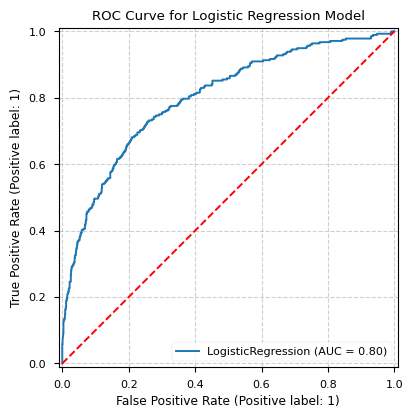

Optimization terminated successfully.
         Current function value: 0.389525
         Iterations 7
--- LOGISTIC REGRESSION MODEL SUMMARY ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 is_hit   No. Observations:                 5613
Model:                          Logit   Df Residuals:                     5609
Method:                           MLE   Df Model:                            3
Date:                Wed, 29 Oct 2025   Pseudo R-squ.:                  0.1939
Time:                        10:41:06   Log-Likelihood:                -2186.4
converged:                       True   LL-Null:                       -2712.5
Covariance Type:            nonrobust   LLR p-value:                8.894e-228
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -6.8348      0.308    -22.169      0.000      -7.439      -6.231
Critic_Score     0.0575      0.004     13.967      0.000       0.049       0.066
Critic_Count     0.0243      0.002     11.124      0.000       0.020       0.029
User_Count       0.0028      0.000      7.897      0.000       0.002       0.004
================================================================================
"""

array([[1088,   40],
       [ 193,   83]])

<IPython.core.display.Latex object>

In [53]:
# We will be using the final model from our previous analysis (Model 3) to make predictions.

df_lr = pd.read_csv('../data/Video_Games_Sales.csv')
data_lr = df_lr[['Critic_Score', 'User_Score', 'Global_Sales', 'Critic_Count', 'User_Count']]
data_lr = pd.to_numeric(data_lr.stack(), errors='coerce').unstack() # Convert all columns to numeric, setting errors to NaN
data_lr = data_lr.dropna() # Drop rows with any NaN values
data_lr['is_hit'] = np.where(data_lr['Global_Sales'] >= 1.0, 1, 0) # Define hit games as those with Global_Sales greater than 1 million

# Prepare the features and target variable
X_lr = data_lr[['Critic_Score', 'User_Score', 'Critic_Count', 'User_Count']]
Y_lr = pd.Series(data_lr['is_hit'])

# Apply winsorization to User_Count; drop User_Score; 
X_lr['User_Count'] = winsorize(X_lr['User_Count'], limits=[0.1, 0.1])
X_lr_final = X_lr.drop(columns=['User_Score'])

# Split the data into training and testing sets
X_train_lr, X_test_lr, Y_train_lr, Y_test_lr = train_test_split(X_lr_final, Y_lr, test_size=0.2, random_state=42)

# Build and train the logistic regression model
model_logreg = LogisticRegression(max_iter=1000)
model_logreg.fit(X_train_lr, Y_train_lr)

# Make predictions on the test set
Y_pred_lr = model_logreg.predict(X_test_lr)

# Evaluate the model's performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

accuracy = accuracy_score(Y_test_lr, Y_pred_lr)
precision = precision_score(Y_test_lr, Y_pred_lr)
recall = recall_score(Y_test_lr, Y_pred_lr)
conf_matrix = confusion_matrix(Y_test_lr, Y_pred_lr) # WARNING THE CONF. MATRIX OUTPUT IN SCIKIT-LEARN IS [[TN, FP],[FN, TP]]

# plot the Roc/ AOC curves
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model_logreg, X_test_lr, Y_test_lr)
plt.title('ROC Curve for Logistic Regression Model')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# p-value for the logistic regression coefficients
import statsmodels.api as sm
X_train_lr_const = sm.add_constant(X_train_lr)
logit_model = sm.Logit(Y_train_lr, X_train_lr_const)
result_lr = logit_model.fit()
print("--- LOGISTIC REGRESSION MODEL SUMMARY ---")
display(result_lr.summary())
display(conf_matrix)
display(Latex(fr"The model achieves an accuracy of {accuracy*100:.2f}\%, meaning that in about 83.4% of cases it correctly classifies "\
              fr"whether a game is a hit or not. However, precision is {precision*100:.2f}% (roughly one third of predicted “hits” are false positives)," \
              fr"and recall is only {recall*100:.2f}% (the model detects only ~30% of the true hits). The ROC AUC is 0.80, which indicates decent " \
              fr"discriminative power. All predictors are statistically significant $(p < 0.05)$, and Critic_Score appears as the strongest predictor" \
              fr"on the log-odds scale: its coefficient is 0.0575, so each additional point in Critic_Score increases the odds of being a hit by ≈ 5.9%" \
              fr"(exp(0.0575) ≈ 1.059). *Critic_Count* and *User_Count* have smaller but positive effects (≈ 2.5% and ≈ 0.28% increase in odds per unit," \
              fr" respectively). Overall, the model is **useful but limited** — it discriminates better than random, but it misses many hits (low recall)." \
              fr" We could consider adjusting the decision threshold to increase recall if catching hits is a priority."))




##### **1.2.2.2 Decision Trees**

Decision Trees are a type of supervised learning algorithm used for both classification and regression tasks. Classification trees are used when the target variable is categorical, while regression trees are used when the target variable is continuous. However, it's possible to have mixed trees. In simple terms, a decision tree is a flowchart of questions about the features of the data, that works by splitting the data into subsets based on the values of the input features. The **goal** is to create a model that predicts the target variable by learning simple decision rules ("Yes/No") inferred from the data features, until a stopping criterion is met. They are easy to interpret and visualize, making them popular for various applications, such as customer segmentation, fraud detection, and medical diagnosis. But they are not good for quantifying the impact of each feature on the target variable. The structure of a decision tree consists of: 

1. **Root Node**: The top node represents the entire dataset, which gets split into two or more homogeneous sets.
2. **Decision Nodes**: These are the nodes that split the data based on certain conditions (features).
3. **Leaf/Terminal Nodes**: These nodes represent the final output or decision of the tree. In classification trees, leaf nodes correspond to class labels, while in regression trees, they represent predicted continuous values.
4. **Branches**: These are the connections between nodes that represent the flow from one node to another based on the decision rules.


An example of a decision tree for classification could be predicting if a person will play tennis based on weather conditions. If we look at this data-table: 

| Weather  | Wind   | Play?  |
|----------|--------|--------|
| Sunny    | Weak   | Yes    |
| Sunny    | Strong | No     |
| Cloudy   | Weak   | Yes    |
| Rainy    | Weak   | No     |


We could build a decision tree that first splits on the "Wind" feature, then on the "Weather" feature, to predict whether a person will play tennis. It would look something like this:

![Decision_Tree](/home/lucas/stats_for_data_science/images/Decision_Tree_Example.png)


**Note:** trees can split categorical features in different ways. Some implementations (and many textbooks for simplicity) illustrate *multi-way* splits (one branch per category), while most machine-learning libraries (e.g., scikit-learn) use **binary splits** that partition categories into two groups (e.g., *Sunny* vs *Not Sunny*). The number of final leaves depends on this choice — both tree shapes are valid depending on the splitting rule used.


**Building a Decision Tree**

When building a decision tree, the most important step is to decide which feature to split on at each node, i.e, which question to ask. In order to 'learn' what is the best possible sequence of questions, the algorithm relies on mathematical tools. In our case, we will use the **Gini Index** for **classification** trees and the **Mean Squared Error** (MSE) for **regression** trees.

- **Gini Index (for Classification Trees)**: The Gini Index measures the impurity of a dataset. A Gini Index of 0 indicates perfect purity (all samples belong to a single class), while a Gini Index of 0.5 indicates maximum impurity (in the binary case). If we look at our example, we have 3 leaves: the first one comes from the answer 'strong' after the question 'wind', the second and third ones come from the answers 'sunny' and 'rainy/cloudy' after the question 'weather'. Those with a single answer, i.e, the first and second leaves, have a Gini Index of 0 (pure). The third leaf has a Gini Index of 0.5, since it contains one 'yes' and one 'no'. 

    The Gini Index is calculated as:

    $ \boxed{ Gini = 1 - \sum_{i=1}^{C} p_i^2 } $

    where:

    - **$C$** is the number of classes.
    - **$p_i$** is the proportion of instances belonging to class $i$ in the dataset.

    In our example, the Gini Index for the third leaf (with one 'yes' and one 'no') would be:

    $ Gini = 1 - (0.5^2 + 0.5^2) = 0.5 $, since we have 2 classes (yes/no) and each class has a proportion of 0.5 (1 'Yes' and 1 'No').

    The Average Gini Index after a split is calculated as:

    $ \boxed{ Gini_{split} = \frac{n_{left}}{n_{total}} Gini_{left} + \frac{n_{right}}{n_{total}} Gini_{right} } $

    where:

    - **$n_{left}$** and **$n_{right}$** are the number of instances in the left and right child nodes after the split.
    - **$n_{total}$** is the total number of instances in the parent node.
    - **$Gini_{left}$** and **$Gini_{right}$** are the Gini Indices of the left and right child nodes.

    In our example, the average Gini Index after the split on 'wind' would be:

    $ Gini_{split} = \frac{2}{4} \cdot 0 + \frac{2}{4} \cdot 0.5 = 0.25 $

    After collecting the Gini Indices for all possible splits, the algorithm selects the feature (i.e, question related to the data, in this case 'wind') and threshold that results in the **lowest** average Gini Index, indicating the most effective split in terms of class purity. In simple terms, the algorithm looks for the question that best separates the classes, producing the most homogeneous (pure) child nodes. The algorithm continues this process recursively, until it finds the best splits for all nodes. The order of questions with the lowest Gini Indices will form the structure of the decision tree. In our case, the algorithm would change the final node, and put 'cloudy' and 'sunny' in the same leaf, and cloudy in a another leaf, since that would produce two pure leaves (Gini Index = 0).

- **Mean Squared Error (for Regression Trees)**: In regression trees, our variables are numeric, therefore the **goal** is to *minimize* the **variance** within each leaf node. The Mean Squared Error (MSE) is used as a measure of impurity for regression tasks. It calculates the average squared difference between the actual values and the predicted values (mean of the target variable in that node). The MSE is calculated as:

    $ \boxed{ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y})^2 } $

    where:

    - **$n$** is the number of instances in the dataset.
    - **$y_i$** is the actual value of the target variable for instance $i$.
    - **$\hat{y}$** is the predicted value (mean of the target variable) for the instances in the node.

    When building a regression tree, the algorithm evaluates all possible splits for each feature and calculates the MSE for each split. The split that results in the lowest MSE is selected as the best split for that node. The questions, however, are not binary (yes/no), but rather "Is feature X less than or equal to value V?". The leaf in this case will contain the mean of the target variable for all instances that reach that leaf. 


**Overfitting and Pruning**

Since the tree algorithm works recursively, it will continue splitting the data until it asks all possible questions or reaches only leaf nodes with a single observation. As a result, it can create very deep trees that perfectly fit the **training** data, but **fail** to generalize to new, unseen data (overfitting). To prevent overfitting, we can use a technique called **pruning**, which involves removing branches of the tree that do not provide significant predictive power. Pruning can be done in two ways:

1. **Pre-pruning**: This technique stops the tree from growing when it reaches a certain depth or when the improvement in the impurity measure (e.g., Gini Index or MSE) is below a threshold. By halting the growth of the tree early, we can prevent it from becoming too complex and overfitting the training data. We can set parameters such as maximum depth, minimum samples per leaf, or minimum impurity decrease to control the growth of the tree. The first one impacts the number of questions the tree can ask, while the second and third ones ensure that each leaf has enough data points to make reliable predictions (nobody wants a data split where a father node has 1000 instances and the two children have 997 and 3).

2. **Post-pruning**: This technique involves growing the full tree and then **manually** removing branches that do not contribute significantly to the model's performance. The idea is to evaluate the performance of the tree on unseen data and prune branches that lead to overfitting. This can be done by calculating the error rate on a validation set and removing branches that do not improve the model's performance. However, for doing this, the original dataset needs to be split into *training, validation and testing sets*. The training set is used to build the tree, the validation set is used to evaluate the performance of the tree and prune branches, and the testing set is used to assess the final performance of the pruned tree. 

**Evaluation Metrics for Decision Trees**

To evaluate the performance of decision tree models, we can use various metrics depending on whether we are dealing with classification or regression tasks. For classification trees, common evaluation metrics include:

- **For Classification Trees:**

  - **Confusion Matrix:** in this case, the confusion matrix positive and negative classes will depend on the specific problem being solved. In our example, positive could be 'Play' = Yes, and negative 'Play' = No. To build the confusion matrix, we need to compare the predicted classes from the decision tree with the actual classes in the *test* dataset. The confusion matrix will help us understand how well the decision tree is performing in terms of true positives, true negatives, false positives, and false negatives. In the decision tree that we build, we have 4 rules (leaves): 

    - If Wind = Strong -> Predict = No
    - If Wind = Weak and Weather = Sunny -> Predict = Yes
    - If Wind = Weak and Weather = Rainy -> Predict = No
    - If Wind = Weak and Weather = Cloudy -> Predict = Yes

    We should apply those rules to the test dataset and count the number of TP, TN, FP, FN to fill the confusion matrix. After that, we can determine: Accuracy, Precision, Recall, ROC Curve and AUC (as explained in the Logistic Regression section).


- **For Regression Trees:**

  - Mean Squared Error (MSE) and Root Mean Squared Error (RMSE): These metrics measure the average squared difference between the actual and predicted values. RMSE is simply the square root of MSE, providing an error metric in the same units as the target variable. They are calculated as:

    $ \boxed{ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 } $

    $ \boxed{ RMSE = \sqrt{MSE} } $

    where:

    - **$n$** is the number of instances in the dataset.
    - **$y_i$** is the actual value of the target variable for instance $i$.
    - **$\hat{y}_i$** is the predicted value for instance $i$.

    Consider a decision tree regression model that predicts house prices based on features such as size, number of bedrooms, and location. After training the model learns that if the area is greater than $100m^2$ it predicts a price of $300,000$, otherwise it predicts $150,000$ (both values being the average of big/small houses in the training set). Then, we would evaluate the model by taking a test set of houses with known prices ($y_i$), applying the decision tree to predict prices ($\hat{y}_i$), and calculating the MSE and RMSE between the predicted prices and the actual prices. In order to have a good model, we want those values to be as low as possible, indicating that the predicted prices are close to the actual prices. The RMSE value should always be less than the standard deviation of the target variable in the dataset (RMSE < $\sigma(y_i)$), if not the model is useless. Another tool is the coefficient of variation of the RMSE (CVRMSE), which is calculated as: 

    - $ \boxed{ CVRMSE = \frac{RMSE}{\bar{y}} \times 100 } $

    It returns a percentage value that indicates the size of the error relative to the mean of the target variable. The rule of thumb for CVRMSE is: 

      - CVRMSE < 10%: Excellent model
      - 10% ≤ CVRMSE < 20%: Good model
      - 20% ≤ CVRMSE < 30%: Fair model
      - CVRMSE ≥ 30%: Poor model

- **Example:** Our Logistic Regression model provided decent accuracy (83.4%) but suffered from very low Recall (~30.1%), failing to identify most of the true 'Hits'. This suggests a linear model may be insufficient to capture the underlying patterns. Can a non-linear Decision Tree provide a better balance of Precision and Recall? Build a Decision Tree Classifier using the same features as before to predict the 'Hit' target variable. Evaluate its performance using a confusion matrix, accuracy, precision, recall, and ROC-AUC.

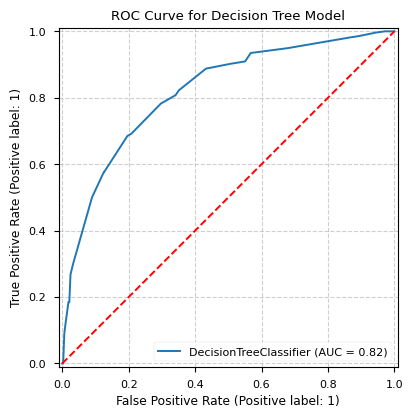

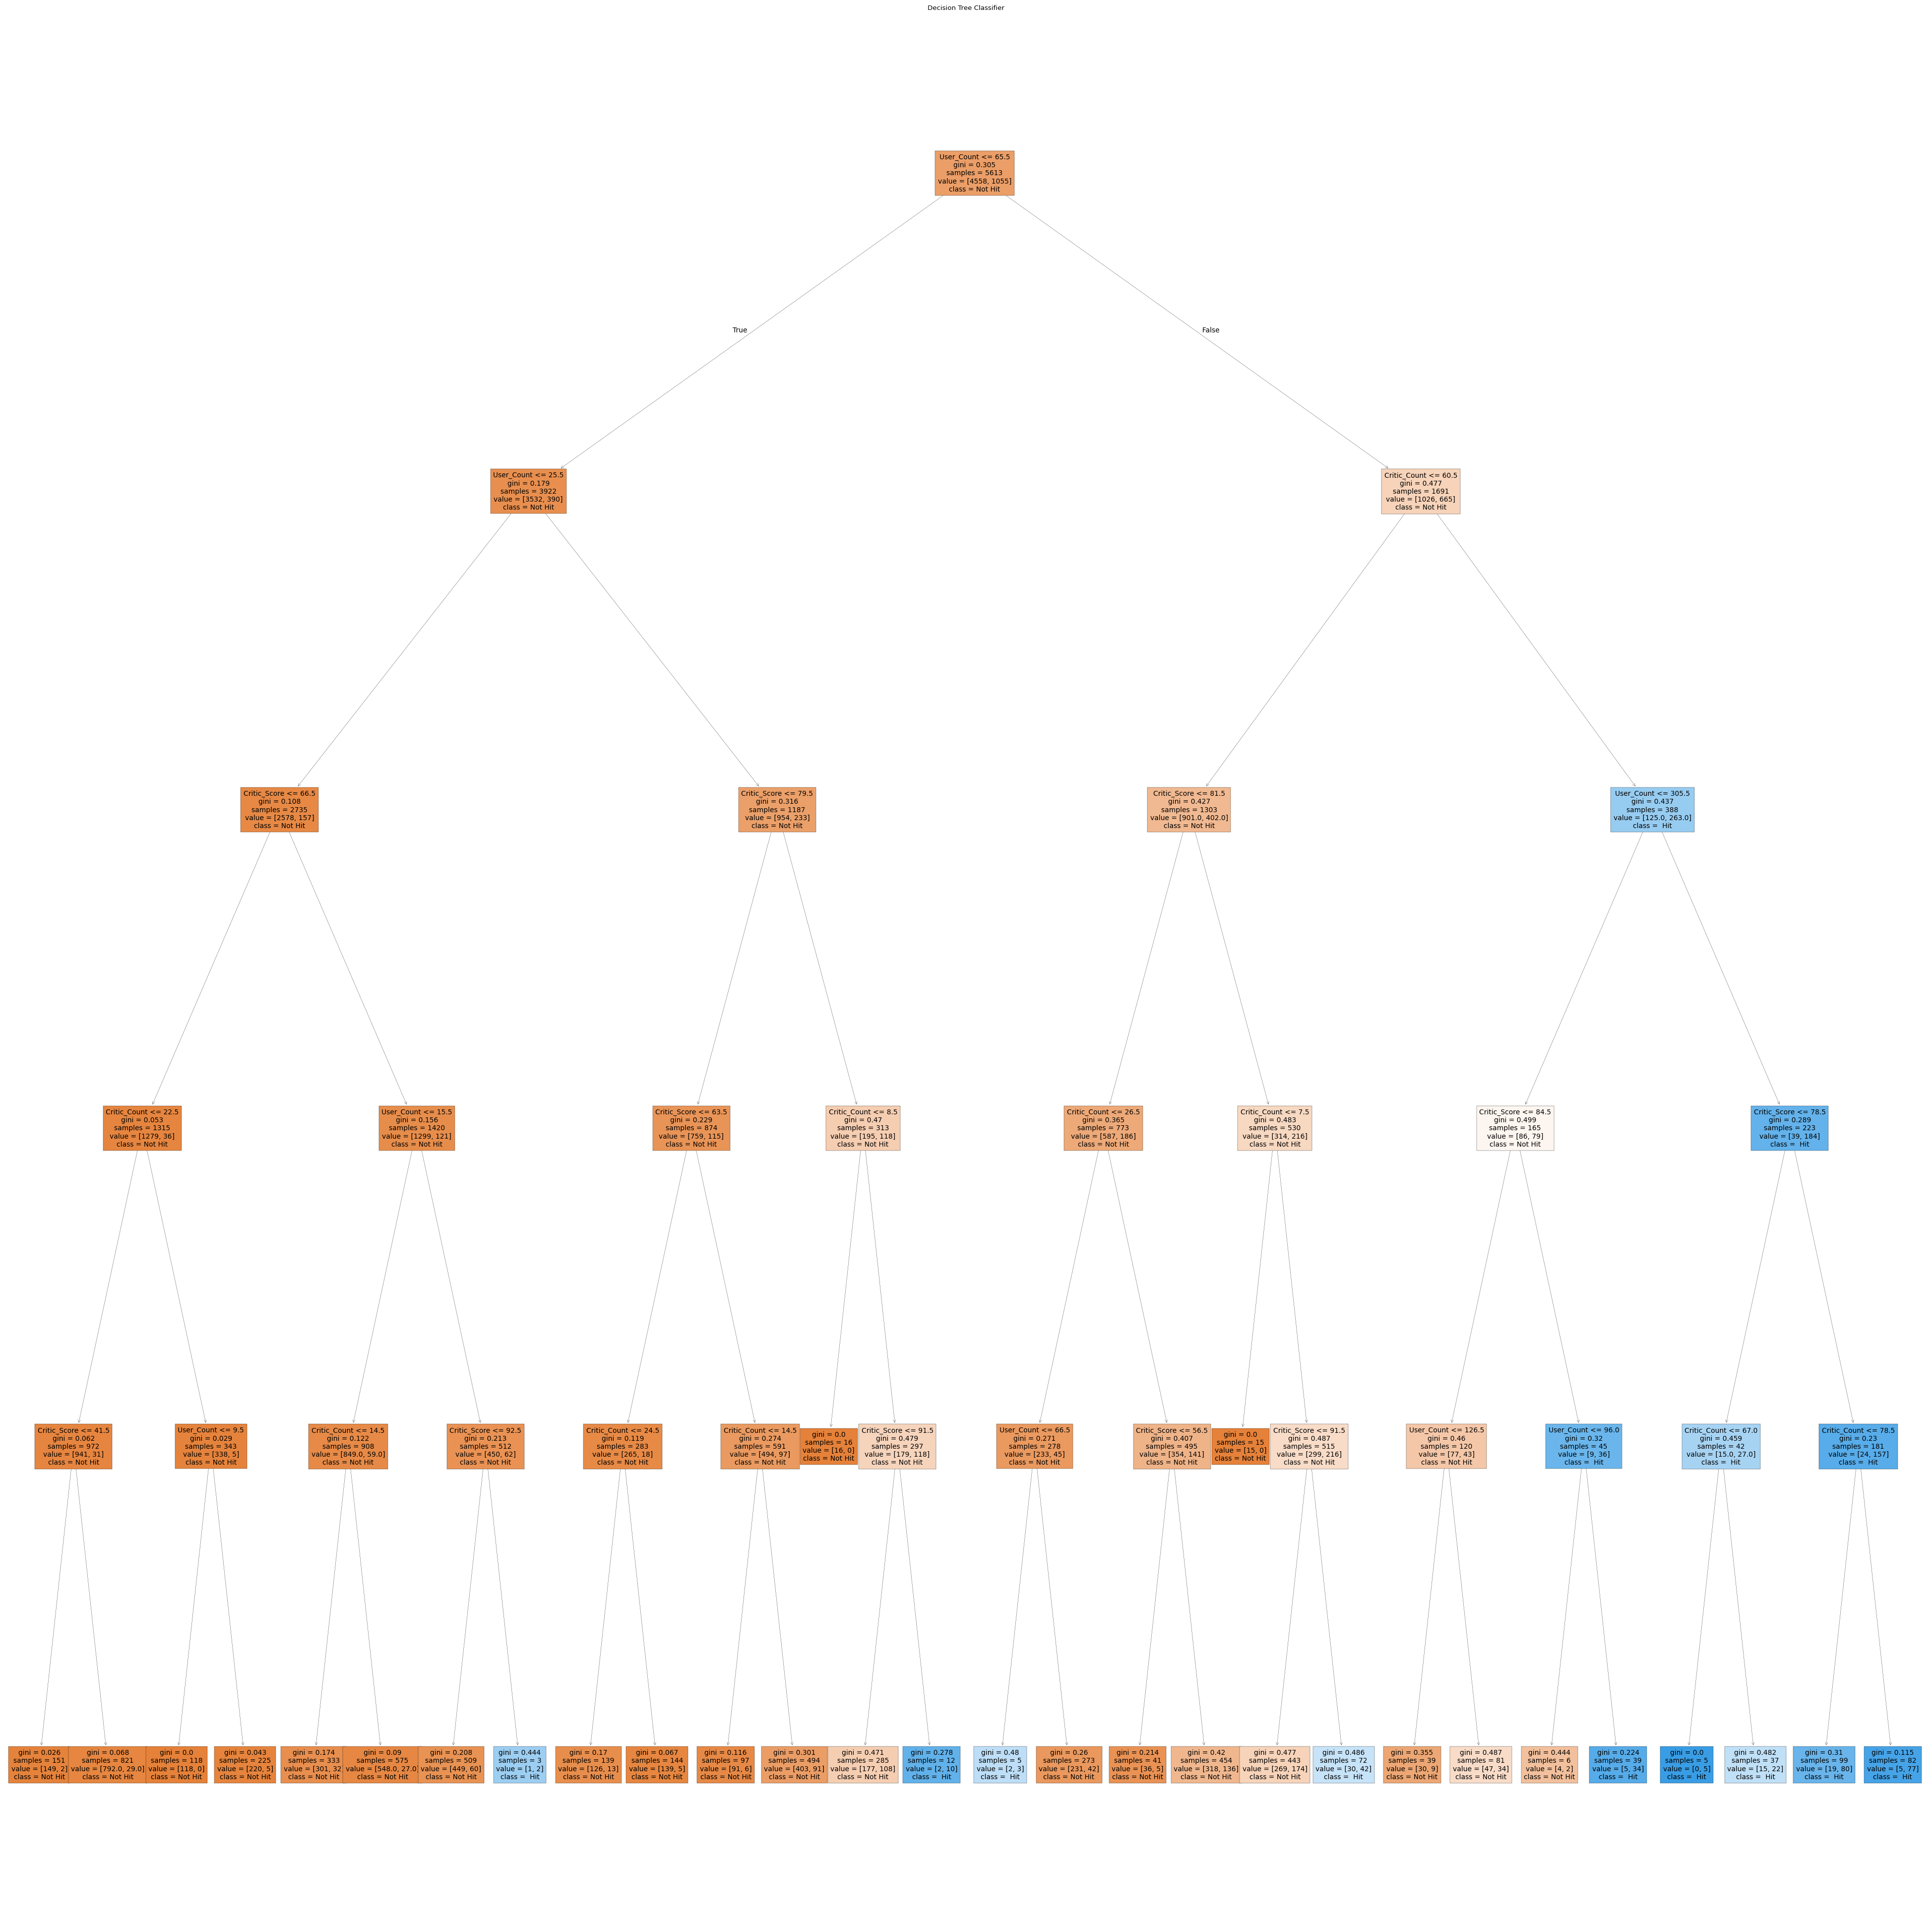

--- DECISION TREE MODEL EVALUATION ---


array([[1100,   28],
       [ 202,   74]])

'accuracy: 83.62%, precision: 72.55%, recall: 26.81%'

<IPython.core.display.Latex object>

In [54]:
# Since our goal is to compare models, we can use the same training and testing sets from the previous regression analysis.

X_train_dt = X_train_lr
X_test_dt = X_test_lr
Y_train_dt = Y_train_lr
Y_test_dt = Y_test_lr

# We will build a decision tree regression model and evaluate its performance.

model_dt = DecisionTreeClassifier(max_depth=5, random_state=42, criterion='gini') # We will be using Classification since 
# our target is categorical (0 = Not Hit, 1 = Hit)
model_dt.fit(X_train_dt, Y_train_dt) # Fit the model to the training data

# Now let's make predictions on the test set and evaluate the model's performance
Y_pred_dt = model_dt.predict(X_test_dt) # Make predictions on the test data
accuracy_dt = accuracy_score(Y_test_dt, Y_pred_dt)
precision_dt = precision_score(Y_test_dt, Y_pred_dt)
recall_dt = recall_score(Y_test_dt, Y_pred_dt)
conf_matrix_dt = confusion_matrix(Y_test_dt, Y_pred_dt)

# plot the Roc/ AOC curves for the decision tree model

RocCurveDisplay.from_estimator(model_dt, X_test_dt, Y_test_dt)
plt.title('ROC Curve for Decision Tree Model')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# plot decision tree

plt.figure(figsize=(50,50))
plot_tree(model_dt, feature_names=X_train_dt.columns, class_names=['Not Hit', ' Hit'], filled=True, fontsize=10)
plt.title('Decision Tree Classifier')
plt.show()

print("--- DECISION TREE MODEL EVALUATION ---")
display(conf_matrix_dt)
display("accuracy: {:.2f}%, precision: {:.2f}%, recall: {:.2f}%".format(accuracy_dt*100, precision_dt*100, recall_dt*100))
display(Latex(fr"The tree *slightly* improves ranking (ROC AUC = 0.82) and reduces false positives (precision ≈ 72.6%), but identifies " \
              fr"fewer true hits (recall ≈ 26.8%) compared to the logistic model. This means the tree makes fewer “false alarms” but " \
              fr"misses more real hits. If the goal is to capture as many hits as possible, we should consider lowering the decision threshold," \
              fr"or improoving the model with a validation set."))



### **1.3 Unsupervised Learning**

#### **1.3.1 K-Means Clustering**

K-Means Clustering is an unsupervised learning algorithm used for grouping data into clusters. Clusters are a collection of points that are similar to each other in some way, and dissimilar to points in other clusters. Different from classification and regression, in which we have labels (y) and teach the model to predict them, based on the features (X), in clustering we don't have labels. The **goal** of K-Means is to partition the data into *K* clusters, where each data point belongs to the cluster with the nearest mean (centroid). This allows us to find new patterns that were not previously known.

**K-Means Algorithm**

The K-Means algorithm starts by choosing a number of clusters *K*. Then, it randomly chooses *K* initial centroids from our data. Next, it calculates the distance between each data point and each centroid, assigning each data point to the nearest centroid. After all points are assigned, the centroids are recalculated as the mean of all points assigned to each cluster. Then, the algorithm repeats the assignment, updating the points to the nearest centroid, and recalculating the centroids, until the assignments no longer change or a maximum number of iterations is reached. The distance metric commonly used is the Euclidean distance. For N dimensional points p and q, the Euclidean distance is calculated as:

- $ \boxed{ d(p, q) = \sqrt{\sum_{i=1}^{N} (p_i - q_i)^2} } $

where:

- **$N$** is the number of dimensions (features).
- **$p_i$** and **$q_i$** are the values of the $i^{th}$ dimension for points p and q, respectively.

The distance from the data points to the centroids is used to assign points to clusters. The objective of K-Means is to minimize the total distance between data points and their respective cluster centroids. This is done by minimizing the **Within-Cluster Sum of Squares (WCSS)**, also called **inertia**, which is calculated as: 

- $ \boxed{ \text{Inertia} = \sum_{k=1}^{K} \sum_{x \in C_k} d(x, \mu_k)^2 } $

where:

- **$K$** is the number of clusters.
- **$C_k$** is the set of points in cluster $k$.
- **$\mu_k$** is the centroid of cluster $k$.

The K-Means algorithm iteratively updates the cluster assignments and centroids to minimize inertia, leading to more compact and well-defined clusters.

**Choosing the Number of Clusters (K)**

Since the previously described process depends on the random initialization of centroids, the final clusters may vary between different runs of the algorithm. To mitigate this, it is common to run the K-Means algorithm multiple times with different initializations and select the clustering result with the lowest inertia. However, one of the challenges of K-Means is choosing the appropriate number of clusters *K*. If $K = N$ (number of data points), each point will be its own cluster. This would, in theory , minimize inertia to zero, but it would not provide any meaningful insights. Conversely, if $K = 1$, all points would be assigned to a single cluster, which also lacks utility. Therefore, selecting an appropriate value for *K* is crucial for obtaining meaningful information. Several methods can help determine the optimal number of clusters, we will discuss two of them:

1. **Elbow Method**: This method involves running the K-Means algorithm for a range of *K* values (e.g., from 1 to 10) and calculating the inertia for each value of *K*. The inertia is then plotted against the number of clusters. The idea is to look for an "**elbow**" point in the plot, where the rate of decrease in inertia starts to slow down. This point indicates that adding more clusters does not significantly improve the clustering quality, and it can be chosen as the optimal number of clusters.

2. **Silhouette Score**: The silhouette score measures how similar a data point is to its own cluster compared to other clusters. It ranges from -1 to 1, where a score close to 1 indicates that the data point is well clustered, a score of 0 indicates that the data point is on or very close to the decision boundary between two neighboring clusters, and a negative score indicates that the data point may have been assigned to the wrong cluster. The silhouette score for a single data point is calculated as:

   - $ \boxed{ s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))} } $

   where:

   - **$a(i)$** is the average distance between the data point $i$ and all other points in the same cluster.
   - **$b(i)$** is the average distance between the data point $i$ and all points in the nearest cluster.

   The overall silhouette score for the clustering can be calculated as the average silhouette score of all data points. To determine the optimal number of clusters using silhouette scores, we can run the K-Means algorithm for different values of *K* and calculate the silhouette score for each clustering result. The value of *K* that yields the **highest** silhouette score (the peak of the silhouette curve) can be considered as the optimal number of clusters.

   We should note, however, that both methods can provide different suggestions for the optimal number of clusters. Therefore, it is often beneficial to use both methods in conjunction and consider the context of the data and the specific problem being addressed when making a final decision on the number of clusters.

- **Example:** Our analysis shows that raw sales data is too skewed for meaningful clustering. Let's pivot our analysis to answer a different question: Can we find natural groupings (archetypes) of games based on their critical and user reception? Use K-Means to cluster games based on Critic_Score, User_Score, Critic_Count, and User_Count. Evaluate the clusters using the Elbow Method and Silhouette Score to determine the optimal number of clusters. Analyze the characteristics of each cluster to identify distinct game archetypes. 

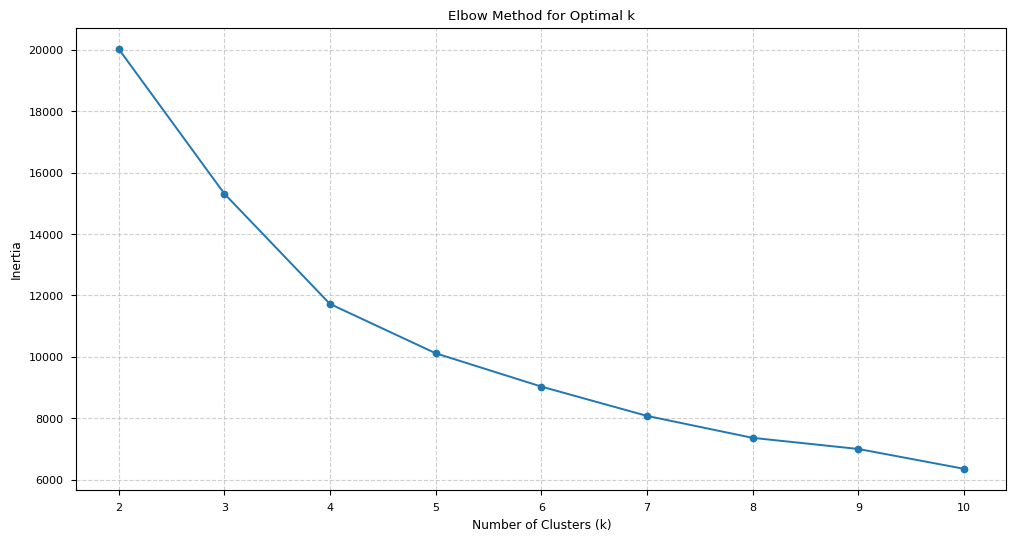

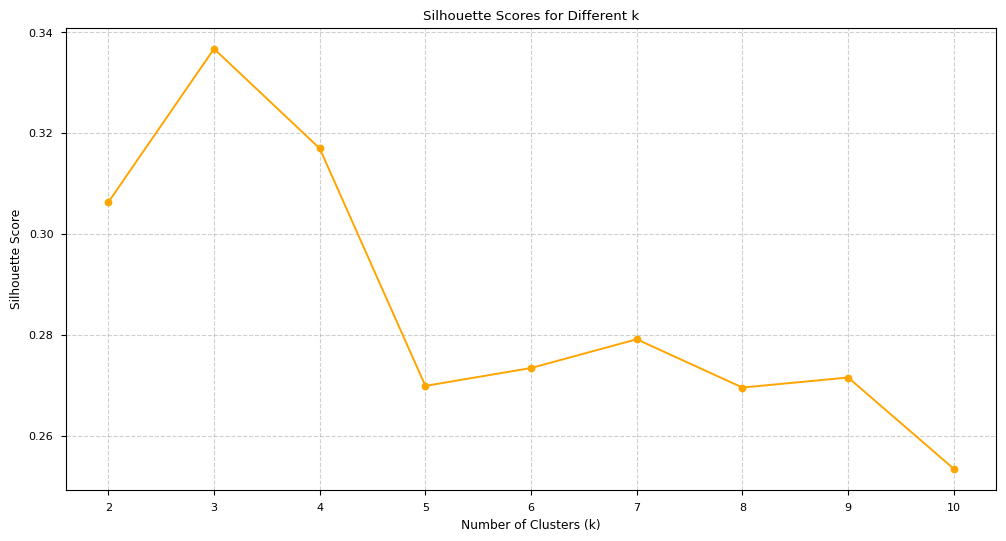

<IPython.core.display.Latex object>

In [67]:
df_kmeans = pd.read_csv('../data/Video_Games_Sales.csv')
df_kmeans = df_kmeans[['Critic_Score', 'User_Score', 'Critic_Count', 'User_Count']]
df_kmeans = pd.to_numeric(df_kmeans.stack(), errors='coerce').unstack() # Convert all columns to numeric, setting errors to NaN
df_kmeans = df_kmeans.dropna() # Drop rows with any NaN values

# Now we need to standardize the data before applying K-Means clustering. This is essencial in K-Means, since it is a 
# distance-based algorithm. If the features are on different scales, the algorithm may be biased towards the feature with 
# the larger scale. We will use StandardScaler from Scikit-Learn to standardize the data.

scaler = StandardScaler()
df_kmeans_scaled = scaler.fit_transform(df_kmeans)

# Now, let's apply the k-means algorithm
inertia_values = []
k_values = []
silhouette_scores = []


for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(df_kmeans_scaled)
    inertia_values.append(kmeans.inertia_)
    k_values.append(k)
    silhouette_scores.append(silhouette_score(df_kmeans_scaled, kmeans.labels_))

# Plot the elbow curve
plt.figure(figsize=(12, 6))
plt.plot(k_values, inertia_values, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot silhouette scores
plt.figure(figsize=(12, 6))
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

display(Latex("Based on the Elbow and Silhouette evaluations, we selected **k = 4** as the working number of clusters. The elbow curve" \
        "shows diminishing returns in inertia after k = 4, while the silhouette score is highest at k = 3–4, indicating compact and "\
        "well-separated clusters. Choosing k = 4 provides a pragmatic balance: it preserves meaningful subgroup structure that suits "\
        "our analysis goals."))



Cluster
0    1665
1    1658
2     108
3    3586
Name: count, dtype: int64

,Critic_Score,User_Score,Critic_Count,User_Count,Cluster
0,76.0,8.0,51.0,322.0,1
2,82.0,8.3,73.0,709.0,1
3,80.0,8.0,73.0,192.0,1
6,89.0,8.5,65.0,431.0,1
7,58.0,6.6,41.0,129.0,0
...,...,...,...,...,...
16677,81.0,8.8,12.0,9.0,3
16696,80.0,7.6,20.0,412.0,3
16700,61.0,5.8,12.0,43.0,0
16706,60.0,7.2,12.0,13.0,3


--- CLUSTER CENTROIDS ---


,Critic_Score,User_Score,Critic_Count,User_Count
Cluster,,,,
0,52.846246,5.358619,18.846847,50.550150
1,79.768999,7.715561,54.199035,302.890832
2,87.879630,7.188889,66.277778,3860.305556
3,73.398215,7.782543,20.516453,59.594255


<Figure size 1000x800 with 0 Axes>

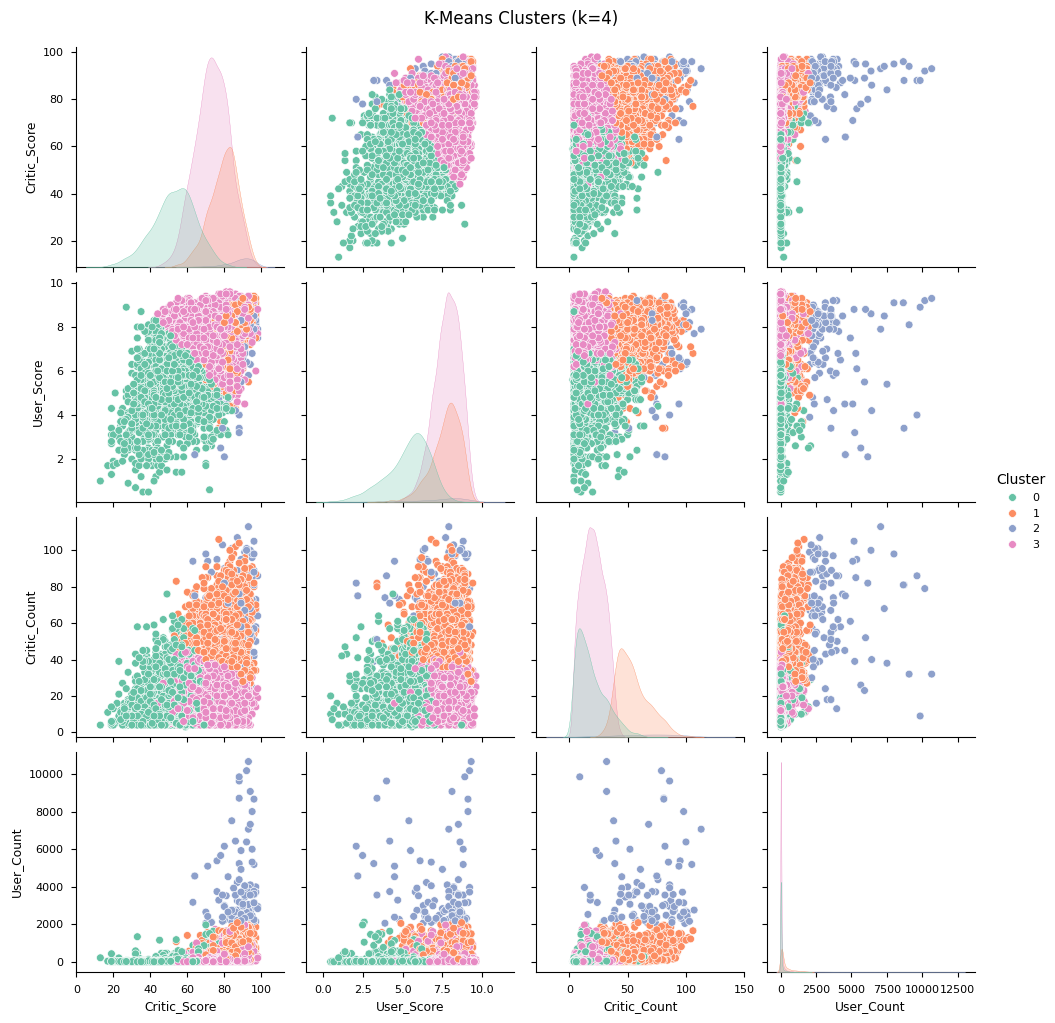

Cluster
0    1665
1    1658
2     108
3    3586
Name: count, dtype: int64

Critic_Score  User_Score  Critic_Count  User_Count
Cluster                                                         
0       0.25          46.0       4.600           9.0        7.00
        0.50          54.0       5.600          16.0       14.00
        0.75          61.0       6.300          26.0       33.00
1       0.25          75.0       7.200          44.0       55.00
        0.50          80.5       7.900          51.0      125.00
        0.75          85.0       8.400          62.0      374.75
2       0.25          84.0       6.375          49.5     2450.00
        0.50          89.0       7.900          68.5     3166.50
        0.75          94.0       8.500          86.0     4265.50
3       0.25          67.0       7.300          13.0       10.00
        0.50          74.0       7.800          20.0       20.00
        0.75          80.0       8.400          28.0       46.00

<IPython.core.display.Latex object>

In [68]:
# Add the new information to the dataframe
kmeans4 = KMeans(n_clusters=4, random_state=42).fit(df_kmeans_scaled)
cluster_info = kmeans4.labels_ 
df_kmeans_with_clusters = df_kmeans.copy()
df_kmeans_with_clusters['Cluster'] = cluster_info
display(df_kmeans_with_clusters['Cluster'].value_counts().sort_index())
display(df_kmeans_with_clusters)
# Display the mean values of each feature for each cluster
print("--- CLUSTER CENTROIDS ---")
display(df_kmeans_with_clusters.groupby('Cluster').mean())

# Visualize the clusters using a pairplot
plt.figure(figsize=(10, 8))
sns.pairplot(df_kmeans_with_clusters, hue='Cluster', diag_kind='auto', palette='Set2')
plt.suptitle('K-Means Clusters (k=4)', y=1.02)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

display(df_kmeans_with_clusters['Cluster'].value_counts().sort_index())

display(df_kmeans_with_clusters.groupby('Cluster').quantile([0.25, 0.5, 0.75]))

display(Latex("Applying K-Means (k = 4) to *Critic_Score*, *User_Score*, *Critic_Count* and *User_Count* reveals four interpretable " \
              "archetypes in the dataset. One group (Cluster 0, n ≈ 1,665) captures *low-impact* titles: median critic score ≈ 54, "  \
              "median user score ≈ 5.6, and low review counts (Critic_Count med ≈ 16, User_Count med ≈ 14), consistent with games that" \
              "received little attention and generally poor reception. Two intermediate clusters (Cluster 1, n ≈ 1,658; Cluster 3, " \
              "n ≈ 3,586) reflect different flavors of mid-tier performance: Cluster 1 is characterized by strong critical reception " \
              "and higher visibility (Critic_Score med ≈ 80.5; User_Score med ≈ 7.9; Critic_Count med ≈ 51; User_Count med ≈ 125) and " \
              "therefore reads as “critically valued and visible” titles, while Cluster 3 shows slightly lower critic medians but " \
              "similarly solid user appreciation with lower review counts (Critic_Score med ≈ 74; User_Score med ≈ 7.8; " \
              "Critic_Count med ≈ 20; User_Count med ≈ 20), which we interpret as *user-favored* games with more modest reach. Finally, " \
              "a small but distinct cluster (Cluster 2, n ≈ 108) groups the *high-impact / blockbuster* titles: very high medians across the " \
              "board (Critic_Score med ≈ 89; User_Score med ≈ 7.9; Critic_Count med ≈ 68.5; User_Count med ≈ 3,166.5) — these are the widely " \
              "reviewed and heavily discussed games that dominate conversation and inflate aggregate metrics"))

### **1.4 Specialized Applications**



##### **1.4.1 Introduction to Time Series Forecasting**